In [1]:
import brian2 as b2 # used for neural simulation
from brian2 import *

import numpy as np # used for array operations
from scipy.stats import poisson, binom, f, multivariate_normal, stats # used for stats (mean, s.d.)
from scipy import stats
from scipy.special import gammaln

import matplotlib.pyplot as plt # used for plotting
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import math
import random
import warnings
import json

b2.prefs.codegen.target = "numpy" # set Brian2 to use numpy backend

# from sklearn.feature_selection import f_classif
# from brian2 import NeuronGroup, Synapses, PoissonGroup, SpikeMonitor, run, ms, Hz, PoissonInput, clear_cache, device, get_unit, second

In [2]:
%run neural_simulation_functions.py
# %run neural_simulation_functions.ipynb

#fix it to be a .py file not a .ipynb file

In [3]:
#import the python file
# once everything is good run this

#from neural_simulation_functions import *

Parameters.

In [5]:
num_neurons = 10 # try 10 just to see covariance matrices
rate = 10 # change back to 10
rates = np.linspace(5, 15, num_neurons) # change back to np.linspace(5, 14, num_neurons)
time = 1000
num_samples = 1000 # change to 100 to show Alex next time, but plot the first five trajectories or random five 
t0 = 200
time_points = np.arange(0, 1000)

In [6]:
# Single rate absolute (perturbation magnitude with rate): std_dev = perturbation_magnitude * base_rates[neuron]
#perturbed_rate1 = generate_perturbed_rates(num_neurons, rate, perturbation_magnitude = 0.1, relative=True)
# each neuron has a rate of 10 hz
#print(perturbed_rate1)

# Single rate relative (perturbation magnitude without rate): std_dev = perturbation_magnitude
#perturbed_rate2 = generate_perturbed_rates(num_neurons, rate, perturbation_magnitude = 0.1, relative=False)
# each neuron has a rate of 10 hz
#print(perturbed_rate2)

In [7]:
perturbed_rates1 = generate_perturbed_rates(num_neurons, rates, perturbation_magnitude = 0.1, relative=True)
print(perturbed_rates1)

#perturbed_rates2 = generate_perturbed_rates(num_neurons, rates, perturbation_magnitude = 0.1, relative=False)
#print(perturbed_rates2)

[ 4.65716365  5.59764518  6.07221936  7.86081012  9.68622944  9.53683976
 10.98656643 12.2856102  14.46182993 14.66391562]


In [8]:
# Simulation control parameters

# Network parameters
N_E = 1000
#gamma = 0.25                    # ratio of inhibitory to excitatory neurons
#N_I = round(gamma * N_E)
#N = N_E + N_I
epsilon = 0.1                   # Sparsity of connections.  changed from 0.1, 0.2 was fine...
#C_E = epsilon * N_E             # number of excitatory connections per neuron
#C_ext = C_E                     # external connections per neuron


# Neuron parameters
#tau = 20  * ms                  # Membrane time constant. previously 20, tried 50 it was weird, larger numbers more spikes, smaller numbers less spikes
                                # Higher Tau means slower decay, more spikes.
                                # Lower Tau means faster decay, fewer spikes
#theta = 20  * mV                # spike threshold voltage, neuron fires when hitting this value
#V_r = 10  * mV                  # reset potential, voltage neuron goes back to after firing
#tau_rp = 2  * ms                # refractory period (neuron needs to wait some time before spiking again)

# Synapse parameters
#J = 0.1 * mV                    # Synaptic strength # Previously 0.1 * mV, previouysly 0.075, 0.2 was too varied need to be more consistent
                                # larger J, stronger synaptic input, higher firing rate
                                # smaller J, weaker input, lower firing rates
#D = 1.5  * ms                   # synaptic delay, time between a pre spike and its effect on postsynap neuron

# Simulation settings
#dt = 0.1  * ms
g = 4                           # g is a good control for manipulating the firing rate, smaller numbers more spikes, bigger numbers less spikes
                                # Higher g, stronger inhibition, suppresses network activity
                                # Lower g, weaker inhibition, increase network activity
nu_ext_over_nu_thr = 1          # Previously 2, 1.2 was weird, 1 (made 2d plot nice), 0.5 not good,
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

#nu_thr = theta / (J * C_E * tau) # minimal input rate needed to reach threshold
#nu_ext = nu_ext_over_nu_thr * nu_thr # external input rate

# adjust g and nu_ext so that nu_ext is approximately the number of spikes that are occuring, influenced by g. 
# epsilon 0.2 and g = 2.6, g = 2.8 is too much,tau = 50
# epsilon 0.5 and g = 4, tau = 20

In [9]:
N_E = 1000
gamma = 0.25                    # ratio of inhibitory to excitatory neurons
N_I = round(gamma * N_E)
N = N_E + N_I

In [10]:
N

1250

Generating spike trains, then counting the spikes.

In [12]:
raw_spike_train = independent_poisson_processes(num_neurons, time, num_samples, rate = rate)
# print(raw_spike_train)

In [13]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
# print(loaded_spike_trains)

Spike trains saved to spike_trains.json


In [14]:
spike_train = standardize_units(raw_spike_train)
# print(spike_train)

In [15]:
raw_multi_rate_spike_train = multivariate_constant_poisson(num_neurons, time, num_samples, rates = rates)

WARNING    'rates' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value array([ 5.        ,  6.11111111,  7.22222222,  8.33333333,  9.44444444,
       10.55555556, 11.66666667, 12.77777778, 13.88888889, 15.        ]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [16]:
save_spike_trains(raw_multi_rate_spike_train, "multi_rate_spike_trains.json")
loaded_spike_trains = load_spike_trains("multi_rate_spike_trains.json")

Spike trains saved to multi_rate_spike_trains.json


In [17]:
multi_rate_spike_train = standardize_units(raw_multi_rate_spike_train)

In [18]:
raw_perturbed_rate_spike_train = multivariate_constant_poisson(num_neurons, time, num_samples, rates = perturbed_rates1)

WARNING    'rates' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value array([ 4.65716365,  5.59764518,  6.07221936,  7.86081012,  9.68622944,
        9.53683976, 10.98656643, 12.2856102 , 14.46182993, 14.66391562]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [19]:
save_spike_trains(raw_perturbed_rate_spike_train, "perturbed_rate_spike_trains.json")
loaded_spike_trains = load_spike_trains("perturbed_rate_spike_trains.json")

Spike trains saved to perturbed_rate_spike_trains.json


In [20]:
perturbed_rate_spike_train = standardize_units(raw_perturbed_rate_spike_train)

In [21]:
# first_spike = find_nth_earliest_spike(spike_train, n=2)

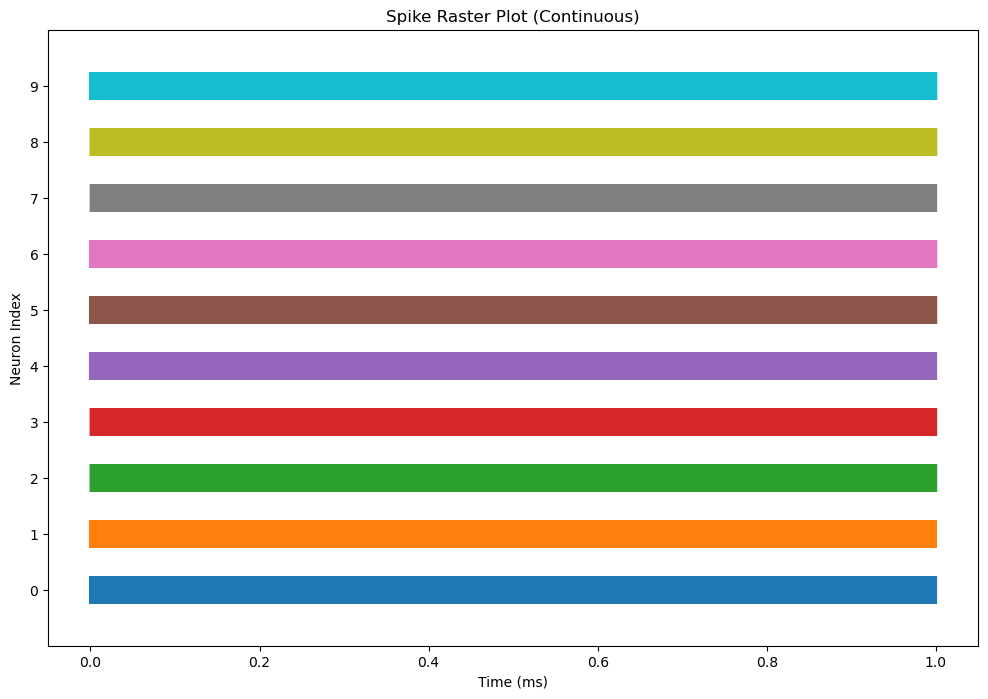

In [22]:
raster_plot(spike_train, colors=None, linelengths=None, figsize=(12,8))

In [23]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
multi_rate_binary_spikes = spikes_to_binary(multi_rate_spike_train, num_neurons, time)
perturbed_rate_binary_spikes = spikes_to_binary(perturbed_rate_spike_train, num_neurons, time)

In [24]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
# print(count)
# print(count.shape)
multi_rate_spike_count = count_spikes(multi_rate_binary_spikes)
multi_rate_count = np.array(multi_rate_spike_count)

perturbed_rate_spike_count = count_spikes(perturbed_rate_binary_spikes)
perturbed_rate_count = np.array(perturbed_rate_spike_count)

In [25]:
random_indices = np.random.choice(count.shape[0], size=5, replace=False)  # No duplicates
random_samples = count[random_indices]  # Shape: (5, neurons, time)

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [27]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(N_E, epsilon, g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
# print(raw_excitatory_spike_trains)

In [28]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [29]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

#print(excitatory_spike_trains[0])
#print(inhibitory_spike_trains[0])

In [30]:
#first_spike_ex = find_nth_earliest_spike(excitatory_spike_trains, n=2)
#first_spike_in = find_nth_earliest_spike(inhibitory_spike_trains, n=2)

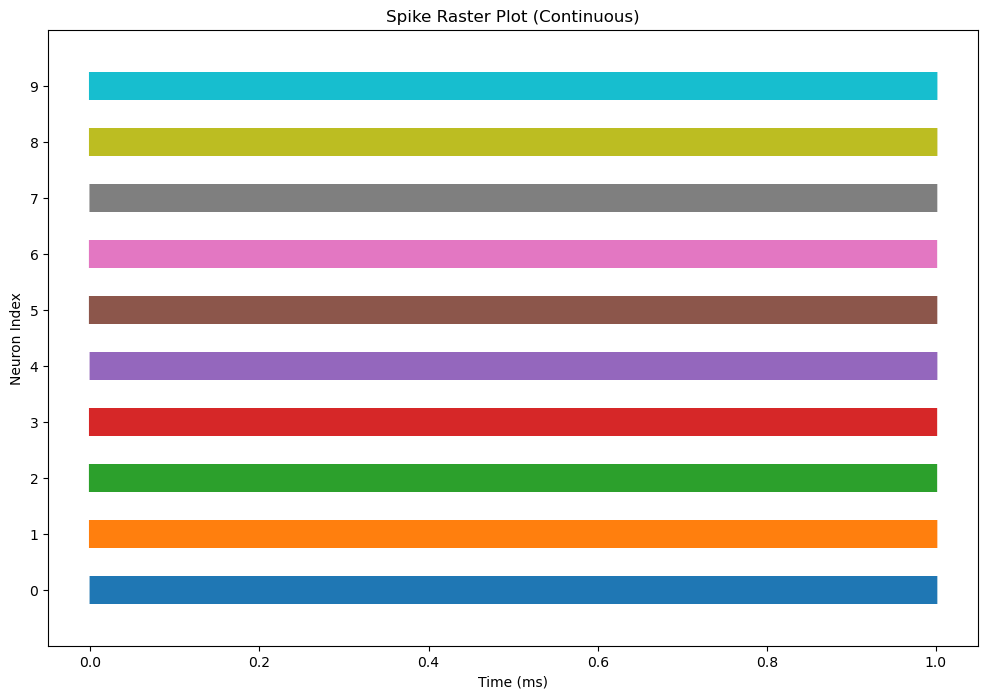

In [31]:
raster_plot(excitatory_spike_trains, colors=None, linelengths=None, figsize=(12,8))

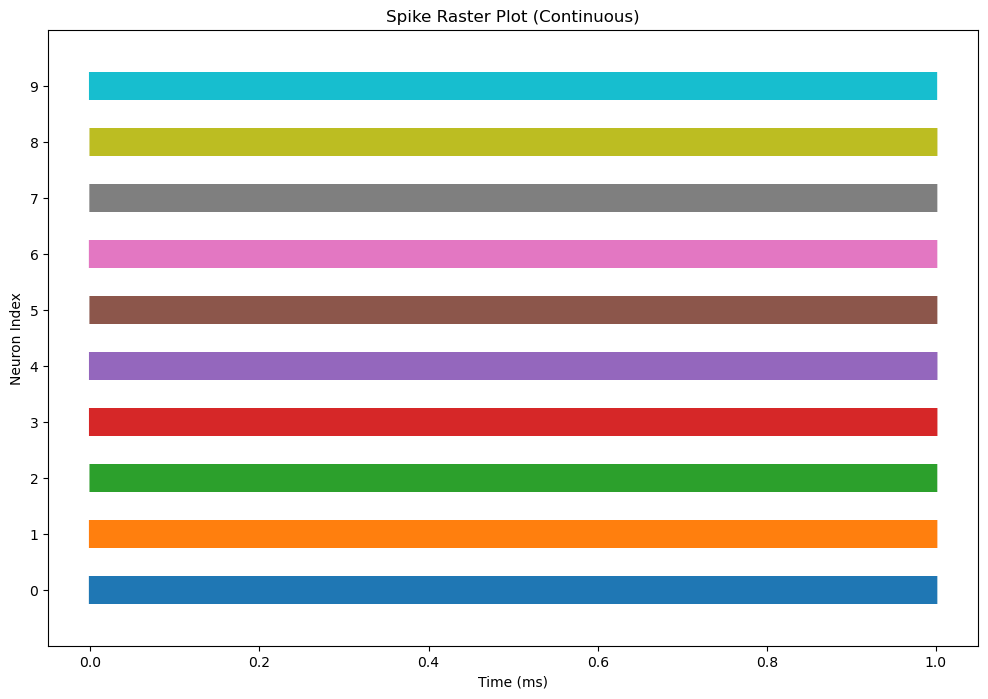

In [32]:
raster_plot(inhibitory_spike_trains, colors=None, linelengths=None, figsize=(12,8))

In [33]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)
# print(binary_ex_spikes[0][0]) # first sample of first neuron

In [34]:
spike_count_ex = count_spikes(binary_ex_spikes)
count_ex = np.array(spike_count_ex)
#print(spike_count_ex[0])
#print(count_ex[0])
#print(count_ex[1])
#print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
#print(count_in.shape)

In [35]:
random_indices_ex = np.random.choice(count_ex.shape[0], size=5, replace=False)  # No duplicates
random_samples_ex = count_ex[random_indices_ex]  # Shape: (5, neurons, time)

random_indices_in = np.random.choice(count_in.shape[0], size=5, replace=False)  # No duplicates
random_samples_in = count_in[random_indices_in]  # Shape: (5, neurons, time)

Theoretical and Empirical stats of raw counts.

In [37]:
# empirical_mean = empirical_means(count) # np.mean(count, axis=0), count.mean(axis=0)
empirical_mean = count.mean(axis=0)
#print(empirical_mean.shape)
count_rate = empirical_mean[:, -1]
#print(count_rate.shape)
#print(empirical_mean)
#print(empirical_mean.shape)
#print(count_rate)

# empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
empirical_std_dev = np.sqrt(empirical_mean) #count.std(axis=0, ddof=1)
# empirical_std_dev = (count.std(axis=0)) #newly added, should be the same but isn't
# i fixed the above by using empirical_std_dev = (count.std(axis=0, ddof=1))
#print(empirical_std_dev)
#print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

In [38]:
multi_rate_empirical_mean = multi_rate_count.mean(axis=0)
multi_rate_count_rate = multi_rate_empirical_mean[:, -1]
multi_rate_empirical_std_dev = np.sqrt(multi_rate_empirical_mean) #count.std(axis=0, ddof=1)

multi_rate_empirical_lower_bound, multi_rate_empirical_upper_bound = confidence_intervals(multi_rate_empirical_mean, multi_rate_empirical_std_dev, num_samples, confidence_level=0.95)

In [39]:
perturbed_rate_empirical_mean = perturbed_rate_count.mean(axis=0)
perturbed_rate_count_rate = perturbed_rate_empirical_mean[:, -1]
perturbed_rate_empirical_std_dev = np.sqrt(perturbed_rate_empirical_mean) #count.std(axis=0, ddof=1)

perturbed_rate_empirical_lower_bound, perturbed_rate_empirical_upper_bound = confidence_intervals(perturbed_rate_empirical_mean, perturbed_rate_empirical_std_dev, num_samples, confidence_level=0.95)

In [40]:
exclude_times, global_exclude = last_zero_std_time(empirical_std_dev, verbose=True)

Neuron 0: last zero std at t=-1, recommended exclude=0
Neuron 1: last zero std at t=-1, recommended exclude=0
Neuron 2: last zero std at t=-1, recommended exclude=0
Neuron 3: last zero std at t=-1, recommended exclude=0
Neuron 4: last zero std at t=-1, recommended exclude=0
Neuron 5: last zero std at t=-1, recommended exclude=0
Neuron 6: last zero std at t=-1, recommended exclude=0
Neuron 7: last zero std at t=-1, recommended exclude=0
Neuron 8: last zero std at t=-1, recommended exclude=0
Neuron 9: last zero std at t=-1, recommended exclude=0

Global exclude (safest): t=0


In [41]:
multi_rate_exclude_times, multi_rate_global_exclude = last_zero_std_time(multi_rate_empirical_std_dev, verbose=True)

Neuron 0: last zero std at t=-1, recommended exclude=0
Neuron 1: last zero std at t=-1, recommended exclude=0
Neuron 2: last zero std at t=-1, recommended exclude=0
Neuron 3: last zero std at t=-1, recommended exclude=0
Neuron 4: last zero std at t=-1, recommended exclude=0
Neuron 5: last zero std at t=-1, recommended exclude=0
Neuron 6: last zero std at t=-1, recommended exclude=0
Neuron 7: last zero std at t=-1, recommended exclude=0
Neuron 8: last zero std at t=-1, recommended exclude=0
Neuron 9: last zero std at t=-1, recommended exclude=0

Global exclude (safest): t=0


In [42]:
perturbed_rate_exclude_times, perturbed_rate_global_exclude = last_zero_std_time(perturbed_rate_empirical_std_dev, verbose=True)

Neuron 0: last zero std at t=-1, recommended exclude=0
Neuron 1: last zero std at t=-1, recommended exclude=0
Neuron 2: last zero std at t=-1, recommended exclude=0
Neuron 3: last zero std at t=-1, recommended exclude=0
Neuron 4: last zero std at t=-1, recommended exclude=0
Neuron 5: last zero std at t=-1, recommended exclude=0
Neuron 6: last zero std at t=-1, recommended exclude=0
Neuron 7: last zero std at t=-1, recommended exclude=0
Neuron 8: last zero std at t=-1, recommended exclude=0
Neuron 9: last zero std at t=-1, recommended exclude=0

Global exclude (safest): t=0


In [43]:
theoretical_means = calculate_theoretical_mean(count_rate, time)
#print(theoretical_means)
#print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
#print(theoretical_std_dev)
#print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

In [44]:
multi_rate_theoretical_means = calculate_theoretical_mean(multi_rate_count_rate, time)
multi_rate_theoretical_std_dev = calculate_theoretical_std_dev(multi_rate_theoretical_means)

multi_rate_theoretical_lower_bound, multi_rate_theoretical_upper_bound = confidence_intervals(multi_rate_theoretical_means, multi_rate_theoretical_std_dev, num_samples, confidence_level=0.95)

In [45]:
perturbed_rate_theoretical_means = calculate_theoretical_mean(perturbed_rate_count_rate, time)
perturbed_rate_theoretical_std_dev = calculate_theoretical_std_dev(perturbed_rate_theoretical_means)

perturbed_rate_theoretical_lower_bound, perturbed_rate_theoretical_upper_bound = confidence_intervals(perturbed_rate_theoretical_means, perturbed_rate_theoretical_std_dev, num_samples, confidence_level=0.95)

In [46]:
res_var = variance_of_residuals(empirical_mean, theoretical_means)
#print(res_var)

In [47]:
centers = center_counts_loop(count, theoretical_means, num_samples, num_neurons)

centers_mean = np.mean(centers, axis = 0)
centers_std_dev = np.std(centers, axis = 0, ddof = 1)

centers_emp = center_counts_loop(count, empirical_mean, num_samples, num_neurons)

centers_mean_emp = np.mean(centers_emp, axis = 0)
centers_std_dev_emp = np.std(centers_emp, axis = 0, ddof = 1)

In [48]:
multi_rate_centers = center_counts_loop(multi_rate_count, theoretical_means, num_samples, num_neurons)
# multi_rate_centers = center_counts_loop(multi_rate_count, multi_rate_theoretical_means, num_samples, num_neurons)

multi_rate_centers_mean = np.mean(multi_rate_centers, axis = 0)
multi_rate_centers_std_dev = np.std(multi_rate_centers, axis = 0, ddof = 1)

multi_rate_centers_emp = center_counts_loop(multi_rate_count, empirical_mean, num_samples, num_neurons)
# multi_rate_centers_emp = center_counts_loop(multi_rate_count, multi_rate_empirical_mean, num_samples, num_neurons)

multi_rate_centers_mean_emp = np.mean(multi_rate_centers_emp, axis = 0)
multi_rate_centers_std_dev_emp = np.std(multi_rate_centers_emp, axis = 0, ddof = 1)

In [49]:
perturbed_rate_centers = center_counts_loop(perturbed_rate_count, theoretical_means, num_samples, num_neurons)
# perturbed_rate_centers = center_counts_loop(perturbed_rate_count, perturbed_rate_theoretical_means, num_samples, num_neurons)

perturbed_rate_centers_mean = np.mean(perturbed_rate_centers, axis = 0)
perturbed_rate_centers_std_dev = np.std(perturbed_rate_centers, axis = 0, ddof = 1)

perturbed_rate_centers_emp = center_counts_loop(perturbed_rate_count, empirical_mean, num_samples, num_neurons)
#perturbed_rate_centers_emp = center_counts_loop(perturbed_rate_count, perturbed_rate_empirical_mean, num_samples, num_neurons)

perturbed_rate_centers_mean_emp = np.mean(perturbed_rate_centers_emp, axis = 0)
perturbed_rate_centers_std_dev_emp = np.std(perturbed_rate_centers_emp, axis = 0, ddof = 1)

Poisson Standardization 

In [51]:
stands = standardize_counts_loop(count, theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
#print(stands)
#print(stands.shape)
# we removed the very first time point for this dataset

stands_emp = standardize_counts_loop(count, empirical_mean, empirical_std_dev, num_samples, num_neurons, global_exclude)
#print(stands_emp)
# cleaned_stands_emp = stands_emp[:, ~np.isnan(stands_emp).all(axis=0)]

#print(stands_emp.shape)
# we need to remove a few of the first time points for this dataset

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, time , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

standardized_mean_global = np.mean(stands)
standardized_std_global = np.std(stands)

standardized_mean_emp_global = np.mean(stands_emp)
standardized_std_emp_global = np.std(stands_emp)

standardized_mean = np.mean(stands, axis=0)
standardized_std = np.std(stands, axis=0, ddof = 1)

standardized_mean_emp = np.mean(stands_emp, axis = 0)
standardized_std_emp = np.std(stands_emp, axis = 0, ddof = 1)

In [52]:
stands.shape # trials, num neurons, 

(1000, 10, 999)

In [53]:
stands_emp.shape

(1000, 10, 1000)

In [54]:
has_negatives = np.any(stands < 0)
print(f"Array has negative numbers: {has_negatives}")
# this is why log-likelihood doesn't like me

Array has negative numbers: True


In [55]:
multi_rate_stands = standardize_counts_loop(multi_rate_count, theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
# multi_rate_stands = standardize_counts_loop(multi_rate_count, multi_rate_theoretical_means, multi_rate_theoretical_std_dev, num_samples, num_neurons, exclude = 1)
# standardize relative to theoretical means is above

## from Alex: for multirate, standardize relative to theoretical means and empirical means ##

multi_rate_stands_emp = standardize_counts_loop(multi_rate_count, empirical_mean, empirical_std_dev, num_samples, num_neurons, multi_rate_global_exclude)
# multi_rate_stands_emp = standardize_counts_loop(multi_rate_count, multi_rate_empirical_mean, multi_rate_empirical_std_dev, num_samples, num_neurons, multi_rate_global_exclude)
# standardize relative to empirical means is above

multi_rate_standardized_mean_global = np.mean(multi_rate_stands)
multi_rate_standardized_std_global = np.std(multi_rate_stands)

multi_rate_standardized_mean_emp_global = np.mean(multi_rate_stands_emp)
multi_rate_standardized_std_emp_global = np.std(multi_rate_stands_emp)

multi_rate_standardized_mean = np.mean(multi_rate_stands, axis=0)
multi_rate_standardized_std = np.std(multi_rate_stands, axis=0, ddof = 1)

multi_rate_standardized_mean_emp = np.mean(multi_rate_stands_emp, axis = 0)
multi_rate_standardized_std_emp = np.std(multi_rate_stands_emp, axis = 0, ddof = 1)

In [56]:
perturbed_rate_stands = standardize_counts_loop(perturbed_rate_count, theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
# perturbed_rate_stands = standardize_counts_loop(perturbed_rate_count, perturbed_rate_theoretical_means, perturbed_rate_theoretical_std_dev, num_samples, num_neurons, exclude = 1)
# standardize relative to theoretical means is above

## from Alex: for perturbation, standardize relative to theoretical means and empirical means ##
# these only gets used later in the cov matrix, it doesn't appear in plot_stats

perturbed_rate_stands_emp = standardize_counts_loop(perturbed_rate_count, empirical_mean, empirical_std_dev, num_samples, num_neurons, perturbed_rate_global_exclude)
# perturbed_rate_stands_emp = standardize_counts_loop(perturbed_rate_count, perturbed_rate_empirical_mean, perturbed_rate_empirical_std_dev, num_samples, num_neurons, perturbed_rate_global_exclude)
# standardize relative to empirical means is above
# this only gets used later in the cov matrix, it doesn't appear in plot_stats

perturbed_rate_standardized_mean_global = np.mean(perturbed_rate_stands)
perturbed_rate_standardized_std_global = np.std(perturbed_rate_stands)

perturbed_rate_standardized_mean_emp_global = np.mean(perturbed_rate_stands_emp)
perturbed_rate_standardized_std_emp_global = np.std(perturbed_rate_stands_emp)

perturbed_rate_standardized_mean = np.mean(perturbed_rate_stands, axis=0)
perturbed_rate_standardized_std = np.std(perturbed_rate_stands, axis=0, ddof = 1)

perturbed_rate_standardized_mean_emp = np.mean(perturbed_rate_stands_emp, axis = 0)
perturbed_rate_standardized_std_emp = np.std(perturbed_rate_stands_emp, axis = 0, ddof = 1)

In [57]:
## Then try the 3rd option: center with their own mean, scale by the null std.  ##
# Only empirical here
multi_rate_stands_emp_test = standardize_counts_loop(multi_rate_count, multi_rate_empirical_mean, empirical_std_dev, num_samples, num_neurons, multi_rate_global_exclude)

multi_rate_standardized_mean_emp_test = np.mean(multi_rate_stands_emp_test, axis = 0)
multi_rate_standardized_std_emp_test = np.std(multi_rate_stands_emp_test, axis = 0, ddof = 1)


perturbed_rate_stands_emp_test = standardize_counts_loop(perturbed_rate_count, perturbed_rate_empirical_mean, empirical_std_dev, num_samples, num_neurons, perturbed_rate_global_exclude)

perturbed_rate_standardized_mean_emp_test = np.mean(perturbed_rate_stands_emp_test, axis = 0)
perturbed_rate_standardized_std_emp_test = np.std(perturbed_rate_stands_emp_test, axis = 0, ddof = 1)

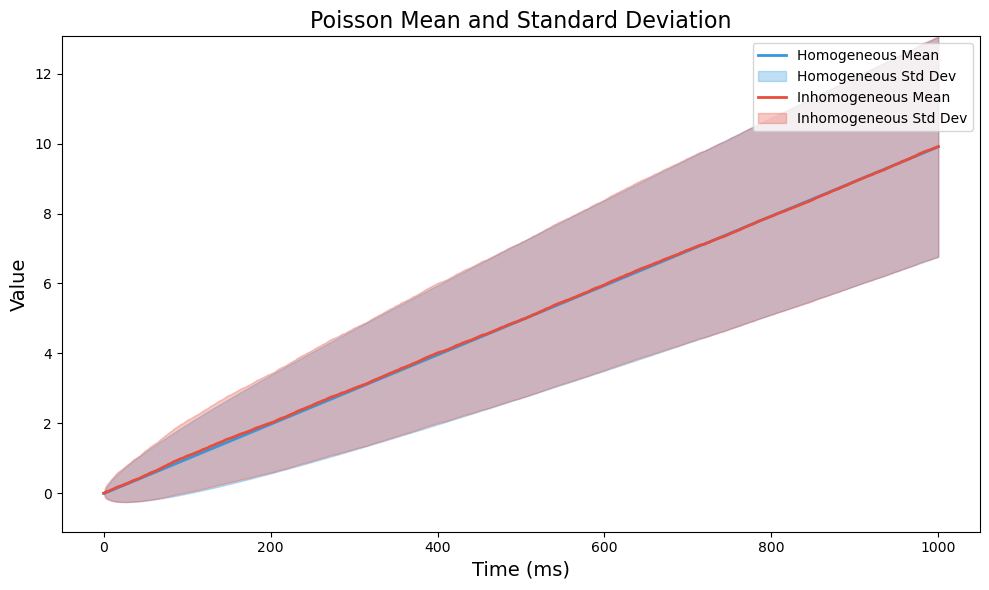

In [58]:
plot_stats(theoretical_means, empirical_mean, theoretical_std_dev, empirical_std_dev, title = 'Poisson Mean and Standard Deviation', show_hline=False, data_type='standardized')

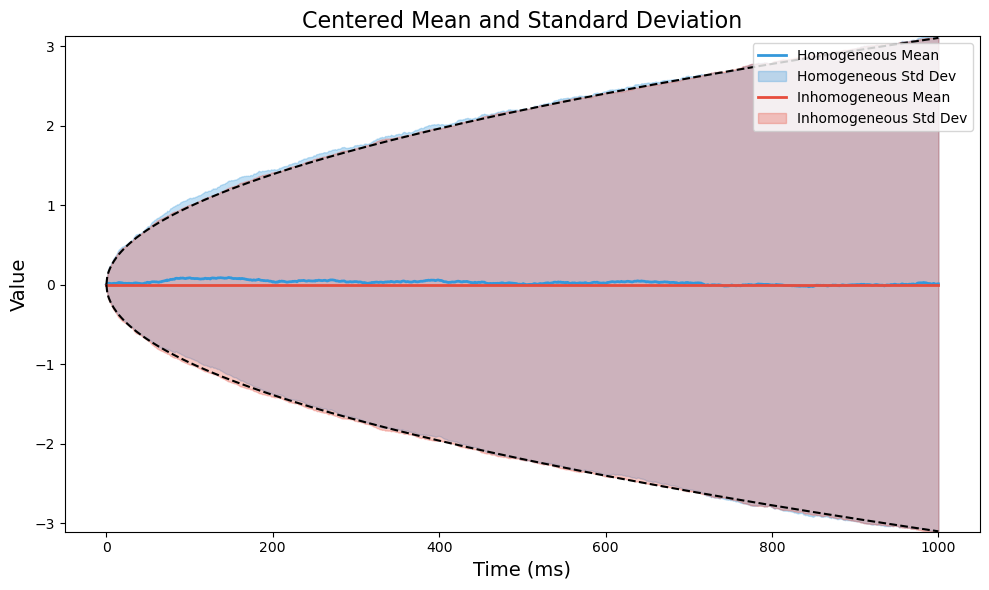

In [59]:
plot_stats(centers_mean, centers_mean_emp, centers_std_dev, centers_std_dev_emp, title = 'Centered Mean and Standard Deviation', show_hline=True, data_type='centered')

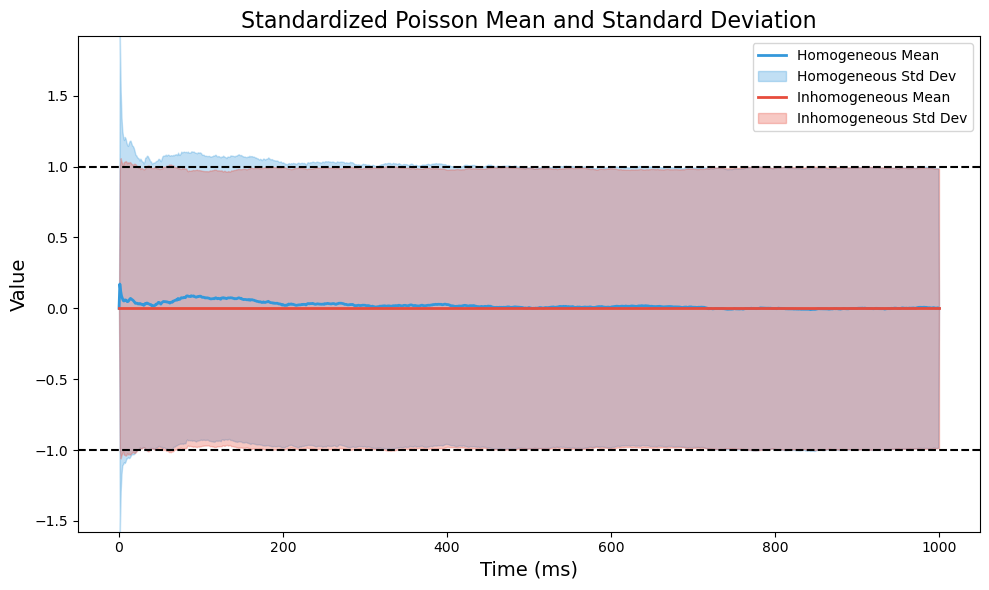

In [60]:
plot_stats(standardized_mean, standardized_mean_emp, standardized_std, standardized_std_emp, title = 'Standardized Poisson Mean and Standard Deviation', show_hline=True, data_type='standardized')

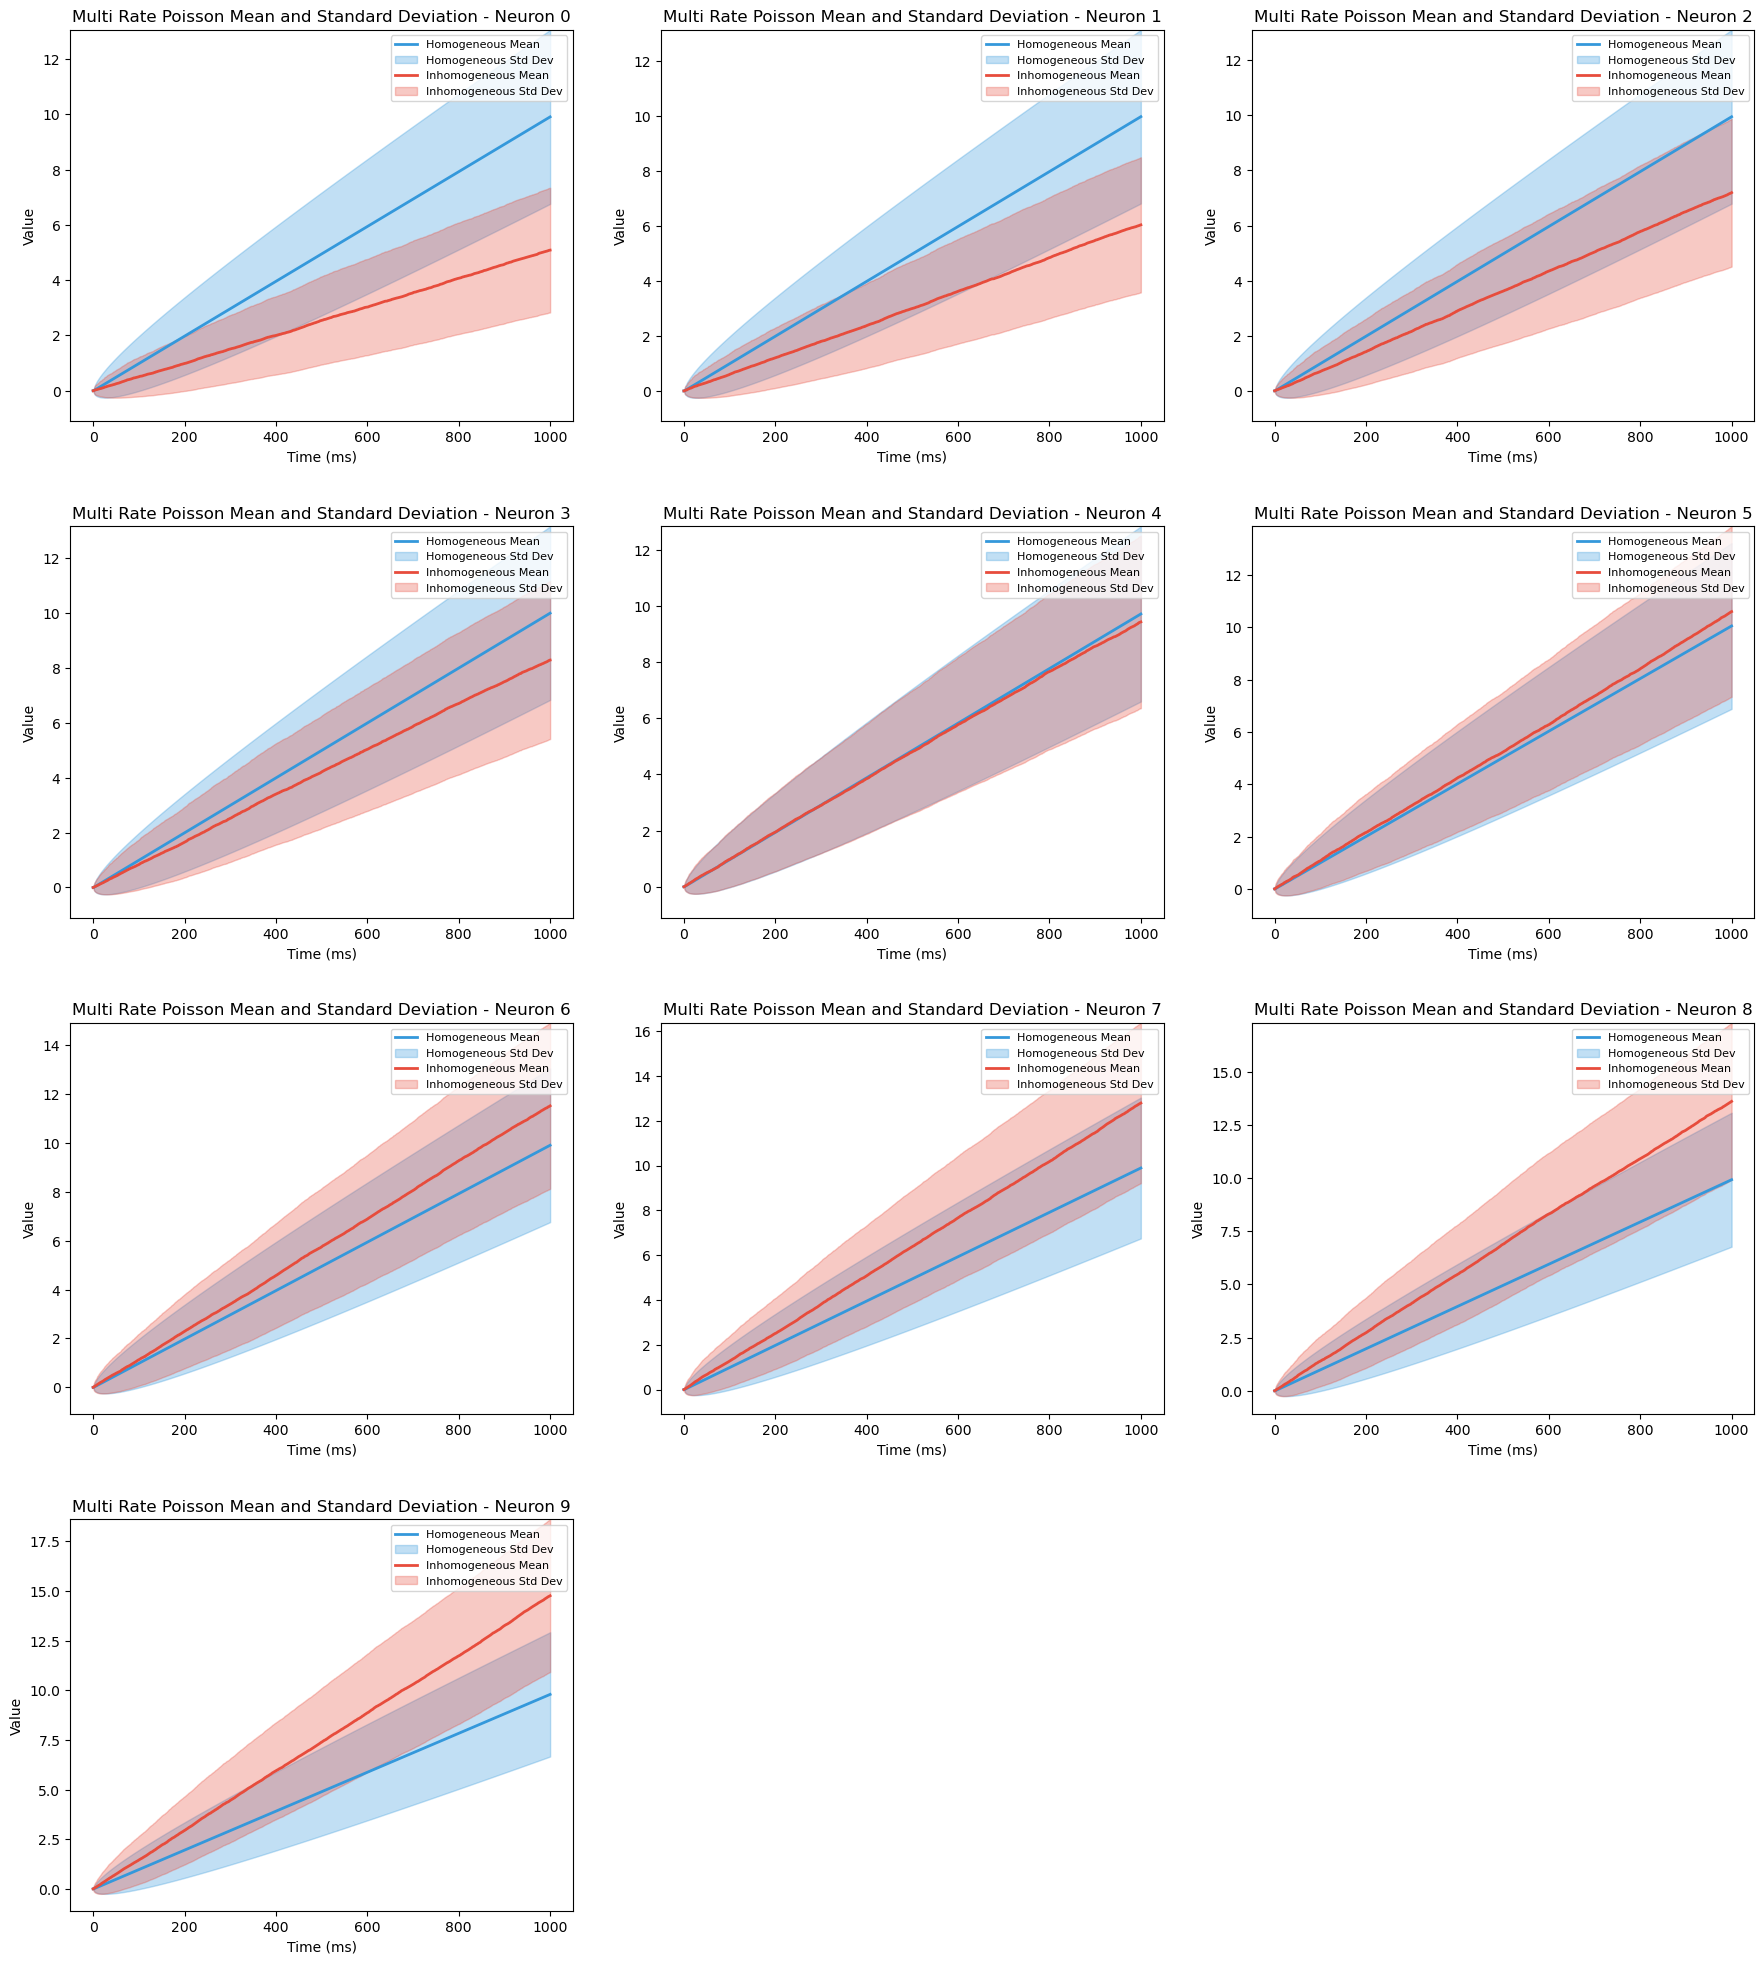

In [61]:
plot_multiple_stats(theoretical_means, multi_rate_empirical_mean, theoretical_std_dev, multi_rate_empirical_std_dev, title = 'Multi Rate Poisson Mean and Standard Deviation', show_hline=False, data_type='standardized')
# plot_multiple_stats(multi_rate_theoretical_means, multi_rate_empirical_mean, multi_rate_theoretical_std_dev, multi_rate_empirical_std_dev, title = 'Multi Rate Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots. For more precise plots we can go with isoclines.
# Aka lines with fixed probabilities

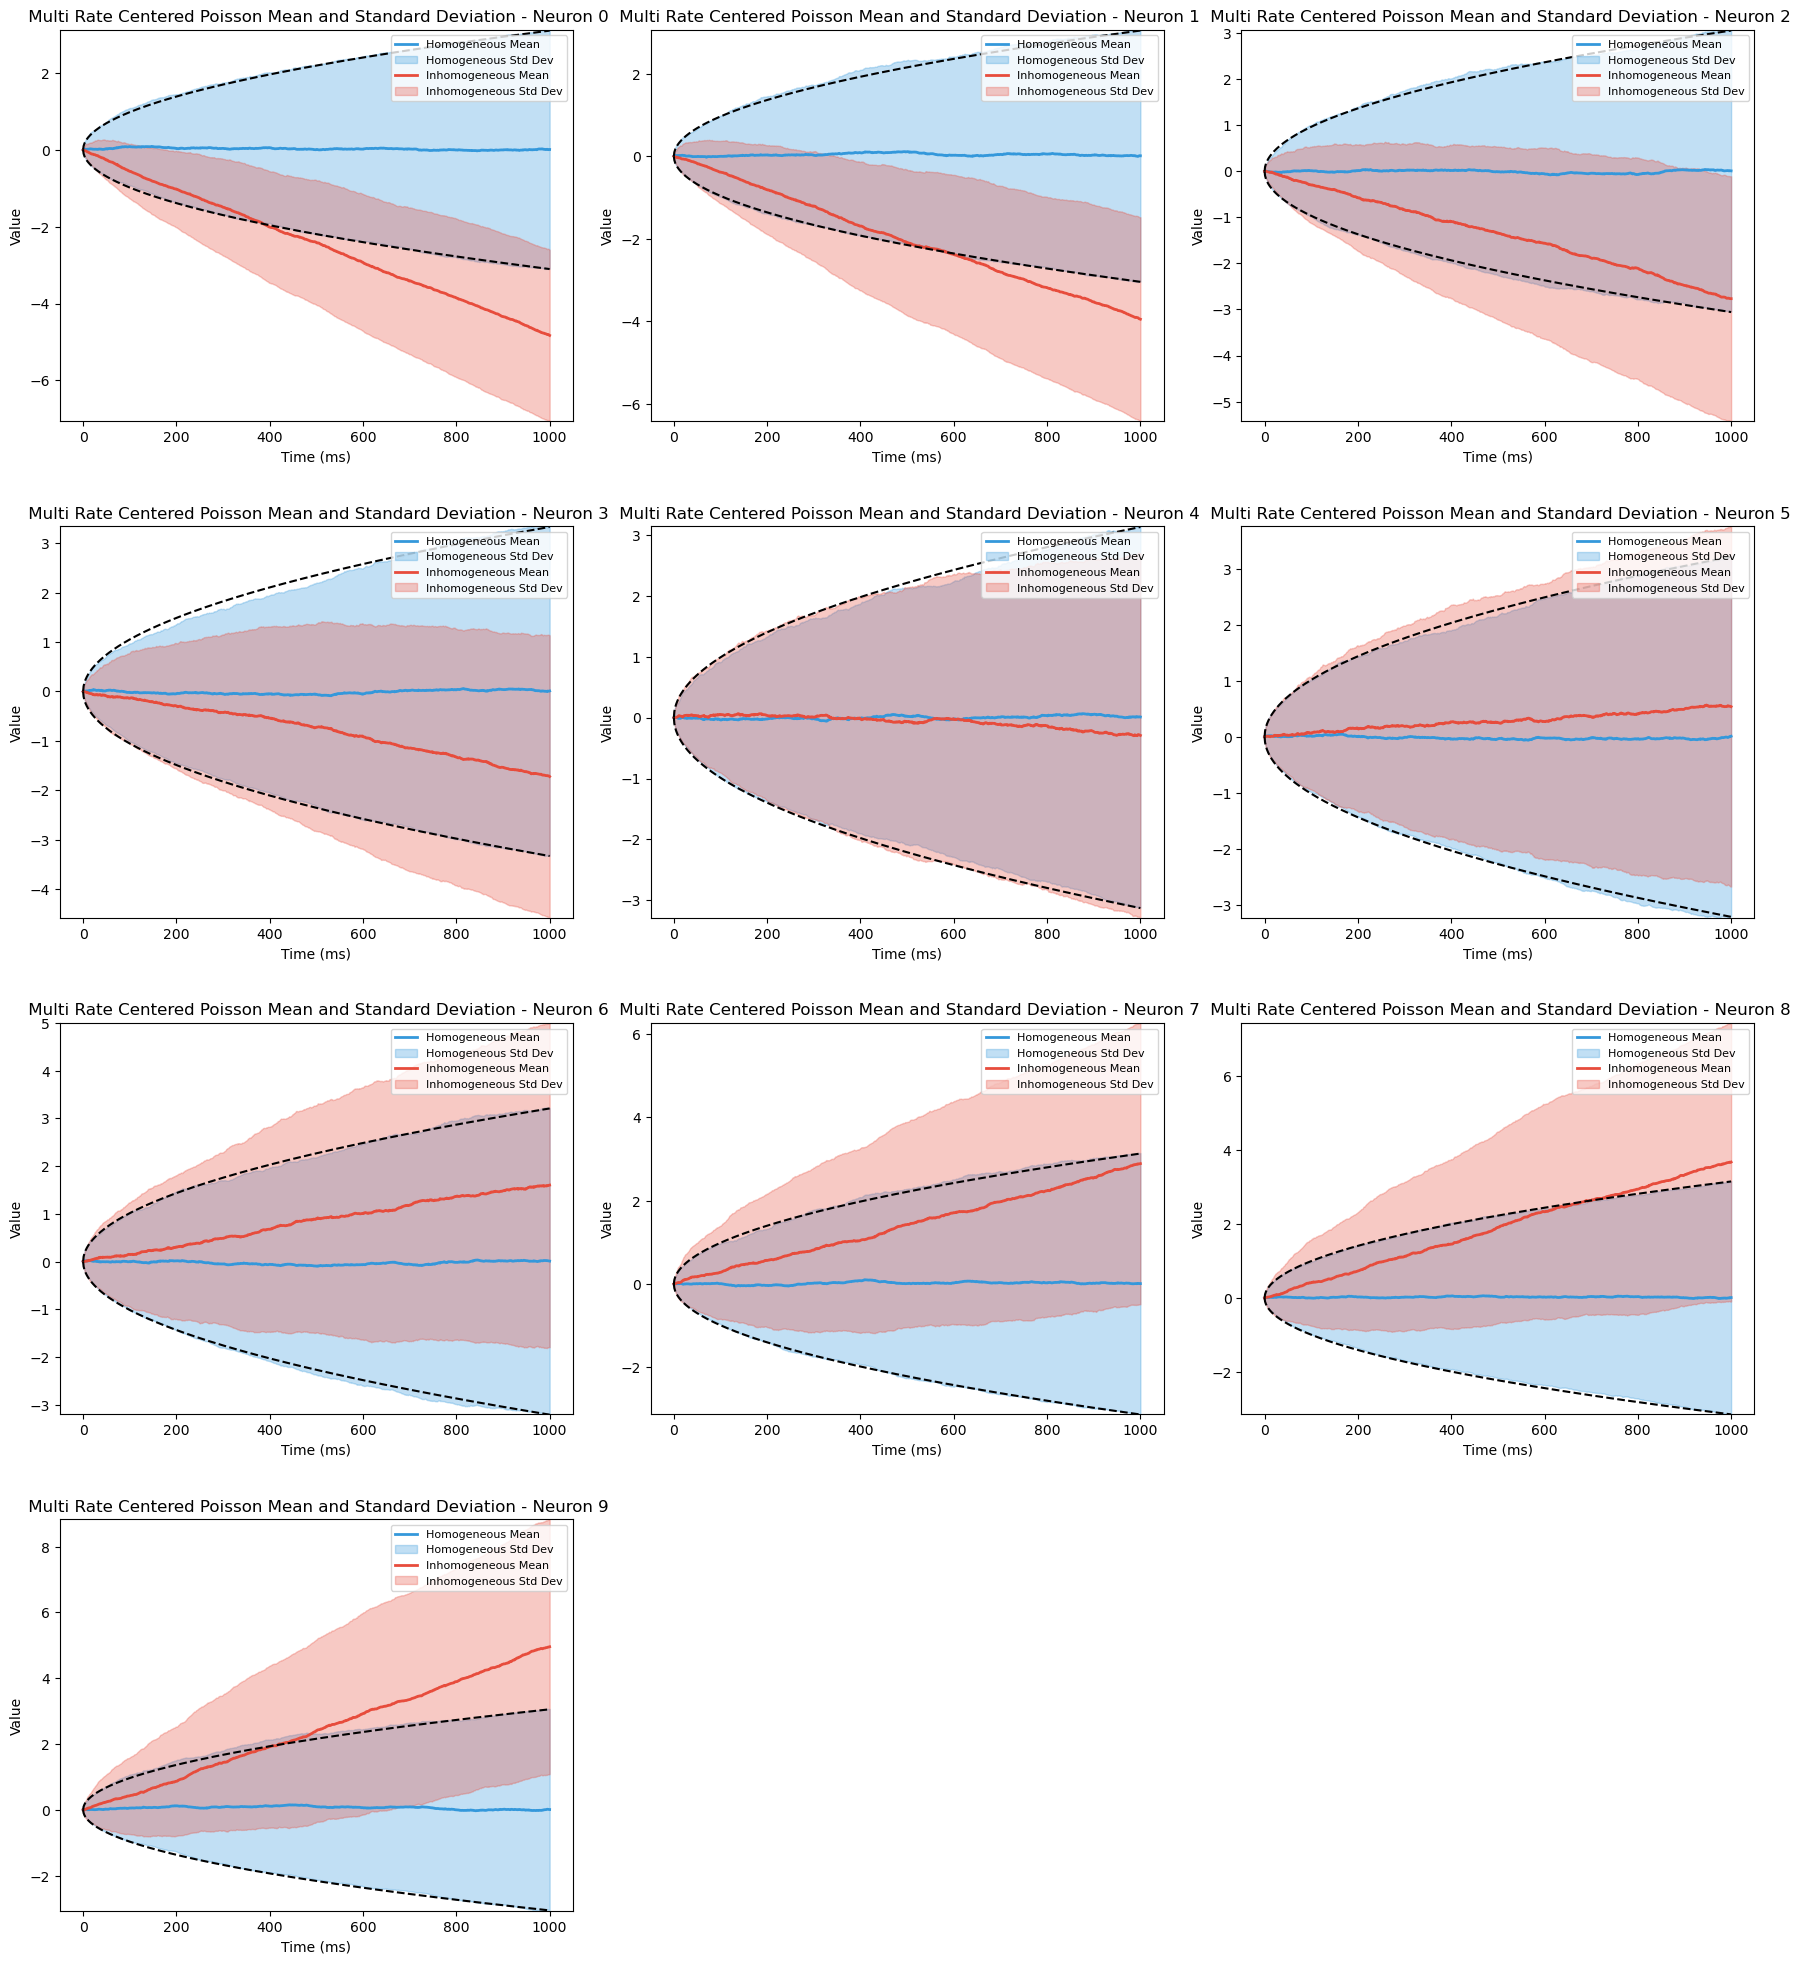

In [62]:
plot_multiple_stats(centers_mean, multi_rate_centers_mean_emp, centers_std_dev, multi_rate_centers_std_dev_emp, title = ' Multi Rate Centered Poisson Mean and Standard Deviation', show_hline=True, data_type='centered')
# plot_multiple_stats(multi_rate_centers_mean, multi_rate_centers_mean_emp, multi_rate_centers_std_dev, multi_rate_centers_std_dev_emp, title = ' Multi Rate Centered Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots

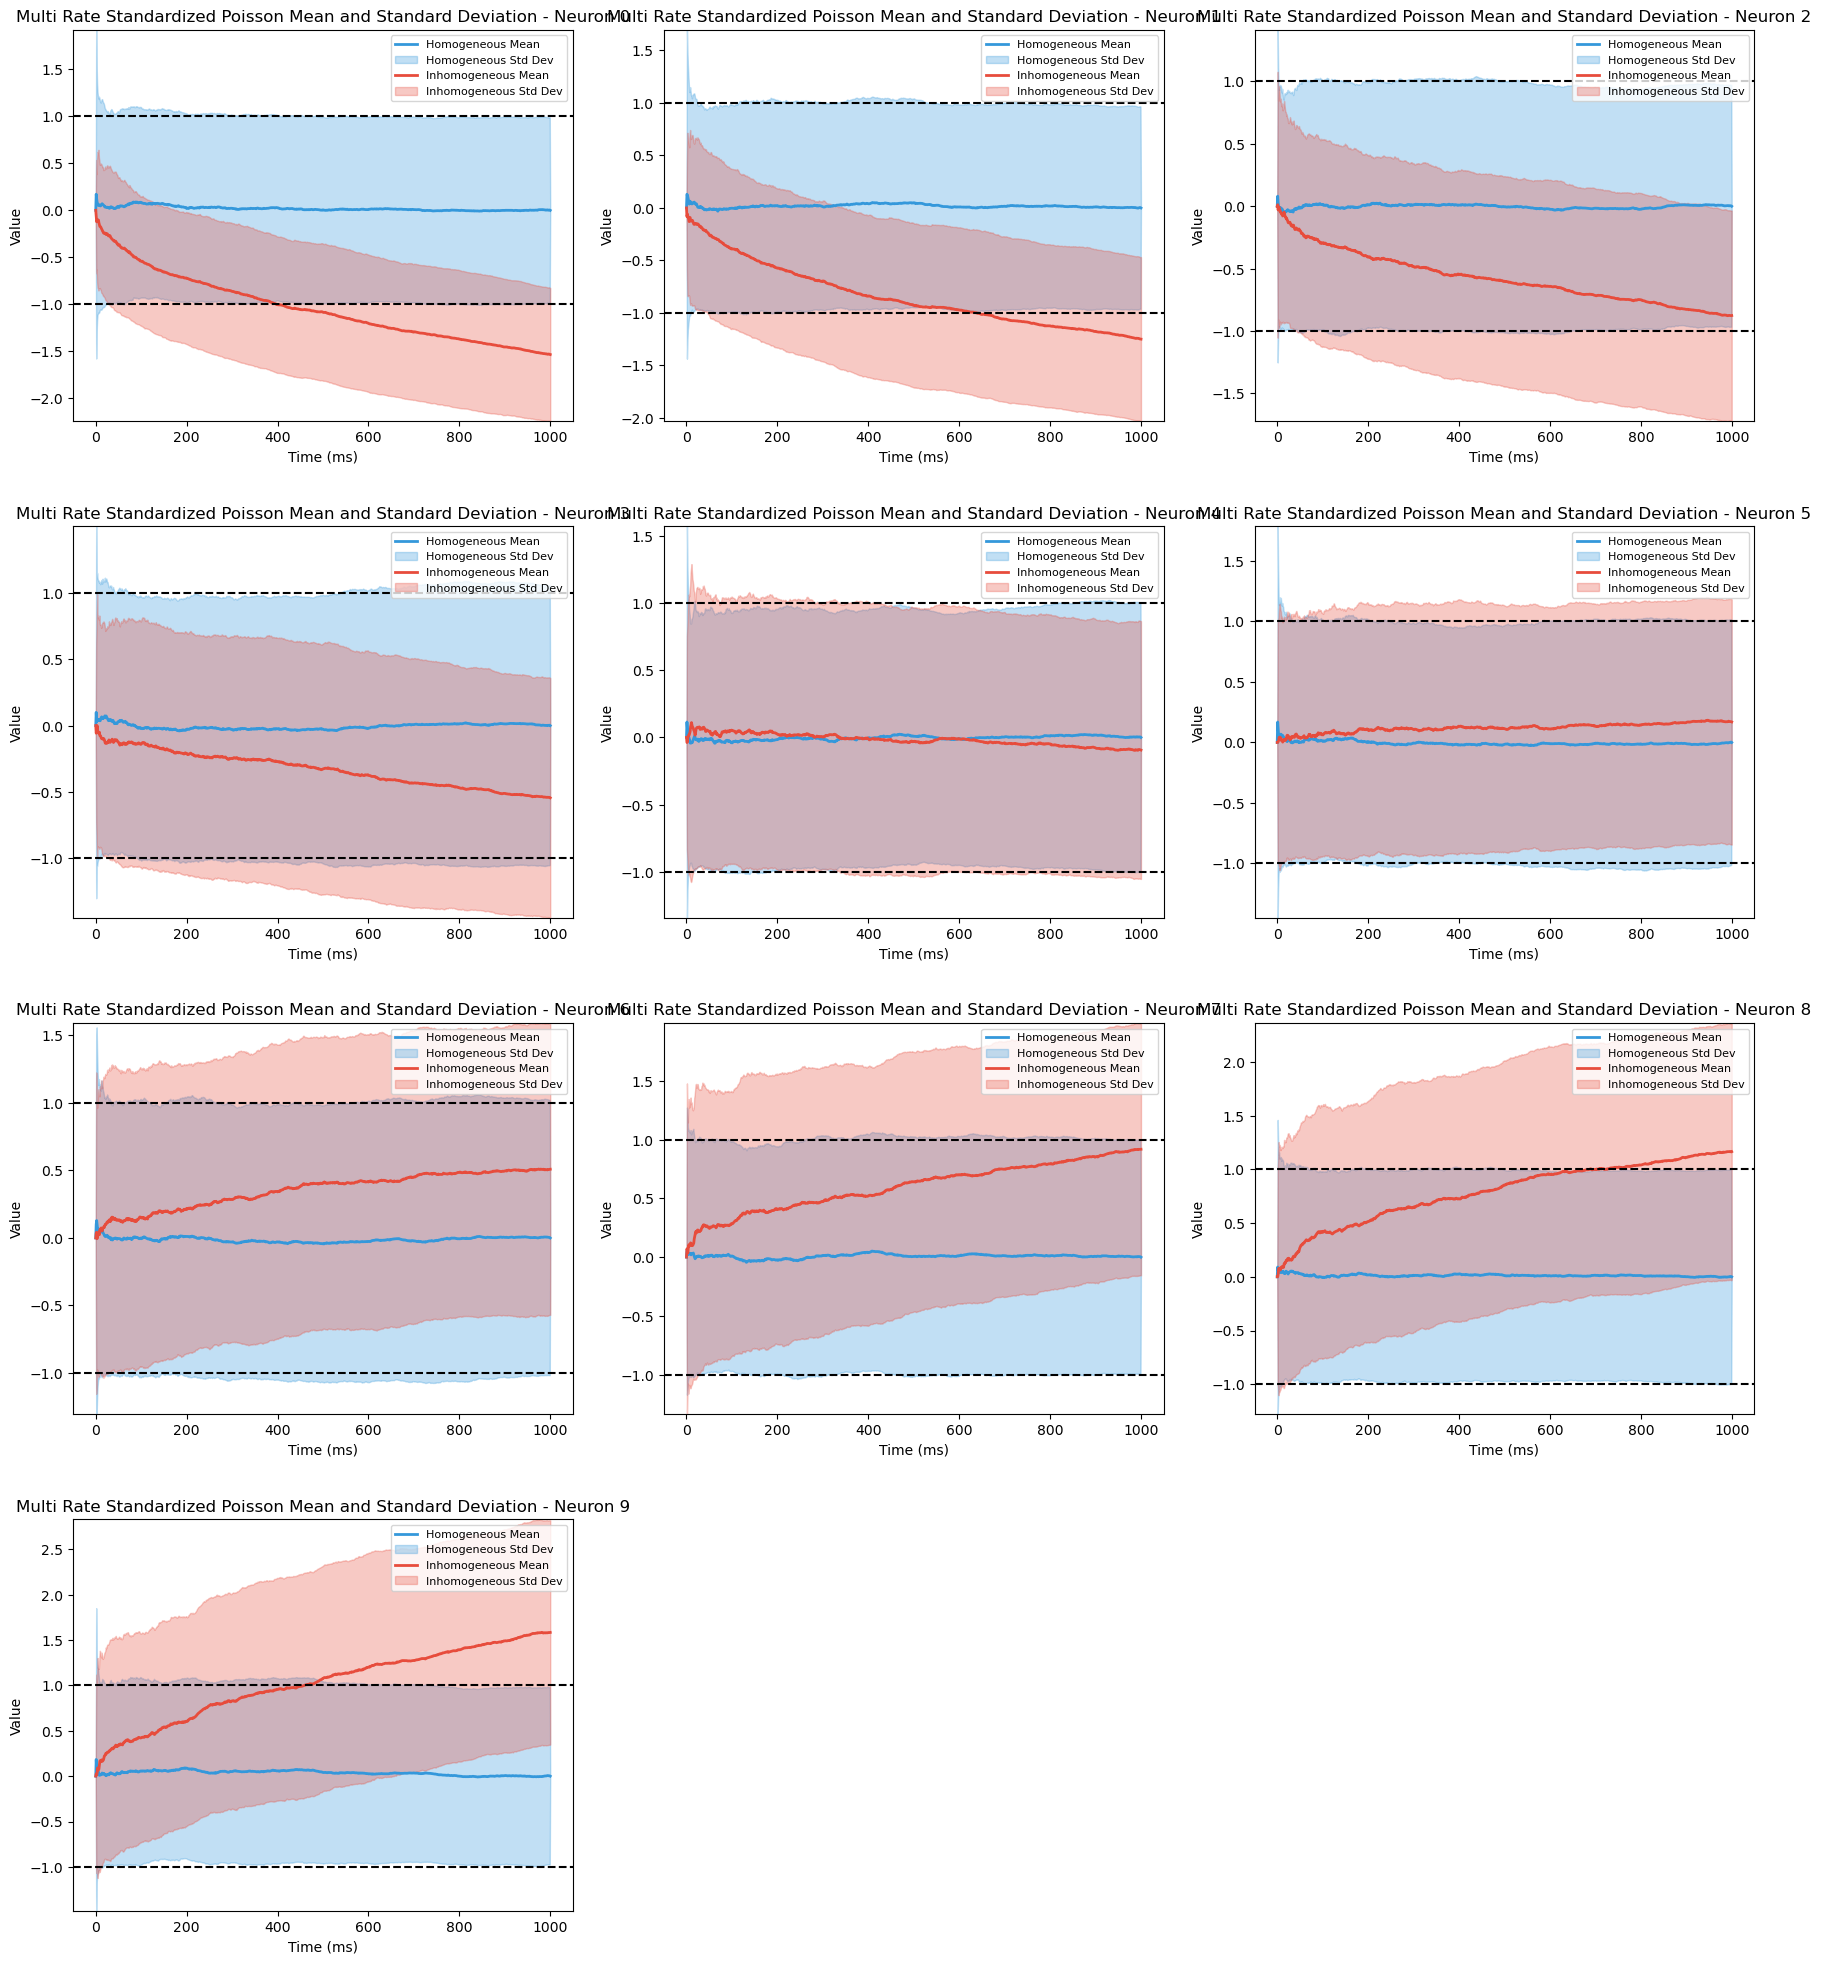

In [63]:
plot_multiple_stats(standardized_mean, multi_rate_standardized_mean_emp, standardized_std, multi_rate_standardized_std_emp, title = 'Multi Rate Standardized Poisson Mean and Standard Deviation', show_hline=True, data_type='standardized')
# plot_multiple_stats(multi_rate_standardized_mean, multi_rate_standardized_mean_emp, multi_rate_standardized_std, multi_rate_standardized_std_emp, title = 'Multi Rate Standardized Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots

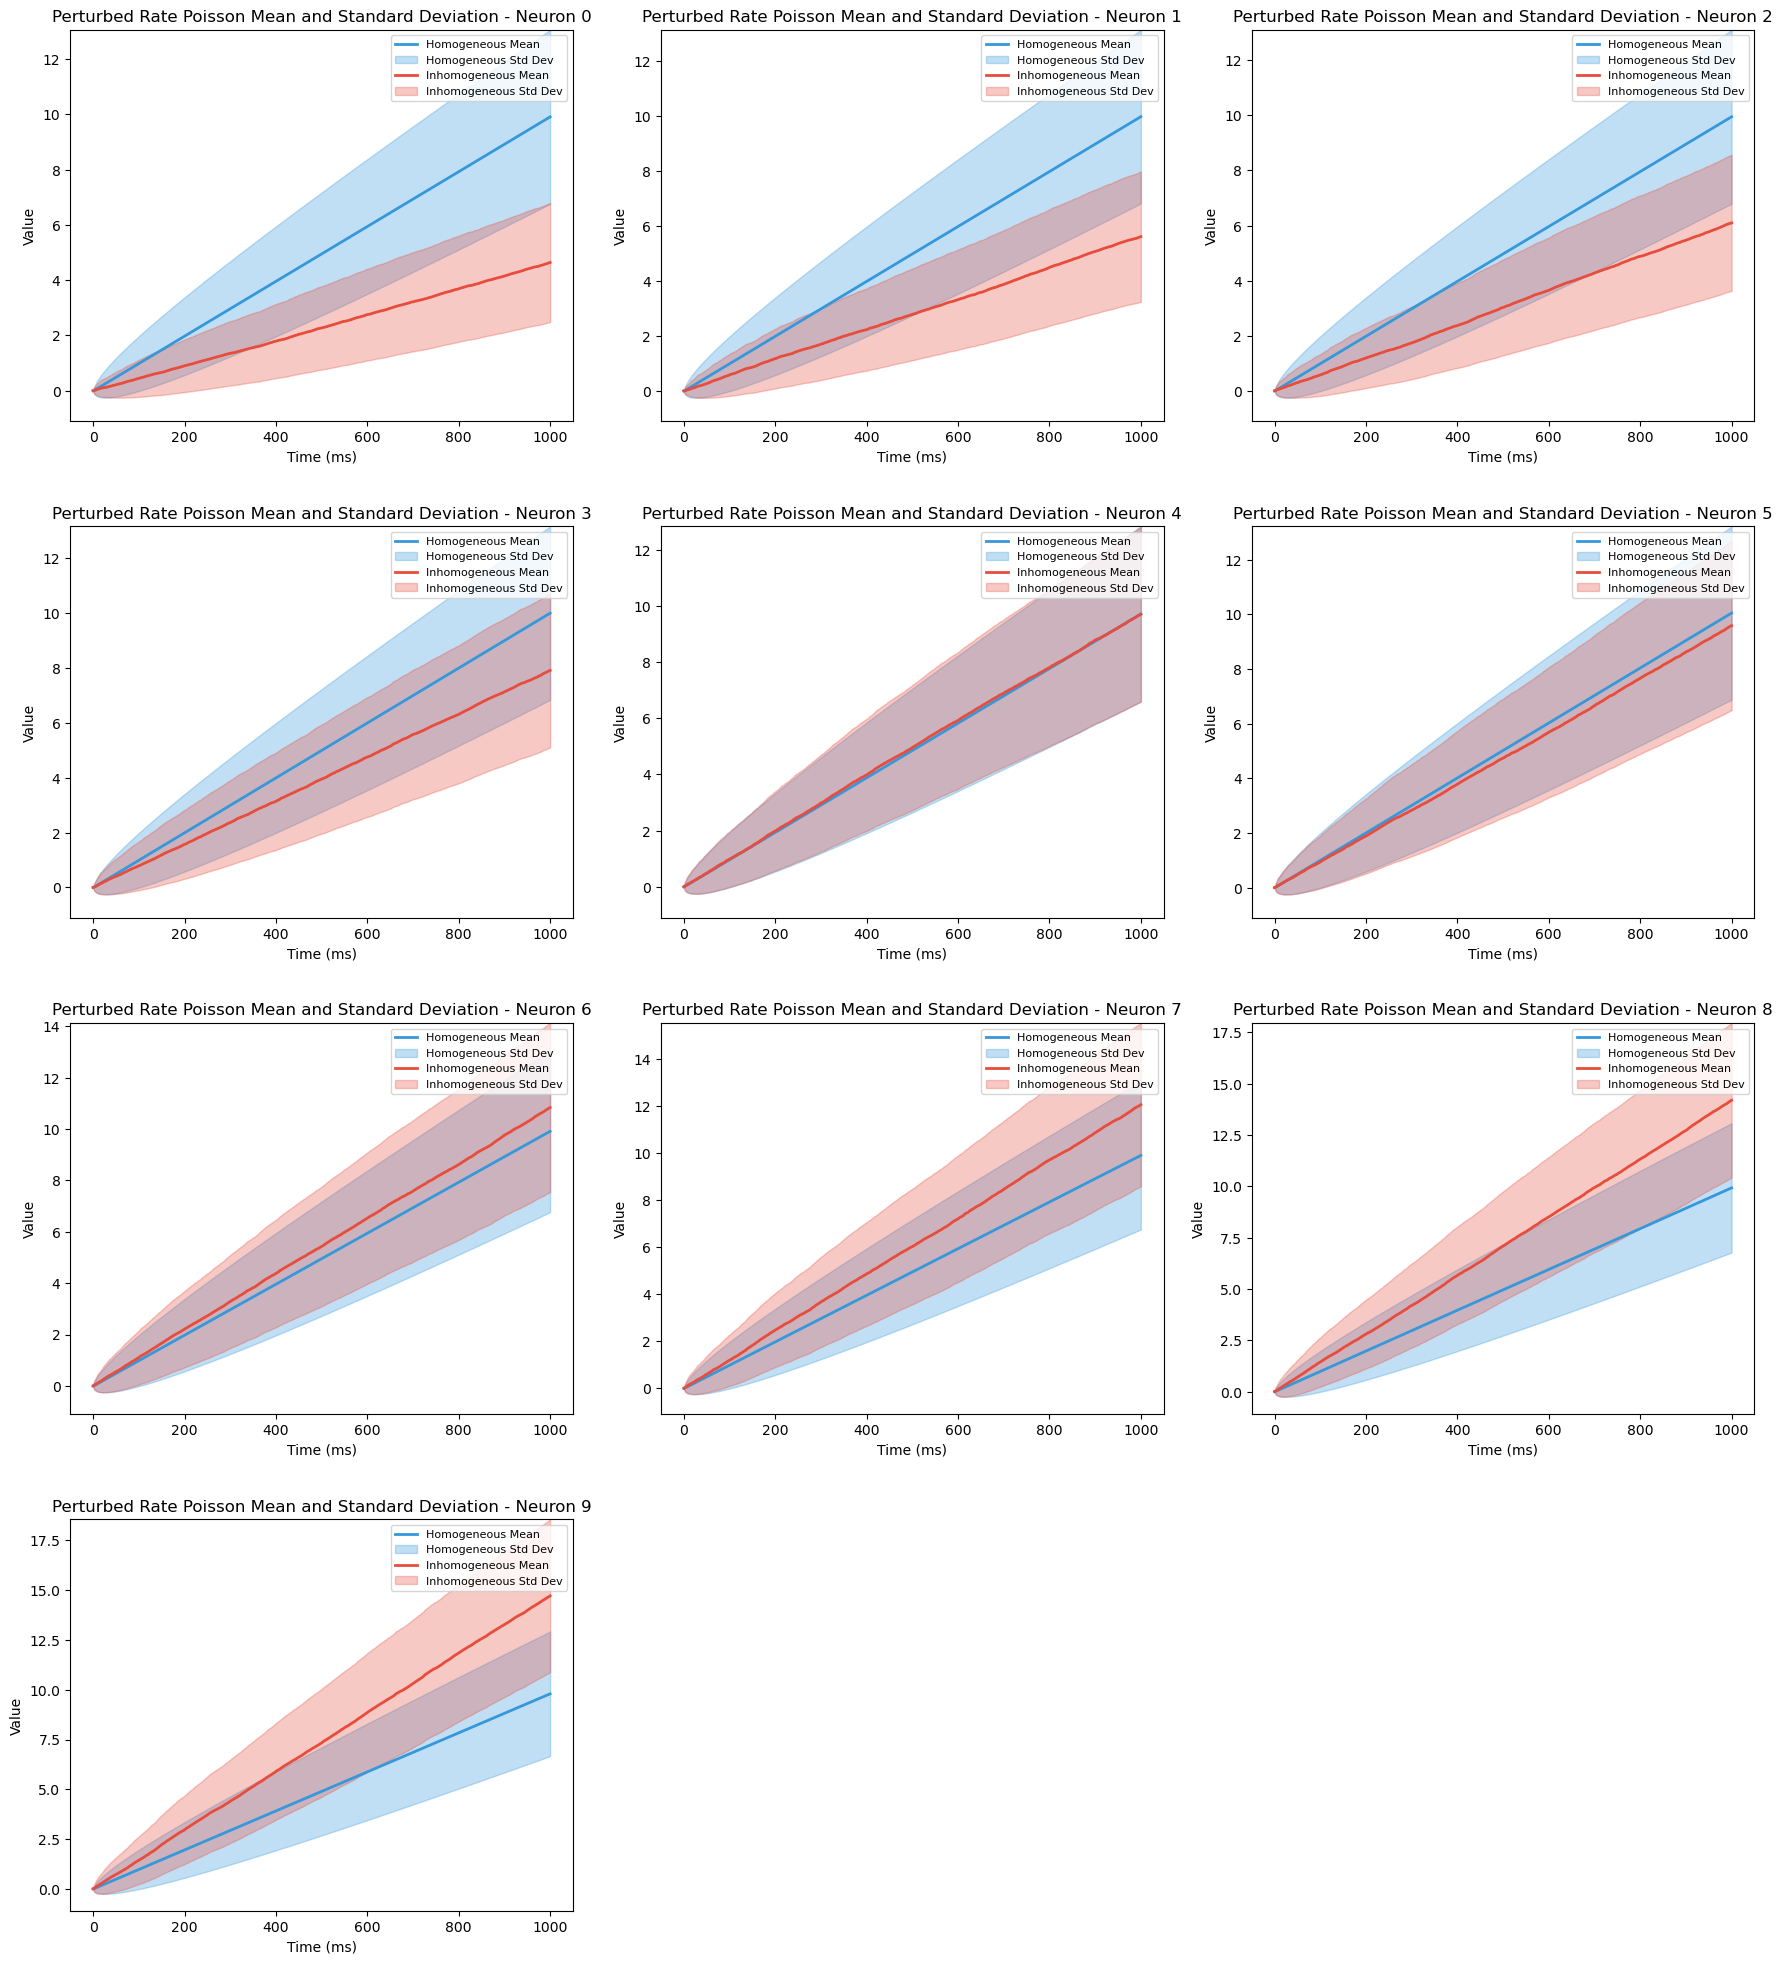

In [64]:
plot_multiple_stats(theoretical_means, perturbed_rate_empirical_mean, theoretical_std_dev, perturbed_rate_empirical_std_dev, title = 'Perturbed Rate Poisson Mean and Standard Deviation', show_hline=False, data_type='standardized')
# plot_multiple_stats(perturbed_rate_theoretical_means, perturbed_rate_empirical_mean, perturbed_rate_theoretical_std_dev, perturbed_rate_empirical_std_dev, title = 'Perturbed Rate Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots. For more precise plots we can go with isoclines.
# Aka lines with fixed probabilities

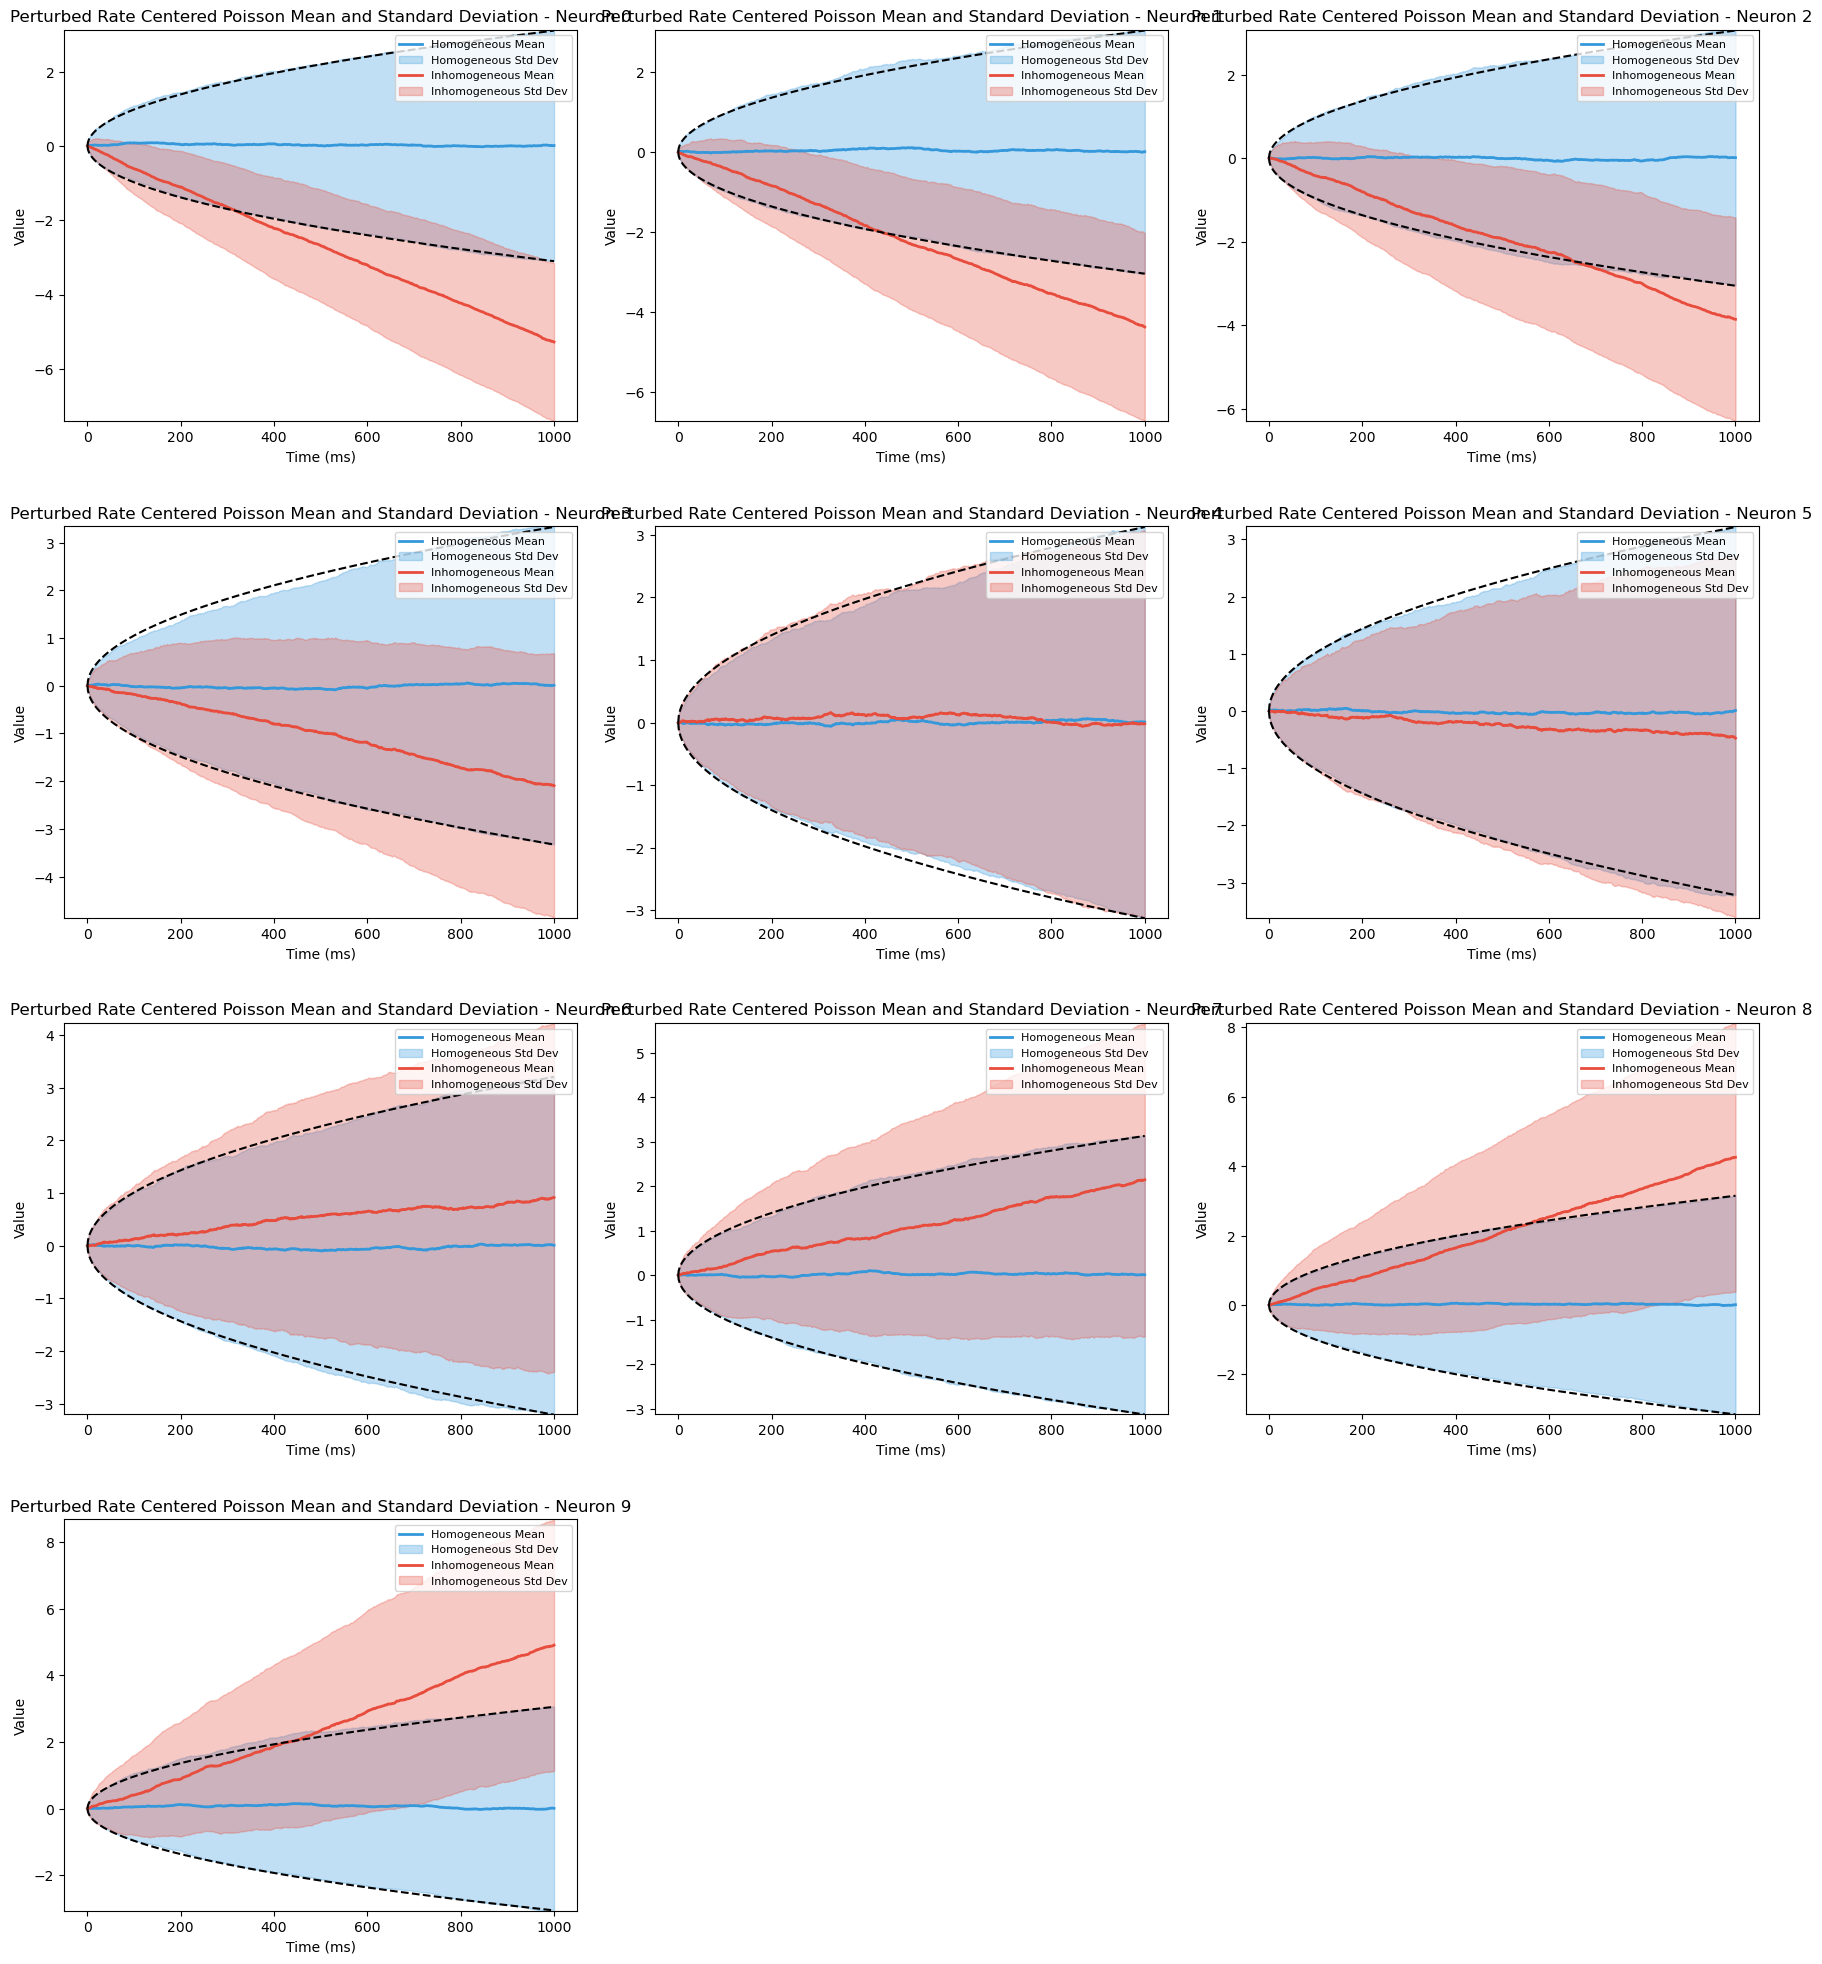

In [65]:
plot_multiple_stats(centers_mean, perturbed_rate_centers_mean_emp, centers_std_dev, perturbed_rate_centers_std_dev_emp, title = 'Perturbed Rate Centered Poisson Mean and Standard Deviation', show_hline=True, data_type='centered')
# plot_multiple_stats(perturbed_rate_centers_mean, perturbed_rate_centers_mean_emp, perturbed_rate_centers_std_dev, perturbed_rate_centers_std_dev_emp, title = 'Perturbed Rate Centered Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots

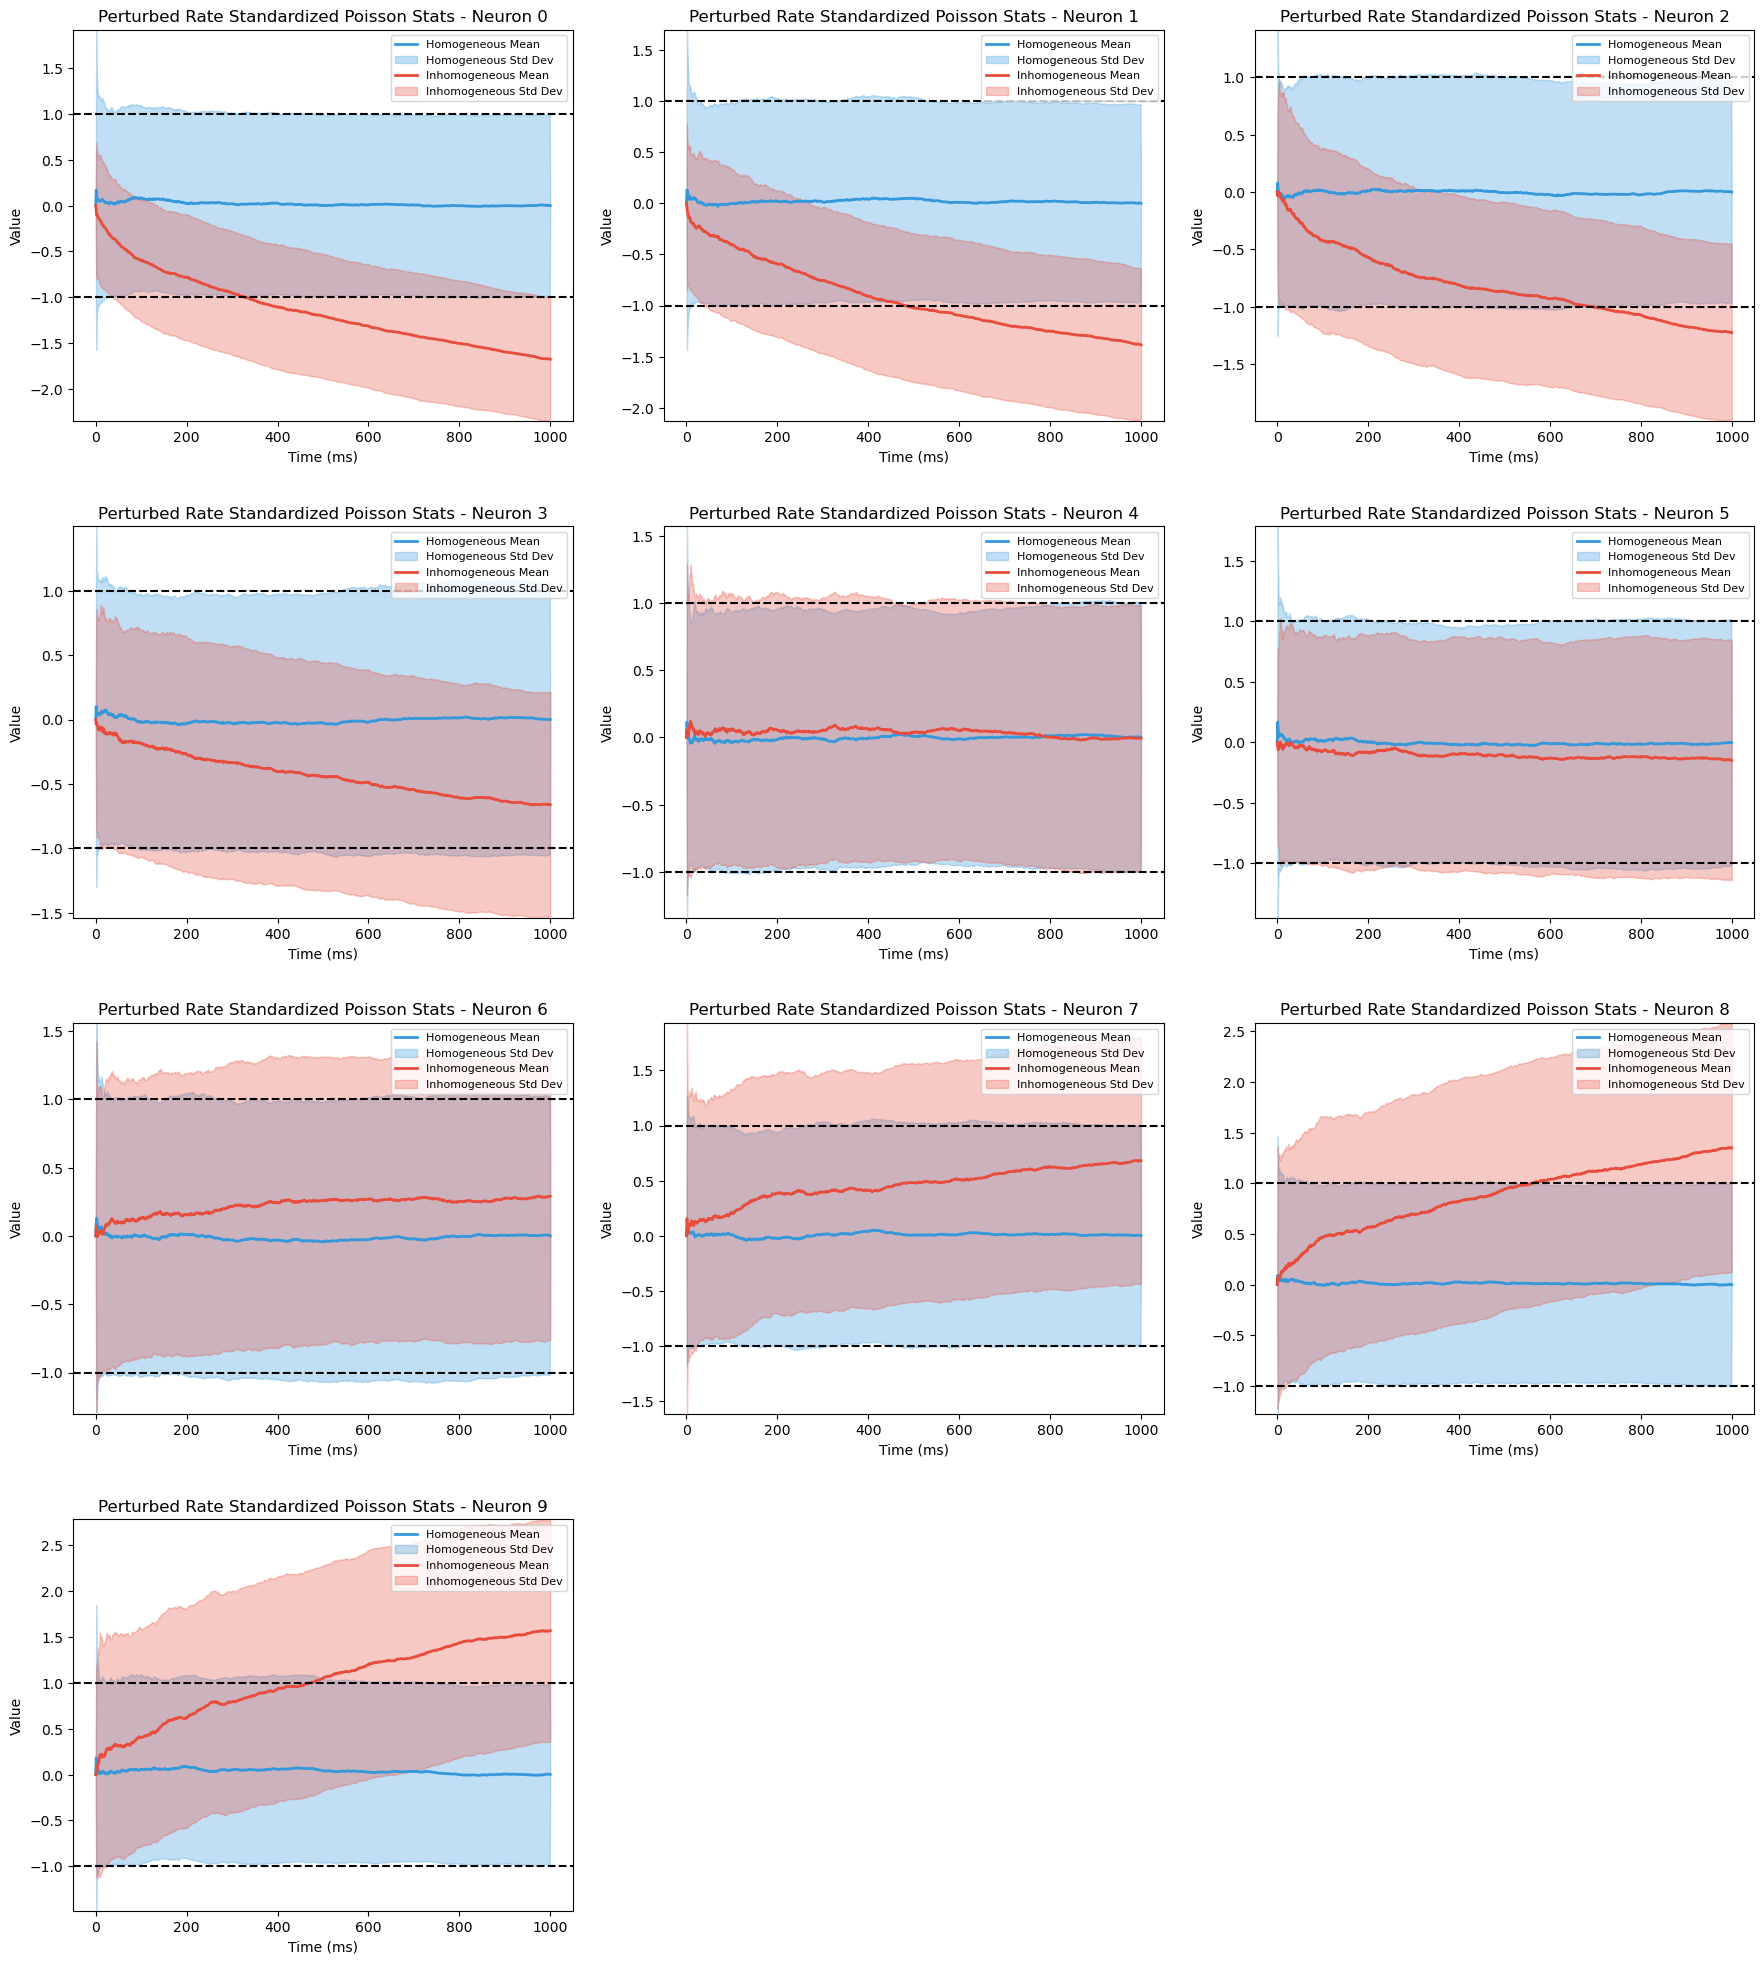

In [66]:
plot_multiple_stats(standardized_mean, perturbed_rate_standardized_mean_emp, standardized_std, perturbed_rate_standardized_std_emp, title = 'Perturbed Rate Standardized Poisson Stats', show_hline=True, data_type='standardized')
# plot_multiple_stats(perturbed_rate_standardized_mean, perturbed_rate_standardized_mean_emp, perturbed_rate_standardized_std, perturbed_rate_standardized_std_emp, title = 'Perturbed Rate Standardized Poisson Mean and Standard Deviation')
# Note in presentation highlight the difference y axis values between plots

center with their own mean, scale by the null std

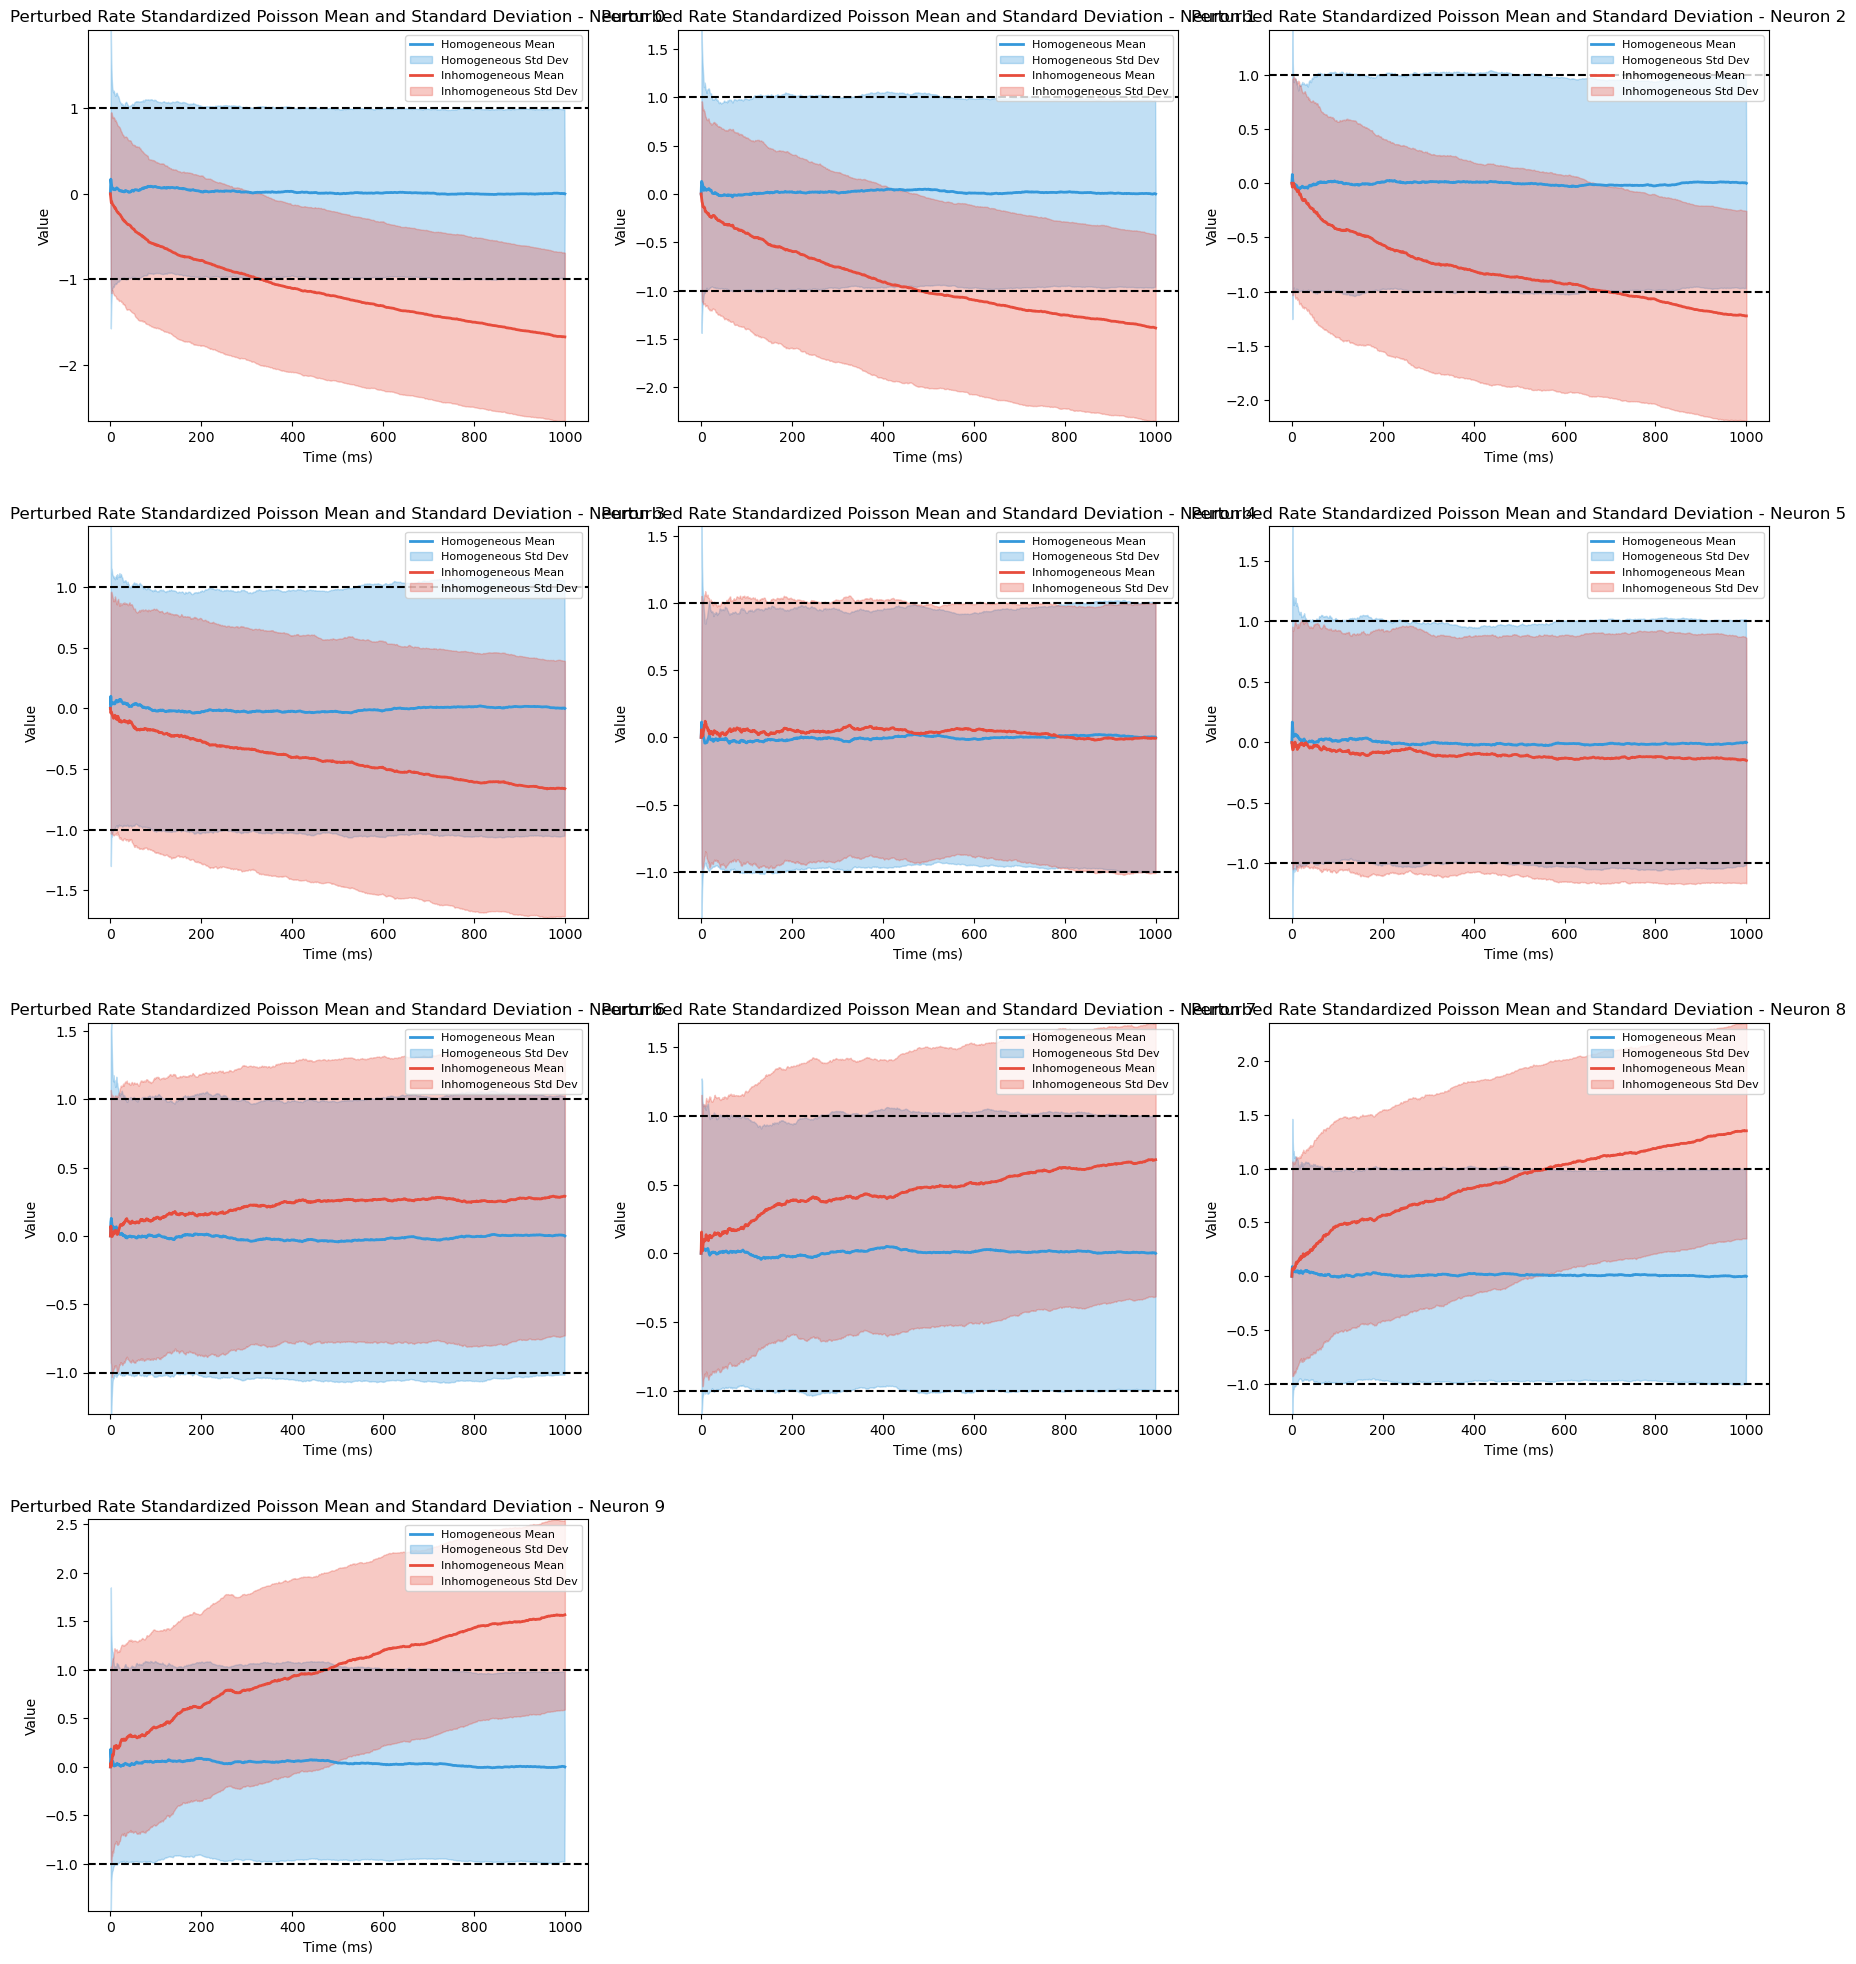

In [68]:
plot_multiple_stats(standardized_mean, perturbed_rate_standardized_mean_emp, standardized_std, standardized_std_emp, title = 'Perturbed Rate Standardized Poisson Mean and Standard Deviation', show_hline=True, data_type='standardized')

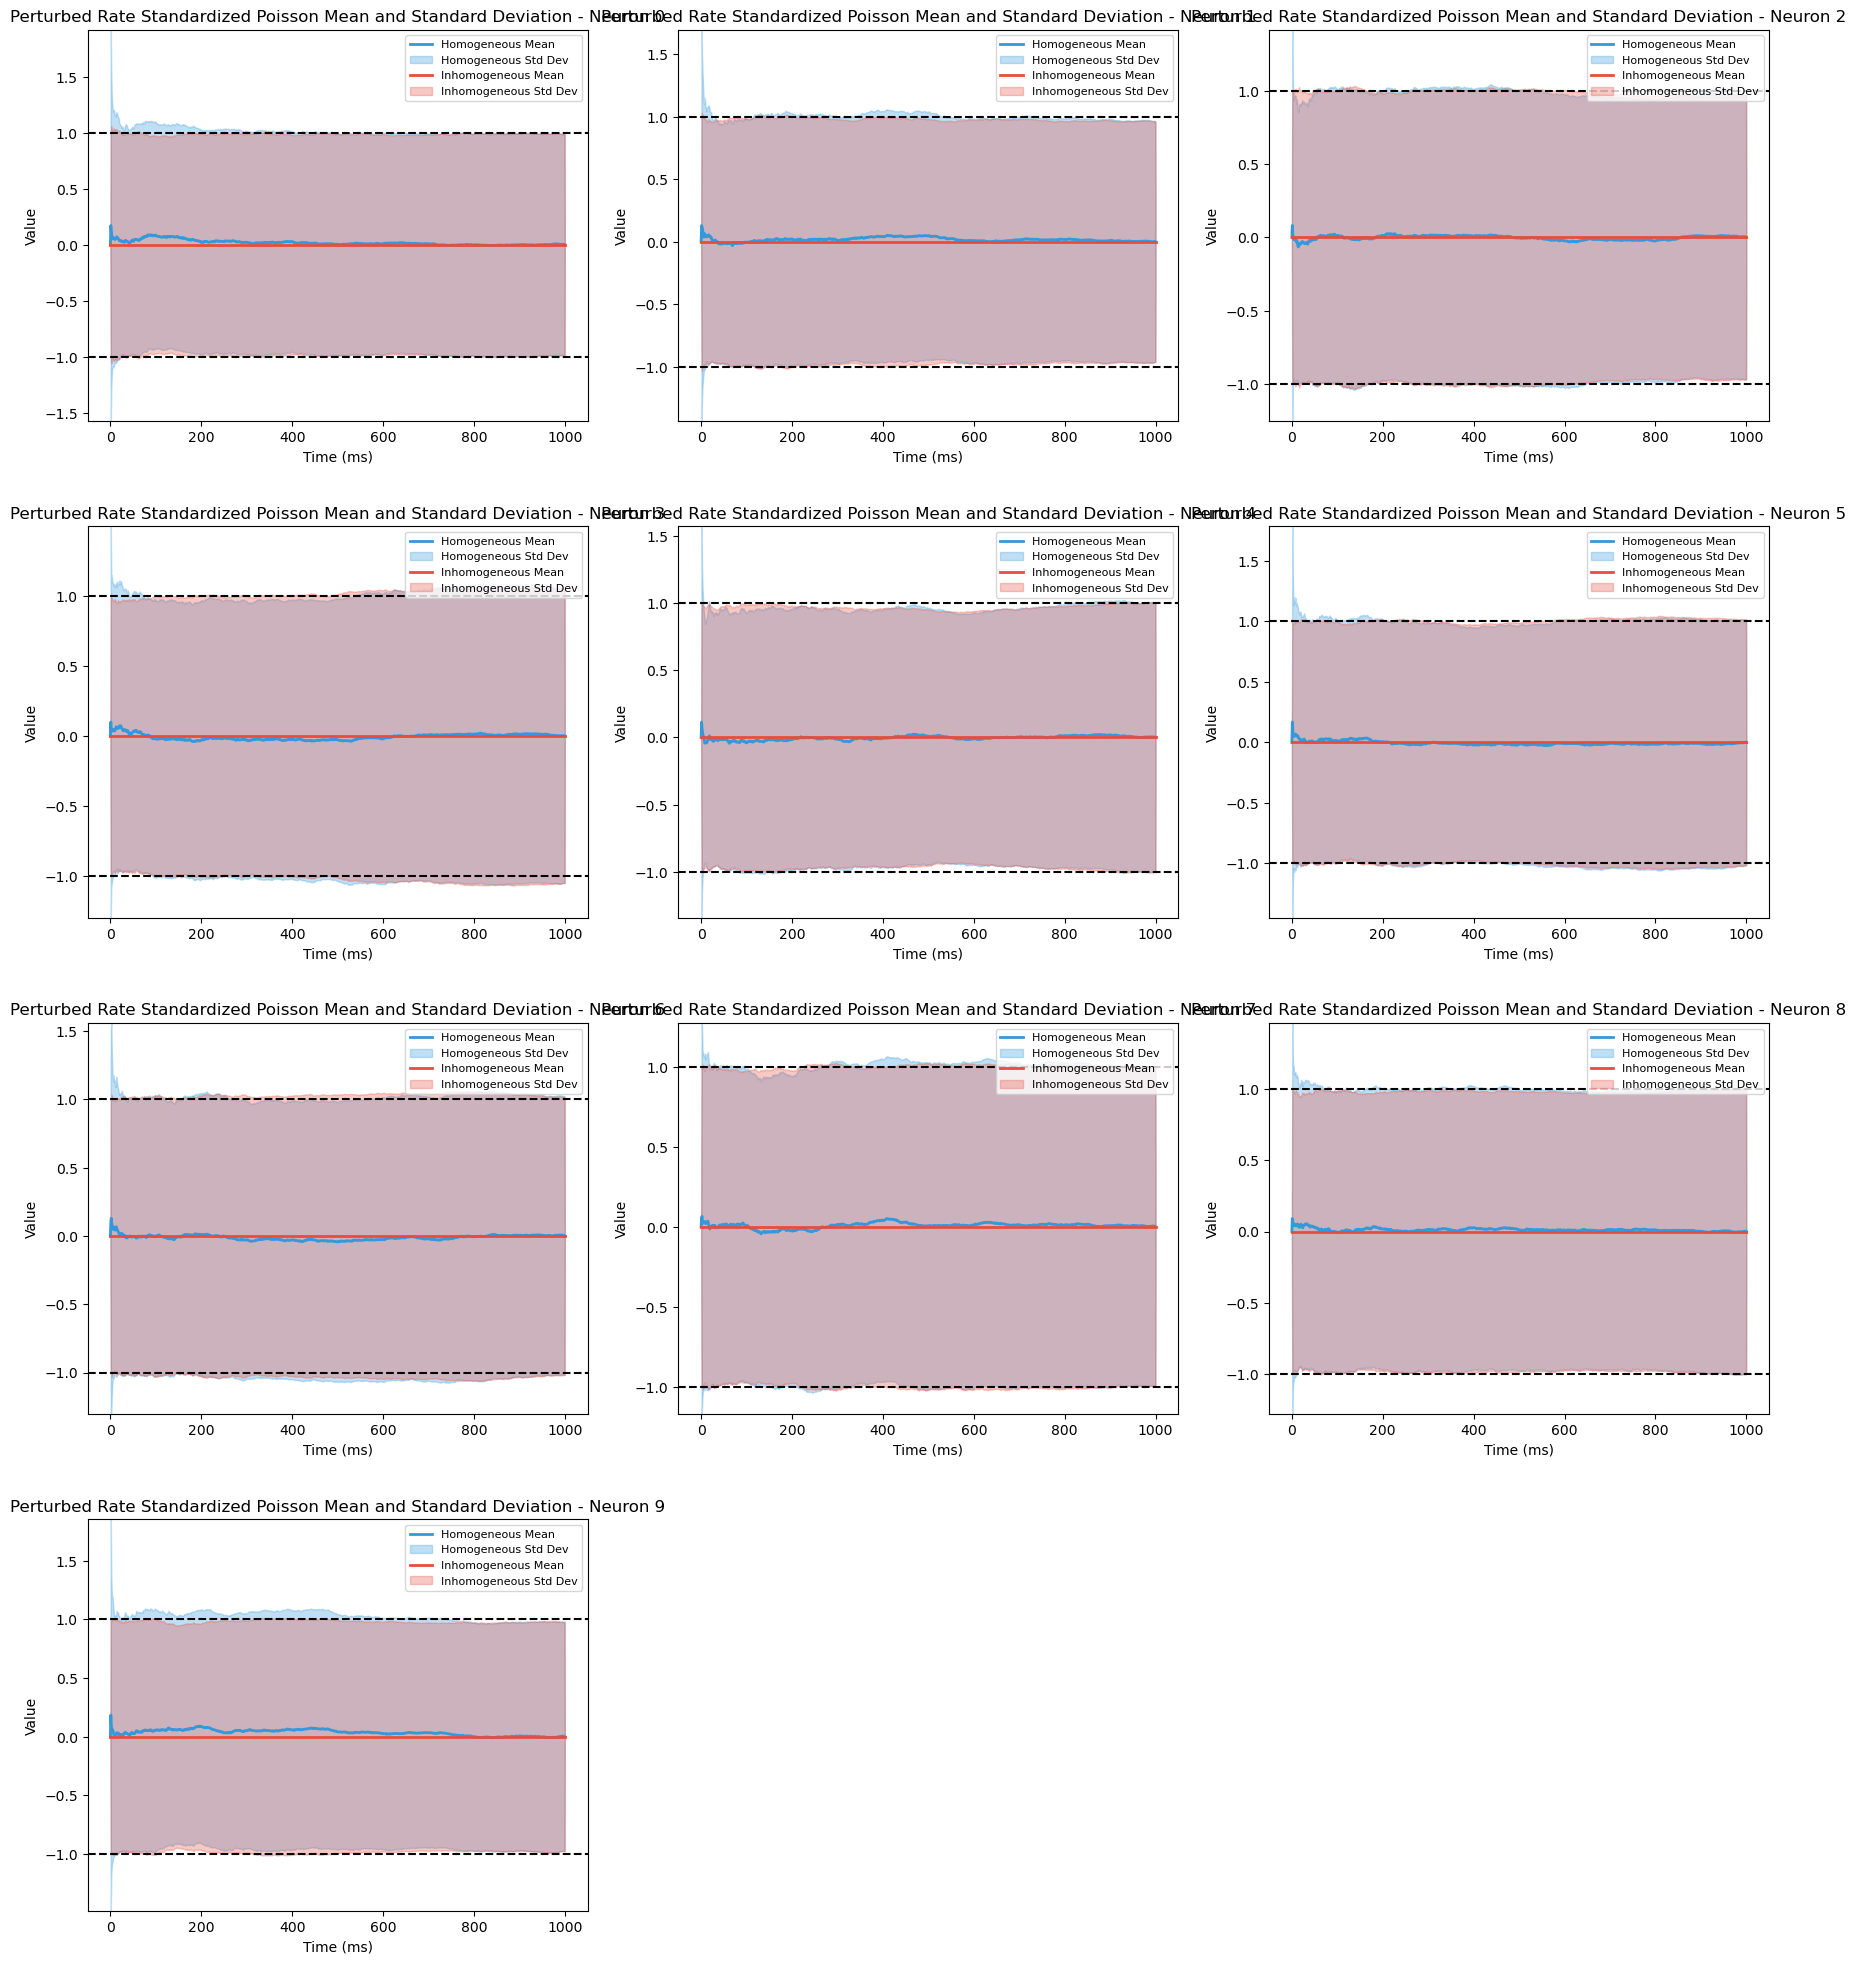

In [69]:
plot_multiple_stats(standardized_mean, perturbed_rate_standardized_mean_emp_test, standardized_std, standardized_std_emp, title = 'Perturbed Rate Standardized Poisson Mean and Standard Deviation', show_hline=True, data_type='standardized')

In [70]:
mean_check = check_mean_with_se(stands, expected_mean=0, confidence=0.95)
#print(mean_check)

mean_check_emp = check_mean_with_se(stands_emp, expected_mean=0, confidence=0.95)
#print(mean_check_emp)

In [71]:
multi_rate_mean_check = check_mean_with_se(multi_rate_stands, expected_mean=0, confidence=0.95)
multi_rate_mean_check_emp = check_mean_with_se(multi_rate_stands_emp, expected_mean=0, confidence=0.95)

In [72]:
perturbed_rate_mean_check = check_mean_with_se(perturbed_rate_stands, expected_mean=0, confidence=0.95)
perturbed_rate_mean_check_emp = check_mean_with_se(perturbed_rate_stands_emp, expected_mean=0, confidence=0.95)

In [73]:
serialized_count = serialize_counts(stands) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count.shape)
#print(np.mean(serialized_count))
t_stat, p_val_mean = stats.ttest_1samp(serialized_count, np.mean(serialized_count))
#print(t_stat)
#print(p_val_mean)

    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables


serialized_count_emp = serialize_counts(stands_emp)
#print(serialized_count_emp.shape)
#print(np.mean(serialized_count_emp))
t_stat_emp, p_val_mean_emp = stats.ttest_1samp(serialized_count, np.mean(serialized_count))
#print(t_stat_emp)
#print(p_val_mean_emp)

In [74]:
multi_rate_serialized_count = serialize_counts(multi_rate_stands) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
multi_rate_t_stat, multi_rate_p_val_mean = stats.ttest_1samp(multi_rate_serialized_count, np.mean(multi_rate_serialized_count))

multi_rate_serialized_count_emp = serialize_counts(multi_rate_stands_emp)

multi_rate_t_stat_emp, multi_rate_p_val_mean_emp = stats.ttest_1samp(multi_rate_serialized_count_emp, np.mean(multi_rate_serialized_count_emp))

In [75]:
perturbed_rate_serialized_count = serialize_counts(perturbed_rate_stands) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
perturbed_rate_t_stat, perturbed_rate_p_val_mean = stats.ttest_1samp(perturbed_rate_serialized_count, np.mean(perturbed_rate_serialized_count))

perturbed_rate_serialized_count_emp = serialize_counts(perturbed_rate_stands_emp)

perturbed_rate_t_stat_emp, perturbed_rate_p_val_mean_emp = stats.ttest_1samp(perturbed_rate_serialized_count_emp, np.mean(perturbed_rate_serialized_count_emp))

In [76]:
#reshaped_stands = np.reshape(stands, (-1, stands.shape[1]), order='F')
# reshaped_stands = stands.transpose(1, 0, 2).reshape(stands.shape[1], -1)
reshaped_stands = np.transpose(stands, (1, 0, 2)).reshape(stands.shape[1], -1)
# transpose_stands = np.transpose(stands, (1, 0, 2))
#print(stands.shape)
#print(reshaped_stands.shape)

#reshaped_stands_emp = np.reshape(stands_emp, (-1, stands_emp.shape[1]), order='F')
# reshaped_stands_emp = stands.transpose(1, 0, 2).reshape(stands_emp.shape[1], -1)
reshaped_stands_emp = np.transpose(stands_emp, (1, 0, 2)).reshape(stands_emp.shape[1], -1)
#print(stands_emp.shape)
#print(reshaped_stands_emp.shape)

In [77]:
multi_rate_reshaped_stands = np.transpose(multi_rate_stands, (1, 0, 2)).reshape(multi_rate_stands.shape[1], -1)
multi_rate_reshaped_stands_emp = np.transpose(multi_rate_stands_emp, (1, 0, 2)).reshape(multi_rate_stands_emp.shape[1], -1)

In [78]:
perturbed_rate_reshaped_stands = np.transpose(perturbed_rate_stands, (1, 0, 2)).reshape(perturbed_rate_stands.shape[1], -1)
perturbed_rate_reshaped_stands_emp = np.transpose(perturbed_rate_stands_emp, (1, 0, 2)).reshape(perturbed_rate_stands_emp.shape[1], -1)

In [79]:
#print(transpose_stands.shape)
#print(transpose_stands[:,:,0])

In [80]:
#print(transpose_stands[:,:,0:3])

In [81]:
#print(reshaped_stands.shape)
#print(reshaped_stands[:,0])

In [82]:
#print(reshaped_stands[:,:5])

In [83]:
#### TESTING #####

In [84]:
test_stand = standardize_per_neuron(count, exclude=global_exclude)


=== Post-standardization checks (excluded t < 0 ) ===
Max |mean|: 1.655e-16 (should be close to 0)
Max |std - 1|: 8.882e-16 (should be close to 0)


In [85]:
#print(test_stand.shape)

In [86]:
cov_matrix = cov_standardized_data(reshaped_stands)
cov_matrix_emp = cov_standardized_data(reshaped_stands_emp)

In [87]:
multi_rate_cov_matrix = cov_standardized_data(multi_rate_reshaped_stands)
multi_rate_cov_matrix_emp = cov_standardized_data(multi_rate_reshaped_stands_emp)

In [88]:
perturbed_rate_cov_matrix = cov_standardized_data(perturbed_rate_reshaped_stands)
perturbed_rate_cov_matrix_emp = cov_standardized_data(perturbed_rate_reshaped_stands_emp)

array([[ 1.00075082e+00,  1.61644509e-04,  2.59860096e-02,
        -1.54625177e-02, -8.09529120e-03,  3.53333382e-03,
         3.28738703e-02, -4.09403553e-03, -1.60263076e-02,
         1.65907367e-02],
       [ 1.61644509e-04,  9.74890593e-01, -9.33294642e-03,
         2.49260466e-02, -8.00897600e-03, -5.22825404e-03,
         2.24796009e-02, -1.37471902e-02, -3.67255254e-02,
        -2.75878055e-02],
       [ 2.59860096e-02, -9.33294642e-03,  9.80294907e-01,
        -1.43137670e-02,  6.31635250e-03,  1.59521219e-02,
        -7.60662385e-03,  4.40656402e-02,  2.34753074e-02,
         9.79522066e-03],
       [-1.54625177e-02,  2.49260466e-02, -1.43137670e-02,
         1.05105088e+00, -1.28356315e-02, -1.81880806e-02,
         1.56575252e-03, -1.93874833e-02, -1.07977386e-03,
        -1.37673114e-02],
       [-8.09529120e-03, -8.00897600e-03,  6.31635250e-03,
        -1.28356315e-02,  9.37434806e-01,  1.27957123e-03,
        -1.31387742e-02,  1.17894976e-02, -1.14834148e-02,
        -1.

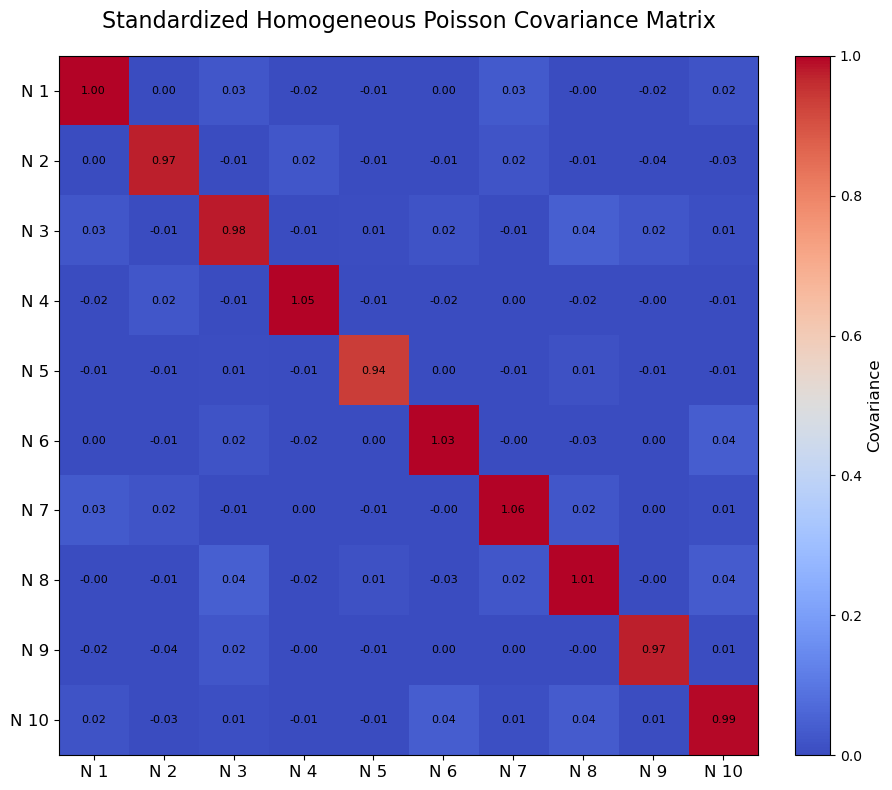

In [89]:
plot_covariance_matrix(cov_matrix, normalize=False, title='Standardized Homogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 9.79268944e-01, -1.24688249e-04,  2.59894116e-02,
        -1.56905681e-02, -7.84915864e-03,  3.71656416e-03,
         3.27850684e-02, -4.11540288e-03, -1.59887738e-02,
         1.49947166e-02],
       [-1.24688249e-04,  9.61446655e-01, -9.15372167e-03,
         2.51490341e-02, -7.99298469e-03, -5.08523710e-03,
         2.28458348e-02, -1.36966503e-02, -3.66381410e-02,
        -2.79103244e-02],
       [ 2.59894116e-02, -9.15372167e-03,  9.82198887e-01,
        -1.42772418e-02,  6.24415473e-03,  1.59832295e-02,
        -7.61007526e-03,  4.38739559e-02,  2.35058232e-02,
         9.65264146e-03],
       [-1.56905681e-02,  2.51490341e-02, -1.42772418e-02,
         1.05017842e+00, -1.30728120e-02, -1.80864316e-02,
         1.24440898e-03, -1.93321516e-02, -7.54531479e-04,
        -1.29393234e-02],
       [-7.84915864e-03, -7.99298469e-03,  6.24415473e-03,
        -1.30728120e-02,  9.40449898e-01,  1.38143589e-03,
        -1.31391717e-02,  1.17856409e-02, -1.14245990e-02,
        -1.

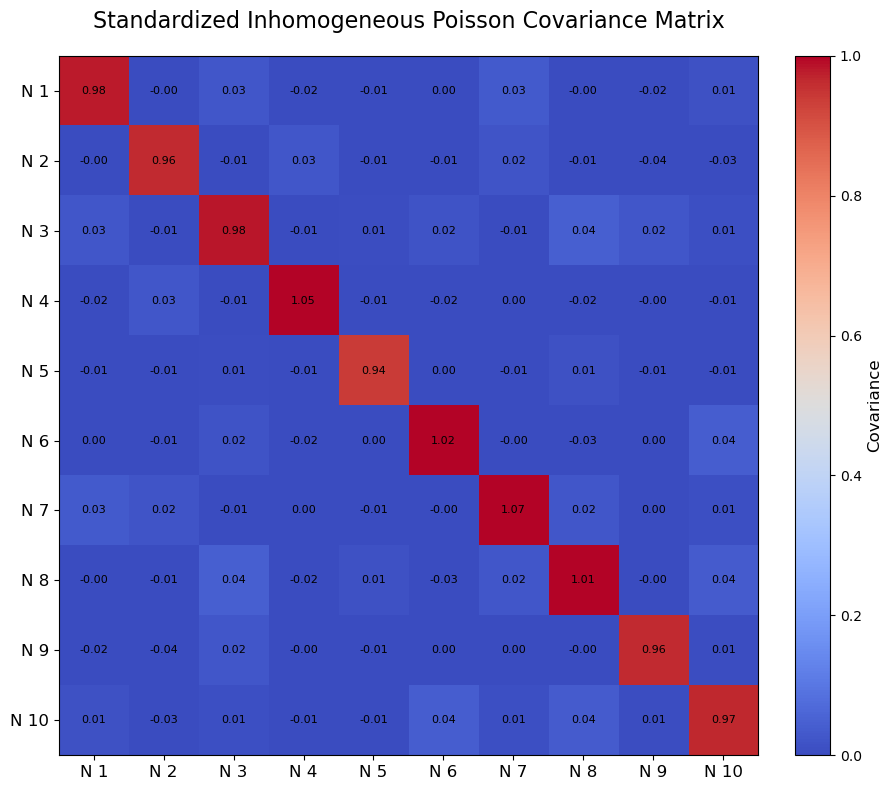

In [90]:
plot_covariance_matrix(cov_matrix_emp, normalize=False, title='Standardized Inhomogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 1.71285187,  0.94868068,  0.67769344,  0.40051995,  0.02575514,
        -0.10894643, -0.40042624, -0.70468542, -0.90590588, -1.19402508],
       [ 0.94868068,  1.38537118,  0.52730841,  0.32510738,  0.01243325,
        -0.1035768 , -0.28140029, -0.57807278, -0.77777108, -1.01662265],
       [ 0.67769344,  0.52730841,  1.07849463,  0.21134464, -0.0090796 ,
        -0.05365981, -0.24187856, -0.39638509, -0.557655  , -0.66852563],
       [ 0.40051995,  0.32510738,  0.21134464,  0.97822923,  0.0092655 ,
        -0.06549573, -0.15143182, -0.22014231, -0.33786383, -0.39097337],
       [ 0.02575514,  0.01243325, -0.0090796 ,  0.0092655 ,  0.97393622,
        -0.01023897, -0.02297035,  0.00586862, -0.00405295, -0.05753013],
       [-0.10894643, -0.1035768 , -0.05365981, -0.06549573, -0.01023897,
         1.0610877 ,  0.04874523,  0.09045884,  0.09365824,  0.14813339],
       [-0.40042624, -0.28140029, -0.24187856, -0.15143182, -0.02297035,
         0.04874523,  1.30079796,  0.27214898

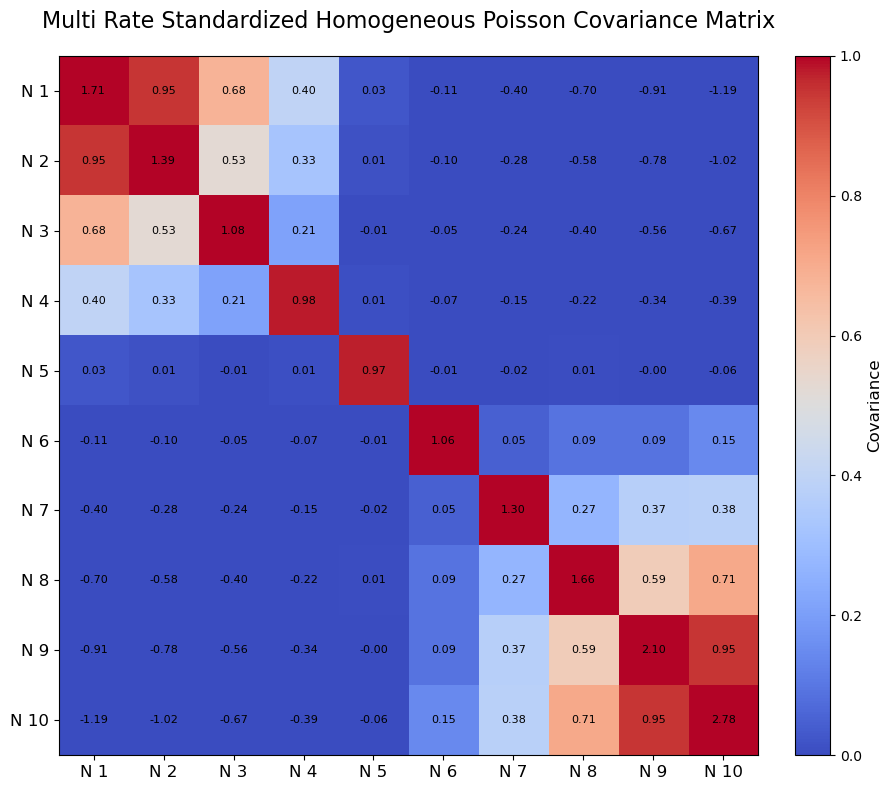

In [91]:
plot_covariance_matrix(multi_rate_cov_matrix, normalize=False, title='Multi Rate Standardized Homogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 1.72098832,  0.96976948,  0.67919397,  0.39710693,  0.02560176,
        -0.12001841, -0.41764534, -0.69842011, -0.89995881, -1.16459794],
       [ 0.96976948,  1.39985211,  0.53235398,  0.32436368,  0.01291567,
        -0.113474  , -0.29847481, -0.57661472, -0.77762782, -0.9986267 ],
       [ 0.67919397,  0.53235398,  1.07676014,  0.20679855, -0.00907522,
        -0.05881688, -0.24884589, -0.38799586, -0.54758592, -0.64386835],
       [ 0.39710693,  0.32436368,  0.20679855,  0.97455188,  0.00941259,
        -0.06792885, -0.15430066, -0.21312928, -0.32897786, -0.37310775],
       [ 0.02560176,  0.01291567, -0.00907522,  0.00941259,  0.97839315,
        -0.01063138, -0.02341645,  0.00621608, -0.00400211, -0.05748652],
       [-0.12001841, -0.113474  , -0.05881688, -0.06792885, -0.01063138,
         1.05811369,  0.05348131,  0.09505896,  0.0997009 ,  0.15340373],
       [-0.41764534, -0.29847481, -0.24884589, -0.15430066, -0.02341645,
         0.05348131,  1.31286139,  0.27673305

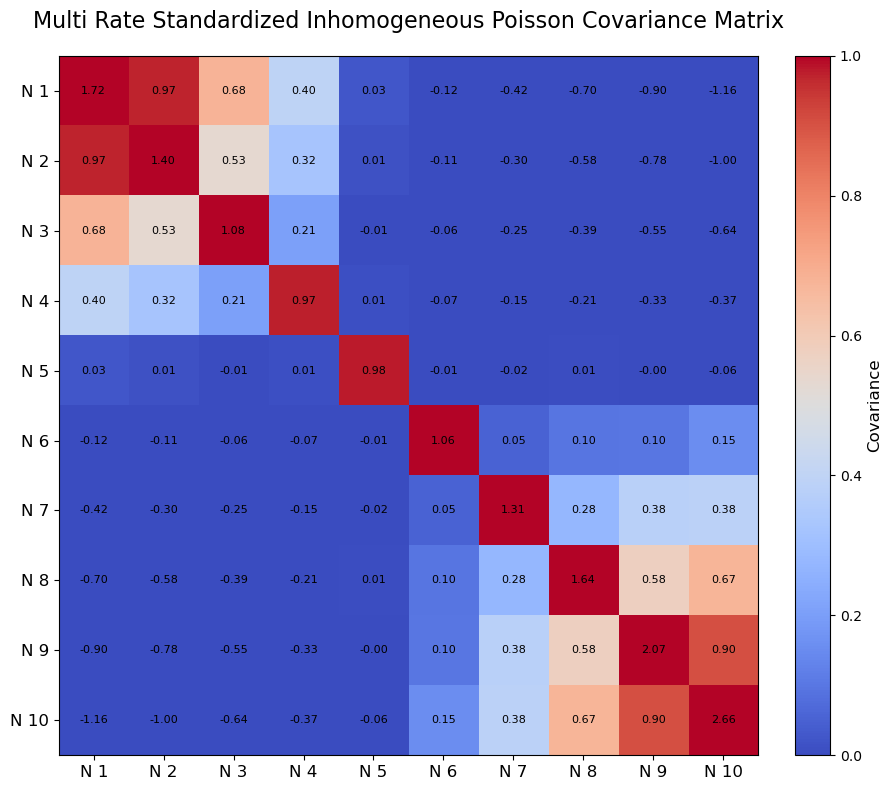

In [92]:
plot_covariance_matrix(multi_rate_cov_matrix_emp, normalize=False, title='Multi Rate Standardized Inhomogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 1.90055113e+00,  1.16457670e+00,  1.03832872e+00,
         5.57005069e-01, -4.80384051e-02,  1.30067826e-01,
        -2.62705489e-01, -6.01729279e-01, -1.14859937e+00,
        -1.33806628e+00],
       [ 1.16457670e+00,  1.49647253e+00,  8.57276663e-01,
         4.62965761e-01, -2.44610481e-02,  1.00011061e-01,
        -2.39651421e-01, -5.09943174e-01, -8.96889209e-01,
        -1.12052953e+00],
       [ 1.03832872e+00,  8.57276663e-01,  1.36594021e+00,
         3.98350242e-01, -1.06111105e-02,  1.18236411e-01,
        -1.82665543e-01, -4.56479506e-01, -8.28612231e-01,
        -9.55650709e-01],
       [ 5.57005069e-01,  4.62965761e-01,  3.98350242e-01,
         1.00314472e+00,  8.25729717e-03,  4.03445953e-02,
        -9.04891912e-02, -2.15210242e-01, -4.27700350e-01,
        -5.33674540e-01],
       [-4.80384051e-02, -2.44610481e-02, -1.06111105e-02,
         8.25729717e-03,  9.70038354e-01,  6.47766228e-03,
         8.40562626e-02,  1.66830348e-03,  8.89677851e-02,
         2.

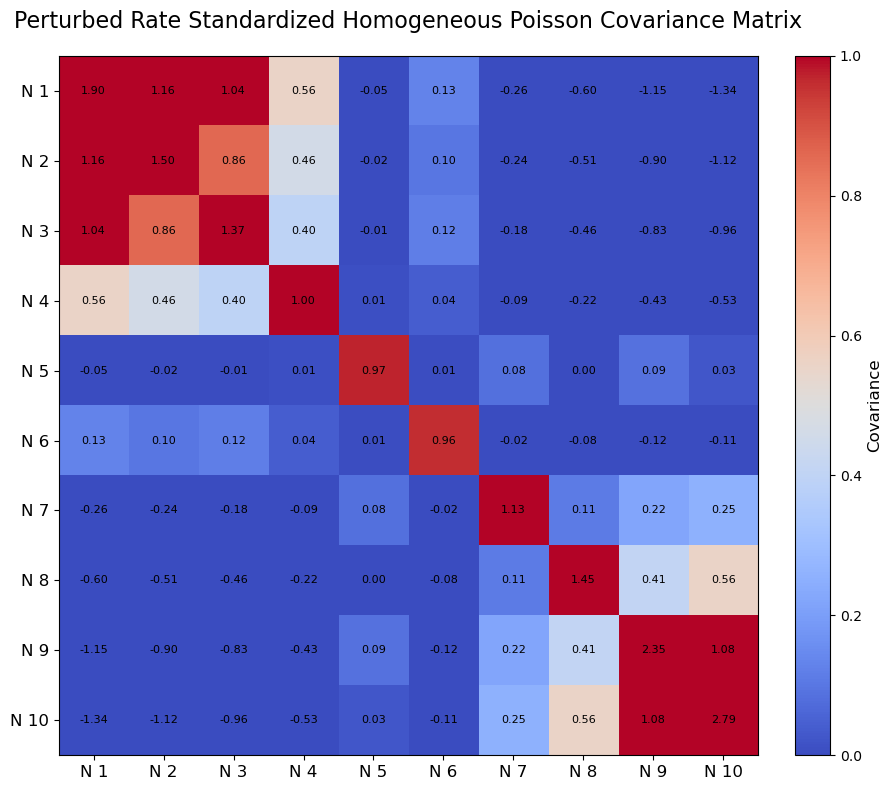

In [93]:
plot_covariance_matrix(perturbed_rate_cov_matrix, normalize=False, title='Perturbed Rate Standardized Homogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 1.91049224e+00,  1.18678416e+00,  1.04157922e+00,
         5.53842276e-01, -4.85203172e-02,  1.20781348e-01,
        -2.80603274e-01, -5.93623341e-01, -1.14095678e+00,
        -1.30394617e+00],
       [ 1.18678416e+00,  1.51423663e+00,  8.64877438e-01,
         4.63345523e-01, -2.47249792e-02,  9.28556057e-02,
        -2.55435548e-01, -5.05682333e-01, -8.96533118e-01,
        -1.09920179e+00],
       [ 1.04157922e+00,  8.64877438e-01,  1.36263992e+00,
         3.92042050e-01, -1.05034510e-02,  1.10346691e-01,
        -1.93669743e-01, -4.46211249e-01, -8.14936188e-01,
        -9.21390445e-01],
       [ 5.53842276e-01,  4.63345523e-01,  3.92042050e-01,
         9.97829070e-01,  8.86242406e-03,  3.53651469e-02,
        -9.50195474e-02, -2.07874401e-01, -4.17111441e-01,
        -5.12255107e-01],
       [-4.85203172e-02, -2.47249792e-02, -1.05034510e-02,
         8.86242406e-03,  9.74670516e-01,  6.62083345e-03,
         8.49586008e-02,  1.40948697e-03,  8.80850002e-02,
         2.

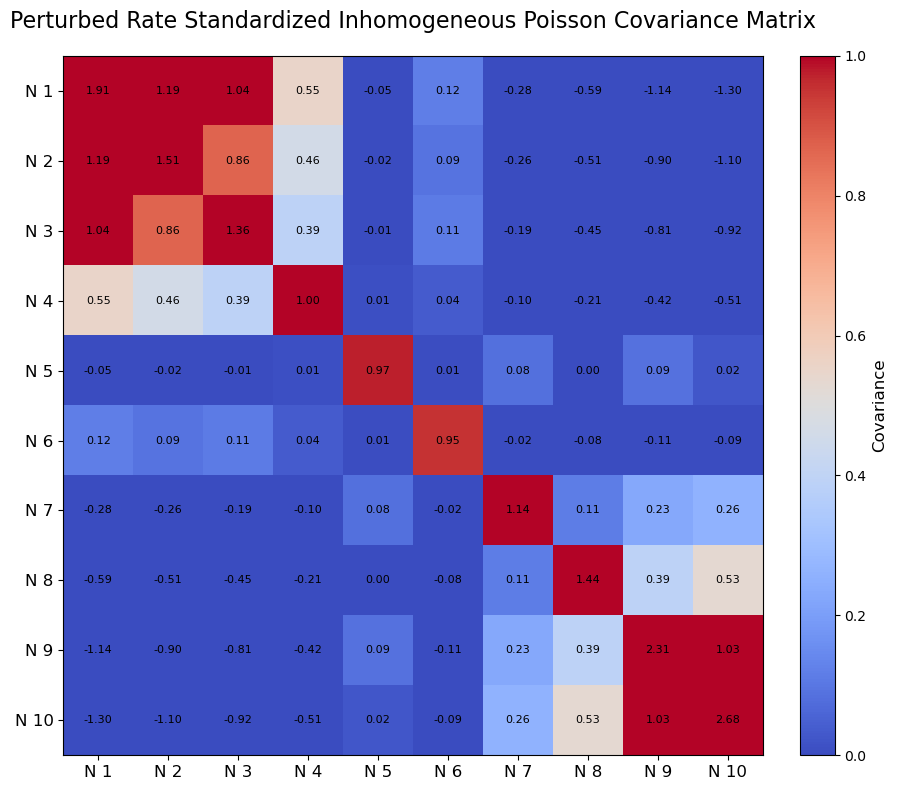

In [94]:
plot_covariance_matrix(perturbed_rate_cov_matrix_emp, normalize=False, title='Perturbed Rate Standardized Inhomogeneous Poisson Covariance Matrix', cmap='coolwarm', annot=True, neuron_labels=None)

In [95]:
#### TESTING END #####

In [96]:
#hotelling_result = hotelling_t2_test(reshaped_stands, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result)
#hotelling_result_emp = hotelling_t2_test(reshaped_stands_emp, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result_emp)

In [97]:
#good_result = stats.goodness_of_fit(stats.norm, serialized_count, statistic='ad', n_mc_samples=9999, rng=None)
# Anderson-Darling test (good for normality)
# Number of Monte Carlo samples
# Random number generator (None for fresh results)

#print(f"Statistic: {good_result.statistic}")
#print(f"P-value: {good_result.pvalue}")
#print(f"Location (mean): {good_result.fit_result.params.loc}")
#print(f"Scale (std dev): {good_result.fit_result.params.scale}")

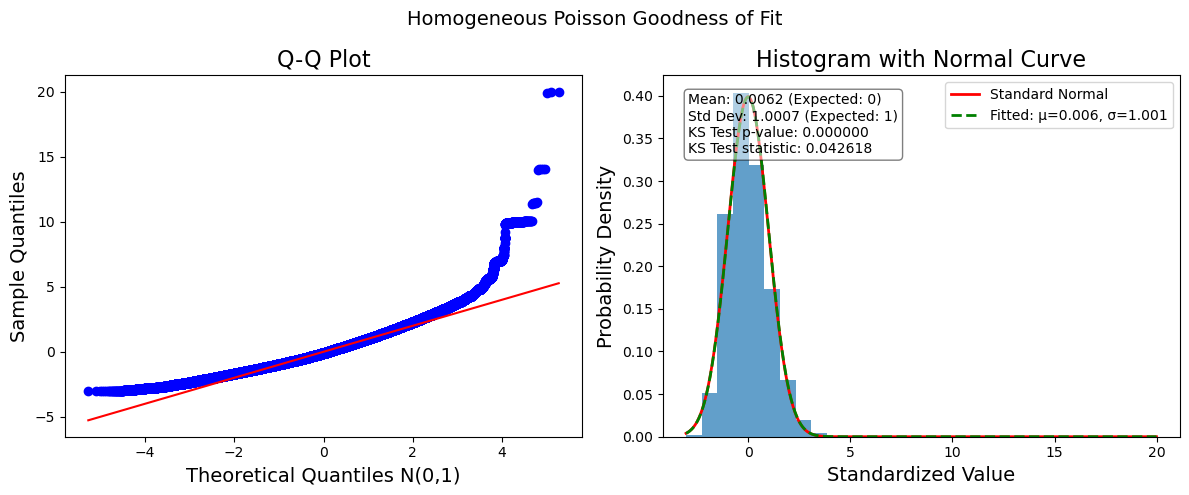

In [98]:
goodness, fig = analyze_poisson_goodness_of_fit(serialized_count, plot_title="Homogeneous Poisson Goodness of Fit", sample_limit=5000)

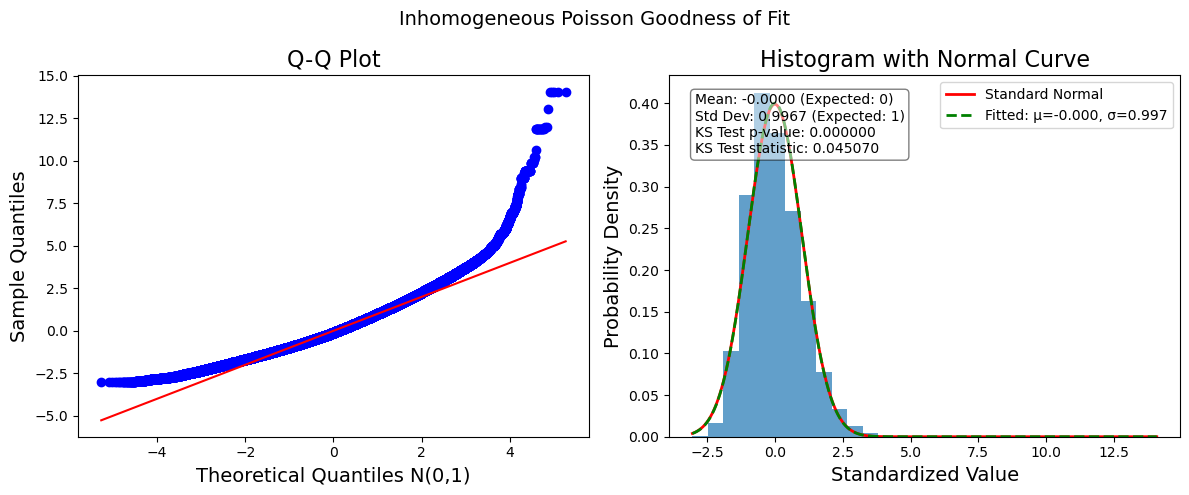

In [99]:
goodness_emp, fig_emp = analyze_poisson_goodness_of_fit(serialized_count_emp, plot_title="Inhomogeneous Poisson Goodness of Fit", sample_limit=5000)

In [100]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)
#rv = multivariate_normal(mean = [0,0], cov = cov_matrix, allow_singular = False)
#rv_emp = multivariate_normal(mean = [0,0], cov = cov_matrix_emp, allow_singular=False)
#print(rv)
#print(rv_emp)

# this is creating its own model, from this we can test if the data has goodness of fit

In [101]:
#cov_matrix, diagonal_ones = covariance_diagonal(reshaped_stands, tol=1e-8)
#print(cov_matrix)
#print(diagonal_ones)
#cov_matrix_emp, diagonal_ones_emp = covariance_diagonal(reshaped_stands_emp, tol=1e-8)
#print(cov_matrix_emp)
#print(diagonal_ones_emp)

In [102]:
#normal_loglikelihood = compute_neural_multivariate_log_likelihood(reshaped_stands)
#print(normal_loglikelihood)

#normal_loglikelihood_emp = compute_neural_multivariate_log_likelihood(reshaped_stands_emp)
#print(normal_loglikelihood_emp)

LogLikelihood experiments, Chi Square statistics, T tests, and zscores

In [104]:
total_log_likelihood, log_likelihood_per_sample = log_likelihood(empirical_mean, theoretical_means)
print(total_log_likelihood)
print(log_likelihood_per_sample)
# normalize data first (so we don't have any negative values, then we can do log likelihood)

#The neural spike patterns that are observed are unlikely to have come from the model...I got around -1600 log likelihood...

-16120.894336027779
[-1616.9076826  -1617.88513496 -1610.76629305 -1612.86480629
 -1598.61451674 -1616.35363247 -1607.39836488 -1610.41427542
 -1614.26437051 -1615.42525911]


In [105]:
perturbed_total_log_likelihood, perturbed_log_likelihood_per_sample = log_likelihood(perturbed_rate_empirical_mean, theoretical_means)
print(perturbed_total_log_likelihood)
print(perturbed_log_likelihood_per_sample)
# normalize data first (so we don't have any negative values, then we can do log likelihood)

#The neural spike patterns that are observed are unlikely to have come from the model...I got around -1600 log likelihood...

-18751.48805890837
[-2157.23007035 -1921.68532148 -1826.26901326 -1624.29608195
 -1609.52157747 -1598.84113555 -1679.16927141 -1818.53784765
 -2176.48745852 -2339.45028126]


In [106]:
test_total_log_likelihood, test_log_likelihood_per_sample = log_likelihood(theoretical_means, theoretical_means)
print(test_total_log_likelihood)
print(test_log_likelihood_per_sample)
# Note: This log likelihood has relative entropy
## Why the log likelihood per sample is different, the data is stochastic! ##
# we are doing this : log_likelihood = k*log(k) - k - log(k!) , so k = λ
#                o.g. log likelihood = k*log(λ) - λ - log(k!)
# even a perfect match is going to vary per sample because each sample is stochastic #

-16096.360338233128
[-1609.4781237  -1613.0653985  -1611.34489989 -1613.80754279
 -1600.13204454 -1616.02729793 -1609.52487934 -1608.63576316
 -1610.22568246 -1604.11870595]


In [107]:
multivar_log_likelihood, multivar_log_likelihood_per_sample, average_log_likelihood = multivariate_log_likelihood(reshaped_stands, mean = np.nan, cov = np.nan)
print(multivar_log_likelihood)
print(multivar_log_likelihood_per_sample)
print(average_log_likelihood)
len(multivar_log_likelihood_per_sample)

# note, there are 99900 samples and the total sum of those is very large.
#print(multivar_log_likelihood/len(multivar_log_likelihood_per_sample))

-14181952.590631977
[ -9.23899933  -9.28861333  -9.33822733 ... -12.57346162 -12.57405866
 -12.57475384]
-1418195.2590631978


999000

In [108]:
multivar_log_likelihood_emp, multivar_log_likelihood_per_sample_emp, average_log_likelihood_emp = multivariate_log_likelihood(reshaped_stands_emp, mean = np.nan, cov = np.nan)
print(multivar_log_likelihood_emp)
print(multivar_log_likelihood_per_sample_emp)
print(average_log_likelihood_emp)
len(multivar_log_likelihood_per_sample)

reshaped_stands_emp.shape

-14156874.645377044
[ -9.23938533  -9.29838533  -9.34738533 ... -12.56981598 -12.57431451
 -12.57554686]
-1415687.4645377044


(10, 1000000)

In [109]:
## Multivariate LogLikelihood with zero vector of len(num_neurons), aka 10) ##
multivar_log_likelihood_zero, multivar_log_likelihood_per_sample_zero, average_log_likelihood_zero = multivariate_log_likelihood(np.zeros((10, 1)), mean = np.nan, cov = np.nan)
print(multivar_log_likelihood_zero)
print(multivar_log_likelihood_per_sample_zero)
print(average_log_likelihood_zero)
len(multivar_log_likelihood_per_sample)

-9.189385332046726
-9.189385332046726
-0.9189385332046726


999000

In [110]:
# difference between multivariate log likelihood of expected - observed data.
diff = multivar_log_likelihood_emp - multivar_log_likelihood
print(diff)

print(diff/len(multivar_log_likelihood_per_sample)) # small difference per sample, less than 1.

25077.94525493309
0.025103048303236324


Chi Square

In [112]:
# Perturbed Rate standardized according to the baseline model
# perturbed_rate_stands = standardize_counts_loop(perturbed_rate_count, theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
# perturbed_rate_stands_emp = standardize_counts_loop(perturbed_rate_count, empirical_mean, empirical_std_dev, num_samples, num_neurons, perturbed_rate_global_exclude)

# Perturbed Rate standardized according to the perturbed mean and the baseline standard deviation
perturbed_rate_stands_with_self_center = standardize_counts_loop(perturbed_rate_count, perturbed_rate_theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
perturbed_rate_stands_emp_with_self_center = standardize_counts_loop(perturbed_rate_count, perturbed_rate_empirical_mean, empirical_std_dev, num_samples, num_neurons, perturbed_rate_global_exclude)

In [113]:
perturbed_rate_stands_emp_with_self_center.shape

(1000, 10, 1000)

In [114]:
# Baseline
baseline_10Hz_neuron = stands[0,0,:].flatten() / num_neurons
baseline_10Hz_neuron_emp = stands_emp[0,0,1:].flatten() / num_neurons

# Perturbed 5Hz
perturbed_5Hz_neuron = perturbed_rate_stands_with_self_center[0, 0, :].flatten() / num_neurons
perturbed_5Hz_neuron_emp = perturbed_rate_stands_emp_with_self_center[0, 0, 1:].flatten() / num_neurons

# Perturbed 15Hz
perturbed_15Hz_neuron = perturbed_rate_stands_with_self_center[0, -1, :].flatten() / num_neurons
perturbed_15Hz_neuron_emp = perturbed_rate_stands_emp_with_self_center[0, -1, 1:].flatten() / num_neurons

In [115]:
perturbed_15Hz_neuron.shape

(999,)

In [116]:
perturbed_15Hz_neuron_emp.shape

(999,)

In [117]:
# Baseline Chi Square, check please!

# chi2, p = stats.chisquare(observed, expected)
# chi2, p = stats.chisquare(baseline_resized_emp, baseline_resized,sum_check=False)
chi2, p = stats.chisquare(baseline_10Hz_neuron_emp, baseline_10Hz_neuron,sum_check=False)

#baseline_resized_normalized = baseline_resized * (baseline_resized_emp.sum() / baseline_resized.sum())
#chi2, p = stats.chisquare(baseline_resized_emp, baseline_resized_normalized)

print(chi2)
print(p)

0.1689037454643318
1.0


In [118]:
# Perturbed 5hz vs. Baseline Chi Square
# chi2, p = stats.chisquare(observed, expected)
perturbed5Hz_chi2, perturbed5Hz_p = stats.chisquare(perturbed_5Hz_neuron_emp, baseline_10Hz_neuron, sum_check=False)

print(perturbed5Hz_chi2)
print(perturbed5Hz_p)

48.65472923014735
1.0


In [119]:
# Perturbed 15hz vs.Baseline Chi Square
# chi2, p = stats.chisquare(observed, expected)
perturbed15Hz_chi2, perturbed15Hz_p = stats.chisquare(perturbed_15Hz_neuron_emp, baseline_10Hz_neuron, sum_check=False)

print(perturbed15Hz_chi2)
print(perturbed15Hz_p)

20.93334685556752
1.0


Cumulative Z test

In [121]:
# Flatten baseline model
data_flat = stands[0,0,:].flatten()/num_neurons
#data_flat = reshaped_stands.flatten()
#data_flat_emp = reshaped_stands_emp.flatten()
data_flat_emp = stands_emp[0,0,:].flatten()/num_neurons
# [trials, num_neurons, time]


# Compute cumulative Z-statistics and p-values for baseline (correct distribution)
z_stats_baseline, p_values_baseline = cumulative_z_test(data_flat, population_mean=0)
z_stats_baseline_emp, p_values_baseline_emp = cumulative_z_test(data_flat_emp, population_mean=0)

# we can choose how many neurons to use, up to n = num_neurons

In [122]:
# Flatten perturbed model
#perturbed_data_flat = perturbed_rate_reshaped_stands.flatten()
#perturbed_data_flat_emp = perturbed_rate_reshaped_stands_emp.flatten()
perturbed_data_flat = perturbed_rate_stands[0,0,:].flatten()/num_neurons
perturbed_data_flat_emp = perturbed_rate_stands_emp[0,0,:].flatten()/num_neurons

# Compute cumulative Z-statistics and p-values for perturbed (incorrect distribution)
z_stats_perturbed, p_values_perturbed = cumulative_z_test(perturbed_data_flat, population_mean=0)
z_stats_perturbed_emp, p_values_perturbed_emp = cumulative_z_test(perturbed_data_flat_emp, population_mean=0)

# we can choose how many neurons to use, up to n = num_neurons


Threshold Crossing Analysis:

Perturbed Model - Alpha Level Crossings:
  Alpha      Sample     P-value
  ----------------------------------------
  0.05       647        4.99e-02



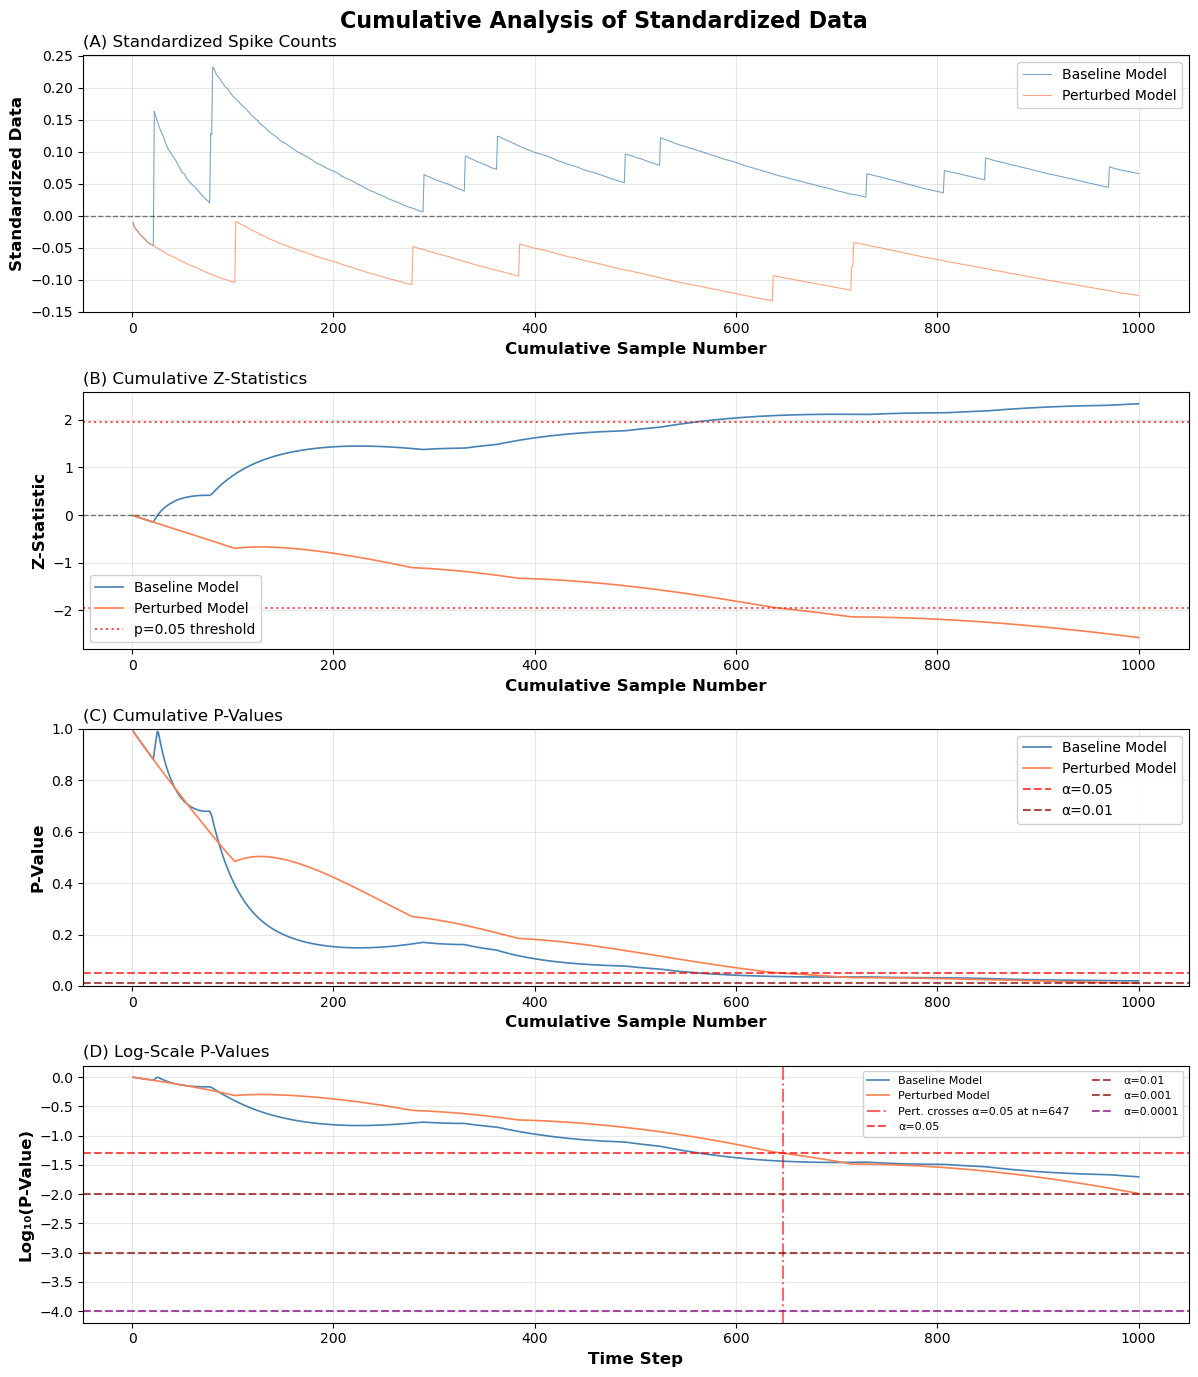

In [123]:
fig, axes, threshold_info = plot_cumulative_analysis(data_flat=data_flat_emp,z_stats_baseline=z_stats_baseline_emp,p_values_baseline=p_values_baseline_emp,data_flat_pert=perturbed_data_flat_emp,z_stats_pert=z_stats_perturbed_emp,p_values_pert=p_values_perturbed_emp,title='Cumulative Analysis of Standardized Data',baseline_label='Baseline Model',perturbed_label='Perturbed Model',threshold=1e-4,save_path=None)
plt.show()

In [124]:
threshold_info

{'alpha_crossings': {0.05: {'sample': np.int64(647),
   'p_value': np.float64(0.0498725841602014)}}}

Theoretical and Empirical stats of excitatory counts.

In [126]:
# empirical_mean_ex = empirical_means(count_ex)
empirical_mean_ex = count_ex.mean(axis=0)
#print(empirical_mean_ex)
#print(empirical_mean_ex.shape)
count_rate_ex = empirical_mean_ex[:, -1]

# empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
#empirical_std_dev_ex = count_ex.std(axis=0, ddof=1)
empirical_std_dev_ex = np.sqrt(empirical_mean_ex)
#print(empirical_std_dev_ex)
#print(empirical_std_dev_ex.shape)

empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)
# print(empirical_lower_bound_sim_ex)
# print(empirical_upper_bound_sim_ex)

In [127]:
exclude_times_ex, global_exclude_ex = last_zero_std_time(empirical_std_dev_ex, verbose=True)

Neuron 0: last zero std at t=-1, recommended exclude=0
Neuron 1: last zero std at t=-1, recommended exclude=0
Neuron 2: last zero std at t=-1, recommended exclude=0
Neuron 3: last zero std at t=-1, recommended exclude=0
Neuron 4: last zero std at t=-1, recommended exclude=0
Neuron 5: last zero std at t=-1, recommended exclude=0
Neuron 6: last zero std at t=-1, recommended exclude=0
Neuron 7: last zero std at t=-1, recommended exclude=0
Neuron 8: last zero std at t=-1, recommended exclude=0
Neuron 9: last zero std at t=-1, recommended exclude=0

Global exclude (safest): t=0


In [128]:
theoretical_means_sim_ex = calculate_theoretical_mean(count_rate_ex, time)
#print(theoretical_means_sim_ex)
#print(theoretical_means_sim_ex.shape)

theoretical_std_dev_sim_ex = calculate_theoretical_std_dev(theoretical_means_sim_ex)
#print(theoretical_std_dev_sim_ex)
#print(theoretical_std_dev_sim_ex.shape)

theoretical_lower_bound_sim_ex, theoretical_upper_bound_sim_ex = confidence_intervals(theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound_sim_ex)
# print(theoretical_upper_bound_sim_ex)

In [129]:
res_var_ex = variance_of_residuals(empirical_mean_ex, theoretical_means_sim_ex)
#print(res_var_ex)

In [130]:
stands_ex = standardize_counts_loop(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, num_neurons, exclude = 1)
#print(stands_ex)
#print(stands_ex.shape)

stands_ex_emp = standardize_counts_loop(count_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples, num_neurons, global_exclude_ex)
#print(stands_ex_emp)
#print(stands_ex_emp.shape)

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

standardized_mean_global_ex = np.mean(stands_ex)
standardized_std_global_ex = np.std(stands_ex)

standardized_mean_emp_global_ex = np.mean(stands_ex_emp)
standardized_std_emp_global_ex = np.std(stands_ex_emp)

standardized_mean_ex = np.mean(stands_ex, axis=0)
standardized_std_ex = np.std(stands_ex, axis=0, ddof = 1)

standardized_mean_ex_emp = np.mean(stands_ex_emp, axis = 0)
standardized_std_ex_emp = np.std(stands_ex_emp, axis = 0, ddof = 1)

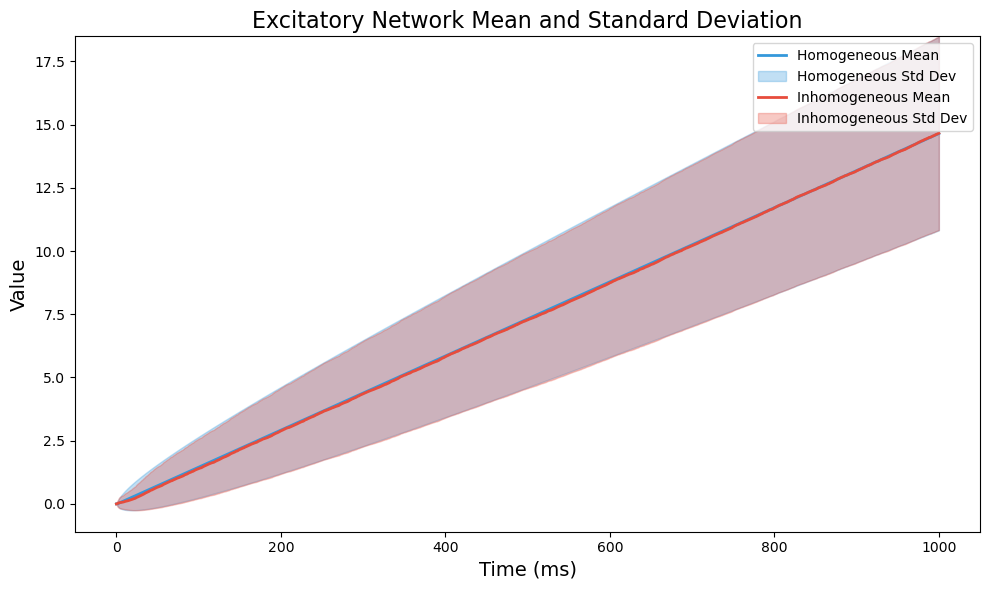

In [131]:
plot_stats(theoretical_means_sim_ex, empirical_mean_ex, theoretical_std_dev_sim_ex, empirical_std_dev_ex, title = 'Excitatory Network Mean and Standard Deviation', show_hline=False, data_type='standardized')

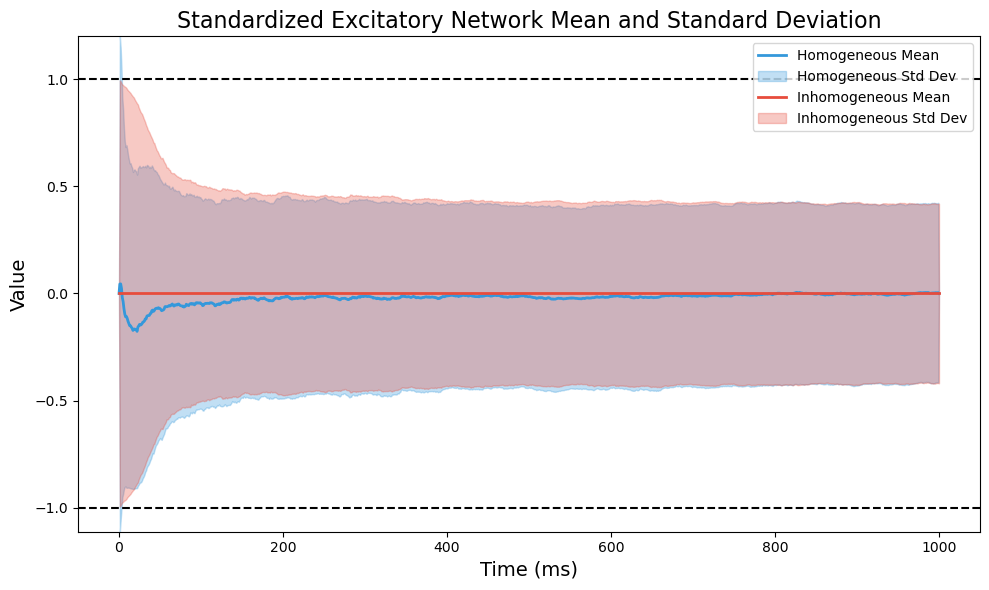

In [132]:
plot_stats(standardized_mean_ex, standardized_mean_ex_emp, standardized_std_ex, standardized_std_ex_emp, title = 'Standardized Excitatory Network Mean and Standard Deviation', show_hline=True, data_type='standardized')

In [133]:
mean_check_ex = check_mean_with_se(stands_ex, expected_mean=0, confidence=0.95)
#print(mean_check_ex)

mean_check_ex_emp = check_mean_with_se(stands_ex_emp, expected_mean=0, confidence=0.95)
#print(mean_check_ex_emp)

In [134]:
serialized_count_ex = serialize_counts(stands_ex) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_ex.shape)
#print(np.mean(serialized_count_ex))
t_stat_ex, p_val_mean_ex = stats.ttest_1samp(serialized_count_ex, np.mean(serialized_count_ex))
#print(t_stat_ex)
#print(p_val_mean_ex)

    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables

serialized_count_ex_emp = serialize_counts(stands_ex_emp) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_ex_emp.shape)
#print(np.mean(serialized_count_ex_emp))
t_stat_ex_emp, p_val_mean_ex_emp = stats.ttest_1samp(serialized_count_ex_emp, np.mean(serialized_count_ex_emp))
#print(t_stat_ex_emp)
#print(p_val_mean_ex_emp)

In [135]:
#reshaped_stands_ex = np.reshape(stands_ex, (-1, stands_ex.shape[1]), order='F')
reshaped_stands_ex = np.transpose(stands_ex, (1, 0, 2)).reshape(stands_ex.shape[1], -1)
#print(stands_ex.shape)
#print(reshaped_stands_ex.shape)

#could change the values from num_samples, num_neurons, time to 10 by large number, could transpose it
# make sure coviariance matrix is using row data, don't use np.cov because it throws away the mean
# covariance is the data and the transpose of the data divided sqrt(n-1), lookup how covariance is calculated and make it by hand.
# try to iterate over samples, as in each time point, 

# reshaped_stands_ex_emp = np.reshape(stands_ex_emp, (-1, stands_ex_emp.shape[1]), order='F')
reshaped_stands_ex_emp = np.transpose(stands_ex_emp, (1, 0, 2)).reshape(stands_ex_emp.shape[1], -1)
#print(stands_ex_emp.shape)
#print(stands_ex.shape)
#print(reshaped_stands_ex.shape)
#print(stands_ex[:,:,0])
#print(reshaped_stands[:,0])
#print(stands_ex_emp[:,:,0].shape)
#print(stands_ex_emp[:10,:,0])
#print(reshaped_stands_ex_emp.shape)
#print(reshaped_stands_ex_emp[:10,:])

In [136]:
transpose_stands_ex = np.transpose(stands_ex, (1, 0, 2))
#print(transpose_stands_ex[:,:,0:3])

In [137]:
#print(reshaped_stands_ex[:,:5])

In [138]:
#print("Time point 0:", stands_ex[:,:,0])
#print("Time point 1:", stands_ex[:,:,1])
#print("Time point 100:", stands_ex[:,:,100])

In [139]:
cov_matrix_ex = cov_standardized_data(reshaped_stands_ex)
cov_matrix_ex_emp = cov_standardized_data(reshaped_stands_ex_emp)

array([[ 2.15165151e-01,  2.67285555e-03, -5.45267514e-04,
        -1.91472948e-03,  4.26182469e-03, -4.51940685e-03,
         9.79574319e-03, -1.13661703e-03,  3.89338643e-03,
         2.45950852e-03],
       [ 2.67285555e-03,  9.78150531e-02,  2.56533489e-03,
         3.42391841e-04,  1.20974248e-03, -2.74216201e-03,
         3.29363983e-03,  5.27164758e-03,  7.80931329e-03,
         3.01526956e-03],
       [-5.45267514e-04,  2.56533489e-03,  4.36320787e-01,
         3.51032857e-03,  1.25735873e-03,  1.50357449e-02,
         1.56988303e-02,  4.89834595e-04,  5.08478999e-03,
         4.15505925e-03],
       [-1.91472948e-03,  3.42391841e-04,  3.51032857e-03,
         1.89993185e-01,  2.16334766e-03,  3.11887877e-03,
         4.53474896e-03,  8.42184944e-04,  1.60260853e-03,
         5.12610045e-03],
       [ 4.26182469e-03,  1.20974248e-03,  1.25735873e-03,
         2.16334766e-03,  1.60413193e-01,  5.32364455e-03,
         6.49327059e-03,  3.20918104e-03,  1.62718590e-03,
         5.

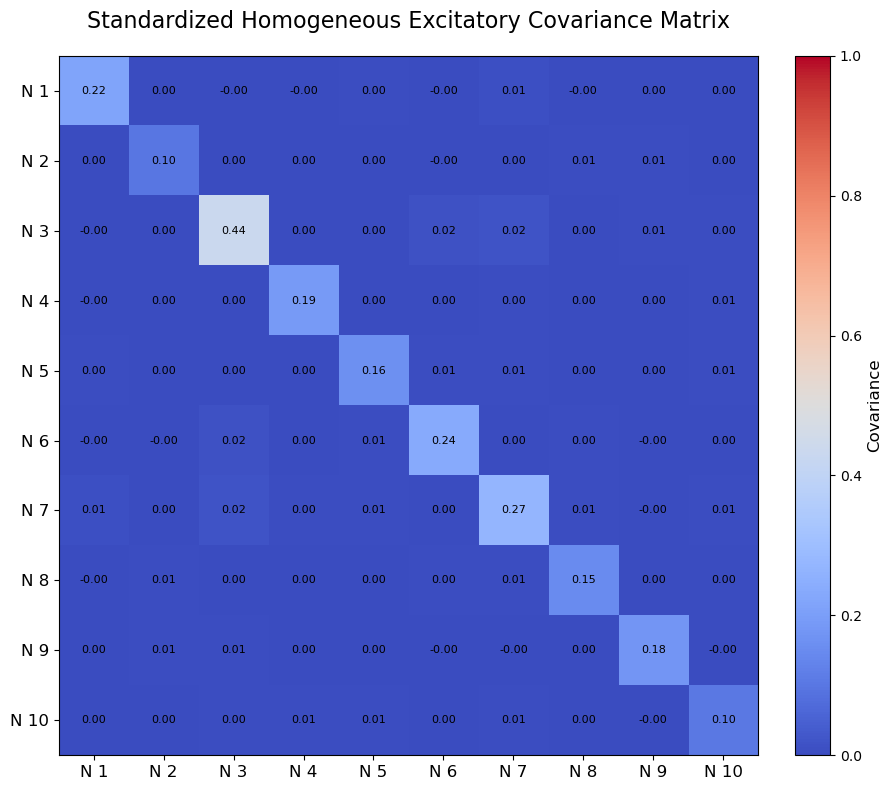

In [140]:
plot_covariance_matrix(cov_matrix_ex, normalize=False, title="Standardized Homogeneous Excitatory Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 2.23590383e-01,  1.36468949e-03, -5.63804785e-04,
        -3.28951823e-03,  2.92020248e-03, -5.63247031e-03,
         8.87911749e-03, -2.63469811e-03,  2.70636593e-03,
         6.53374177e-04],
       [ 1.36468949e-03,  1.06227823e-01,  2.63217123e-03,
        -1.25566373e-03, -1.04581955e-03, -3.98844838e-03,
         2.18128777e-03,  3.58738311e-03,  6.62277373e-03,
         8.77035808e-04],
       [-5.63804785e-04,  2.63217123e-03,  4.30907790e-01,
         3.51030293e-03,  1.24583636e-03,  1.52086059e-02,
         1.61277359e-02,  3.91099360e-04,  5.12801230e-03,
         4.07933022e-03],
       [-3.28951823e-03, -1.25566373e-03,  3.51030293e-03,
         1.97948611e-01,  2.94488756e-04,  2.21258185e-03,
         3.32334219e-03, -3.96708352e-04,  1.87151762e-04,
         3.33840959e-03],
       [ 2.92020248e-03, -1.04581955e-03,  1.24583636e-03,
         2.94488756e-04,  1.71255814e-01,  3.80934540e-03,
         4.82876802e-03,  1.41784564e-03, -4.11434123e-04,
         2.

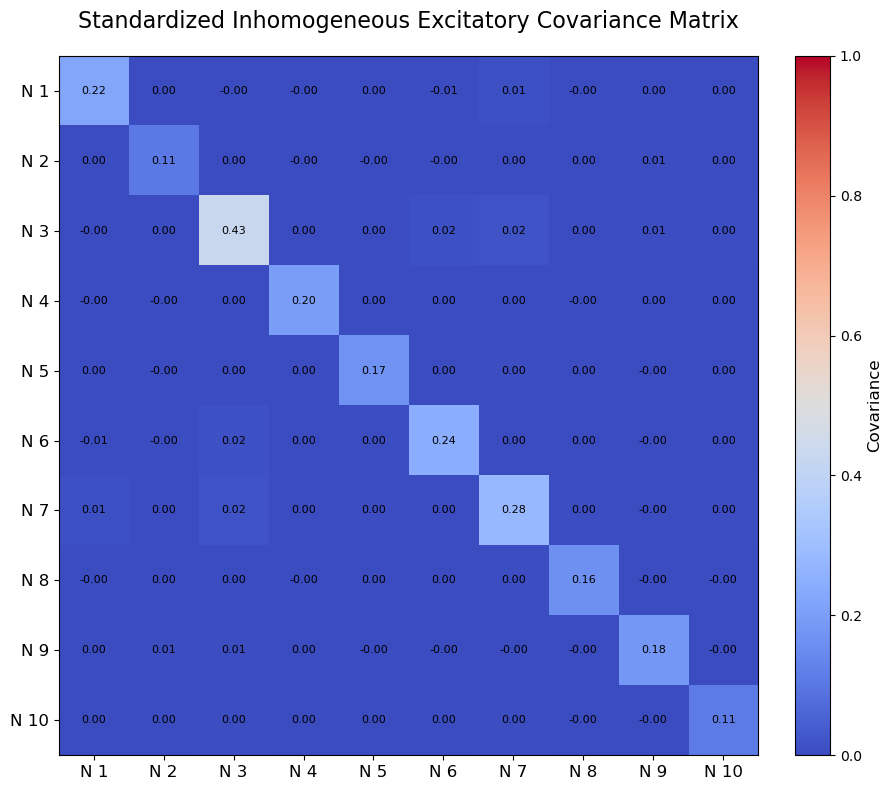

In [141]:
plot_covariance_matrix(cov_matrix_ex_emp, normalize=False, title="Standardized Inhomogeneous Excitatory Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=None)

In [142]:
#hotelling_result_ex = hotelling_t2_test(reshaped_stands_ex, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result_ex)
#hotelling_result_ex_emp = hotelling_t2_test(reshaped_stands_ex_emp, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result_ex_emp)

In [143]:
#cov_matrix_ex, diagonal_ones_ex = covariance_diagonal(reshaped_stands_ex, tol=1e-8)
#print(cov_matrix_ex)
#print(diagonal_ones_ex)
#cov_matrix_ex_emp, diagonal_ones_ex_emp = covariance_diagonal(reshaped_stands_ex_emp, tol=1e-8)
#print(cov_matrix_ex_emp)
#print(diagonal_ones_ex_emp)

In [144]:
#### TESTING #####
#plot_covariance_matrix(reshaped_data, normalize=False, title="Excitatory Theoretical Covariance Matrix", cmap='coolwarm', annot=True)

In [145]:
#### TESTING ####
#plot_covariance_matrix(reshaped_data_emp, normalize=False, title="Excitatory Empirical Covariance Matrix", cmap='coolwarm', annot=True)

In [146]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)

# rv_ex = multivariate_normal(mean = theoretical_means_sim_ex, cov = cov_matrix_ex, allow_singular=allow_singular)
# rv_ex_emp = multivariate_normal(mean = empirical_mean_ex, cov = cov_matrix_ex_emp, allow_singular=allow_singular)

# this is creating its own model, from this we can test if the data has goodness of fit

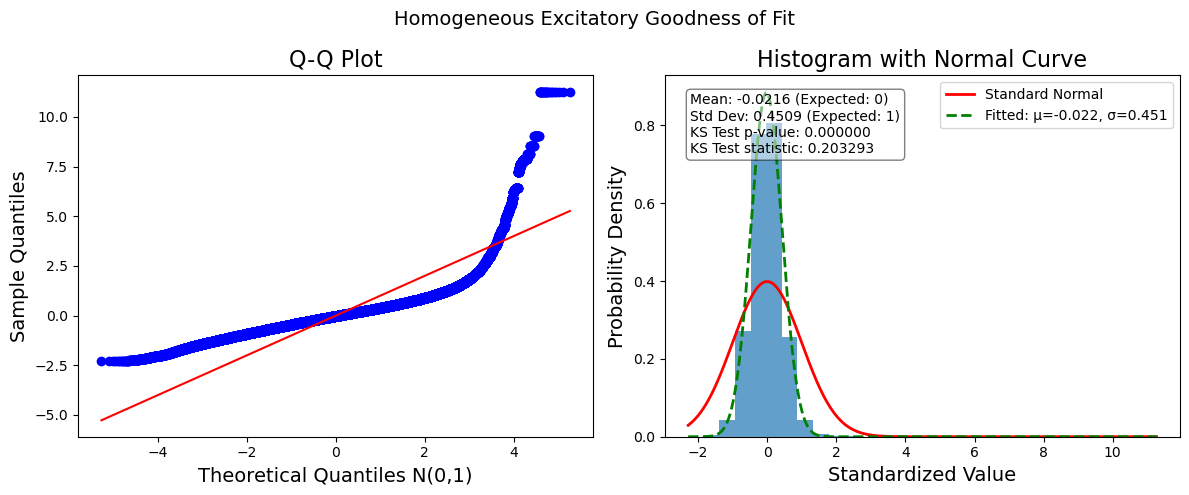

In [147]:
goodness_ex, fig_ex = analyze_poisson_goodness_of_fit(serialized_count_ex, plot_title="Homogeneous Excitatory Goodness of Fit", sample_limit=5000)

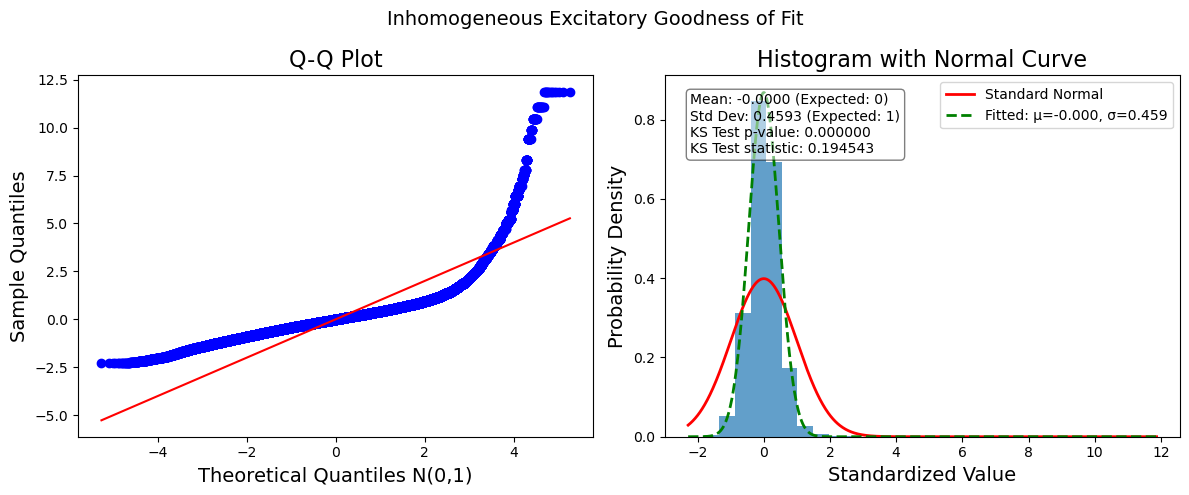

In [148]:
goodness_ex_emp, fig_ex_emp = analyze_poisson_goodness_of_fit(serialized_count_ex_emp, plot_title="Inhomogeneous Excitatory Goodness of Fit", sample_limit=5000)

Theoretical and Empirical stats of inhibitory counts.

In [150]:
# empirical_mean_in = empirical_means(count_in)
empirical_mean_in = count_in.mean(axis=0)
#print(empirical_mean_in)
#print(empirical_mean_in.shape)
count_rate_in = empirical_mean_in[:, -1]

#empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
#empirical_std_dev_in = count_in.std(axis=0, ddof=1)
empirical_std_dev_in = np.sqrt(empirical_mean_in)
#print(empirical_std_dev_in)
#print(empirical_std_dev_in.shape)

empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)
# print(empirical_lower_bound_sim_in)
# print(empirical_upper_bound_sim_in)

In [151]:
exclude_times_in, global_exclude_in = last_zero_std_time(empirical_std_dev_in, verbose=True)

Neuron 0: last zero std at t=-1, recommended exclude=0
Neuron 1: last zero std at t=-1, recommended exclude=0
Neuron 2: last zero std at t=-1, recommended exclude=0
Neuron 3: last zero std at t=-1, recommended exclude=0
Neuron 4: last zero std at t=-1, recommended exclude=0
Neuron 5: last zero std at t=-1, recommended exclude=0
Neuron 6: last zero std at t=-1, recommended exclude=0
Neuron 7: last zero std at t=-1, recommended exclude=0
Neuron 8: last zero std at t=-1, recommended exclude=0
Neuron 9: last zero std at t=-1, recommended exclude=0

Global exclude (safest): t=0


In [152]:
theoretical_means_sim_in = calculate_theoretical_mean(count_rate_in, time)
#print(theoretical_means_sim_in)
#print(theoretical_means_sim_in.shape)

theoretical_std_dev_sim_in = calculate_theoretical_std_dev(theoretical_means_sim_in)
#print(theoretical_std_dev_sim_in)
#print(theoretical_std_dev_sim_in.shape)

theoretical_lower_bound_sim_in, theoretical_upper_bound_sim_in = confidence_intervals(theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound_sim_in)
# print(theoretical_upper_bound_sim_in)

In [153]:
res_var_in = variance_of_residuals(empirical_mean_in, theoretical_means_sim_in)
#print(res_var_in)

In [154]:
stands_in = standardize_counts_loop(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, num_neurons, exclude = 1)
#print(stands_in)
#print(stands_in.shape)

stands_in_emp = standardize_counts_loop(count_in, empirical_mean_in, empirical_std_dev_in, num_samples, num_neurons, global_exclude_in)
#print(stands_in_emp)
#print(stands_in_emp.shape)

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

standardized_mean_global_in = np.mean(stands_in)
standardized_std_global_in = np.std(stands_in)

standardized_mean_emp_global_in = np.mean(stands_in_emp)
standardized_std_emp_global_in = np.std(stands_in_emp)

standardized_mean_in = np.mean(stands_in, axis=0)
standardized_std_in = np.std(stands_in, axis=0, ddof = 1)

standardized_mean_in_emp = np.mean(stands_in_emp, axis = 0)
standardized_std_in_emp = np.std(stands_in_emp, axis = 0, ddof = 1)

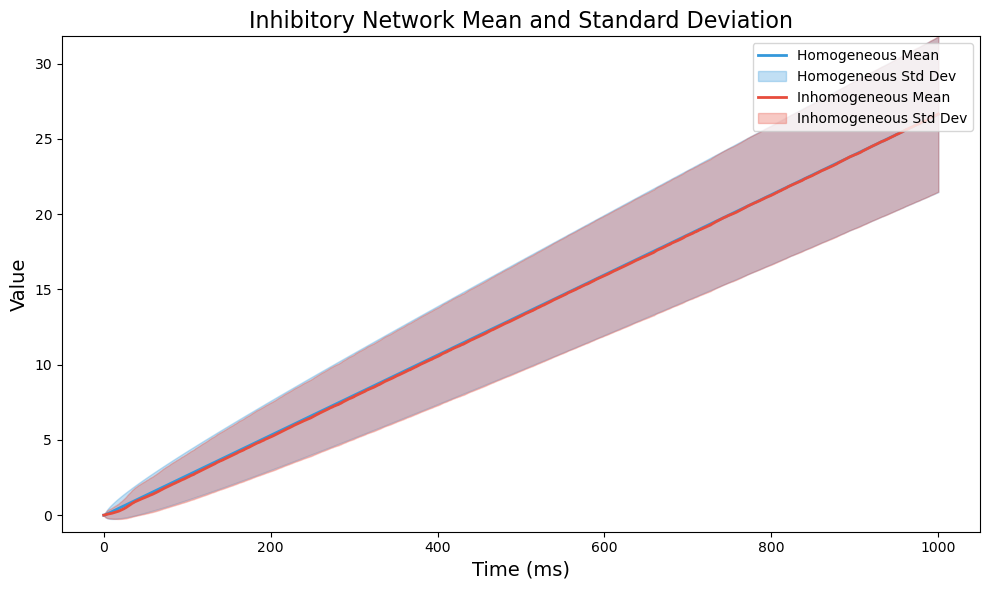

In [155]:
plot_stats(theoretical_means_sim_in , empirical_mean_in, theoretical_std_dev_sim_in, empirical_std_dev_in, title = 'Inhibitory Network Mean and Standard Deviation', show_hline=False, data_type='standardized')

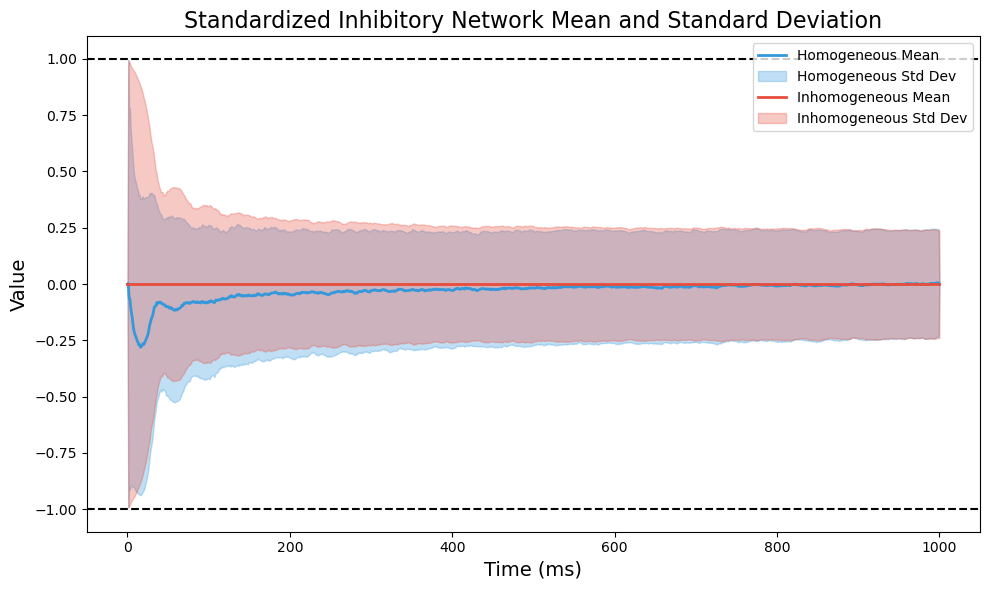

In [156]:
plot_stats(standardized_mean_in, standardized_mean_in_emp, standardized_std_in, standardized_std_in_emp, title = 'Standardized Inhibitory Network Mean and Standard Deviation', show_hline=True, data_type='standardized')

In [157]:
mean_check_in = check_mean_with_se(stands_in, expected_mean=0, confidence=0.95)
#print(mean_check_in)

mean_check_in_emp = check_mean_with_se(stands_in_emp, expected_mean=0, confidence=0.95)
#print(mean_check_in_emp)

In [158]:
serialized_count_in = serialize_counts(stands_in) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_in.shape)
#print(np.mean(serialized_count_in))
t_stat_in, p_val_mean_in = stats.ttest_1samp(serialized_count_in, np.mean(serialized_count_in))
#print(t_stat_in)
#print(p_val_mean_in)
    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables


serialized_count_in_emp = serialize_counts(stands_in_emp) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_in_emp.shape)
#print(np.mean(serialized_count_in_emp))
t_stat_in_emp, p_val_mean_in_emp = stats.ttest_1samp(serialized_count_in_emp, np.mean(serialized_count_in_emp))
#print(t_stat_in_emp)
#print(p_val_mean_in_emp)

In [159]:
#reshaped_stands_in = np.reshape(stands_in, (-1, stands_in.shape[1]), order='F')
reshaped_stands_in = np.transpose(stands_in, (1, 0, 2)).reshape(stands_in.shape[1], -1)
#print(stands_in.shape)
#print(reshaped_stands_in.shape)

#reshaped_stands_in_emp = np.reshape(stands_in_emp, (-1, stands_in_emp.shape[1]), order='F')
reshaped_stands_in_emp = np.transpose(stands_in_emp, (1, 0, 2)).reshape(stands_in_emp.shape[1], -1)
#print(stands_in_emp.shape)
#print(reshaped_stands_in_emp.shape)

In [160]:
cov_matrix_in = cov_standardized_data(reshaped_stands_in)
cov_matrix_in_emp = cov_standardized_data(reshaped_stands_in_emp)

array([[ 8.74216085e-02, -7.22096877e-04, -3.81372809e-03,
         1.42056652e-03,  2.55032801e-03,  1.30390811e-03,
         2.65052902e-03, -1.01360807e-03,  2.45639226e-03,
         5.00519695e-03],
       [-7.22096877e-04,  1.39216353e-01,  3.51522081e-03,
         5.99256011e-04,  6.30742320e-04,  1.99832027e-03,
         4.82487002e-03,  3.76566151e-03, -8.24195675e-04,
         1.51679557e-03],
       [-3.81372809e-03,  3.51522081e-03,  2.87741936e-01,
        -7.95808519e-05,  8.05159303e-03,  1.31025421e-03,
         1.94868212e-03, -2.55506711e-03,  1.75236902e-03,
        -2.04398916e-03],
       [ 1.42056652e-03,  5.99256011e-04, -7.95808519e-05,
         1.34889114e-01,  1.15047125e-03,  9.36657394e-04,
         2.56810039e-03,  5.37449263e-03, -9.86601131e-04,
         5.87161392e-03],
       [ 2.55032801e-03,  6.30742320e-04,  8.05159303e-03,
         1.15047125e-03,  1.90176920e-01, -1.74231449e-03,
         3.23479861e-03,  5.87063684e-03, -1.48242809e-03,
         9.

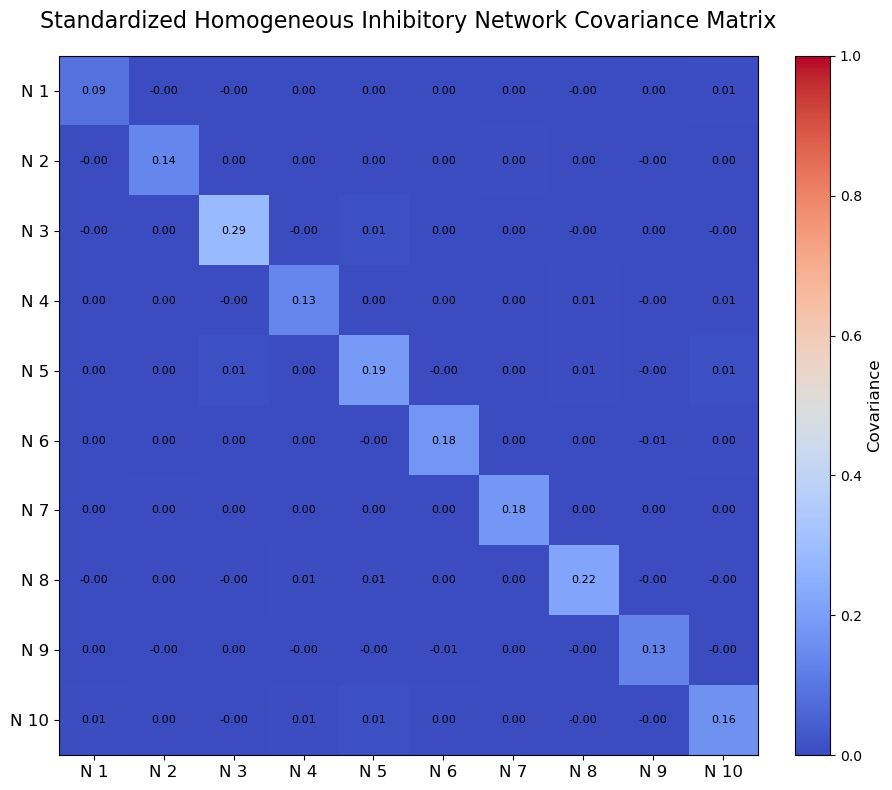

In [161]:
plot_covariance_matrix(cov_matrix_in, normalize=False, title="Standardized Homogeneous Inhibitory Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=None)

array([[ 9.46436064e-02, -2.99397125e-03, -5.03932521e-03,
        -3.29208676e-04,  8.00683354e-04, -7.38022444e-04,
         7.64721791e-04, -2.52813063e-03,  1.90036993e-04,
         3.15521390e-03],
       [-2.99397125e-03,  1.47613676e-01,  2.42509572e-03,
        -1.01234055e-03, -9.74617035e-04,  1.80678667e-04,
         3.44933762e-03,  2.73271585e-03, -2.79591225e-03,
        -2.24502449e-04],
       [-5.03932521e-03,  2.42509572e-03,  2.92954005e-01,
        -1.00620223e-03,  6.99908772e-03,  1.08145274e-04,
         1.00133444e-03, -3.41886730e-03,  8.89269808e-04,
        -3.28647249e-03],
       [-3.29208676e-04, -1.01234055e-03, -1.00620223e-03,
         1.42503173e-01, -4.38701906e-04, -5.94161788e-04,
         9.07999910e-04,  4.53656434e-03, -2.42821673e-03,
         4.41237706e-03],
       [ 8.00683354e-04, -9.74617035e-04,  6.99908772e-03,
        -4.38701906e-04,  1.98947543e-01, -3.66528374e-03,
         1.74705291e-03,  5.10993263e-03, -3.14071018e-03,
         8.

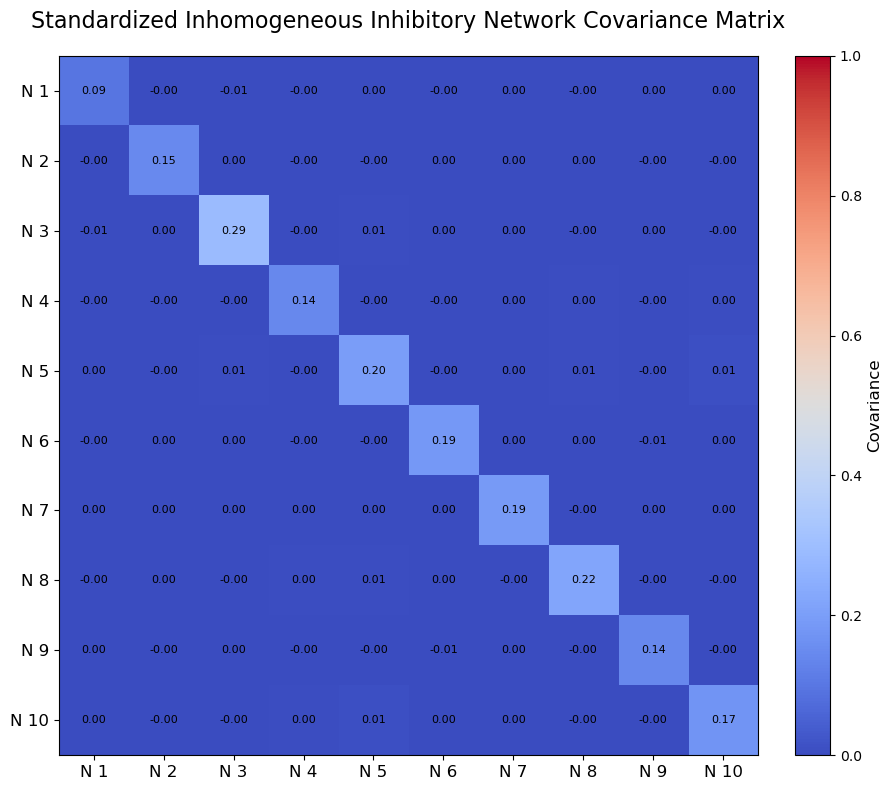

In [162]:
plot_covariance_matrix(cov_matrix_in_emp, normalize=False, title="Standardized Inhomogeneous Inhibitory Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=None)

In [163]:
#hotelling_result_in = hotelling_t2_test(reshaped_stands_in, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result_in)
#hotelling_result_in_emp = hotelling_t2_test(reshaped_stands_in_emp, np.arange(num_neurons), bessel=True, S=None)
#print(hotelling_result_in_emp)

In [164]:
#cov_matrix_in, diagonal_ones_in = covariance_diagonal(reshaped_stands_in, tol=1e-8)
#print(cov_matrix_in)
#print(diagonal_ones_in)
#cov_matrix_in_emp, diagonal_ones_in_emp = covariance_diagonal(reshaped_stands_in_emp, tol=1e-8)
#print(cov_matrix_in_emp)
#print(diagonal_ones_in_emp)

In [165]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)

# rv_in = multivariate_normal(mean = theoretical_means_sim_in, cov = cov_matrix_in, allow_singular=allow_singular)
# rv_in_emp = multivariate_normal(mean = empirical_mean_in, cov = cov_matrix_in_emp, allow_singular=allow_singular)

# this is creating its own model, from this we can test if the data has goodness of fit

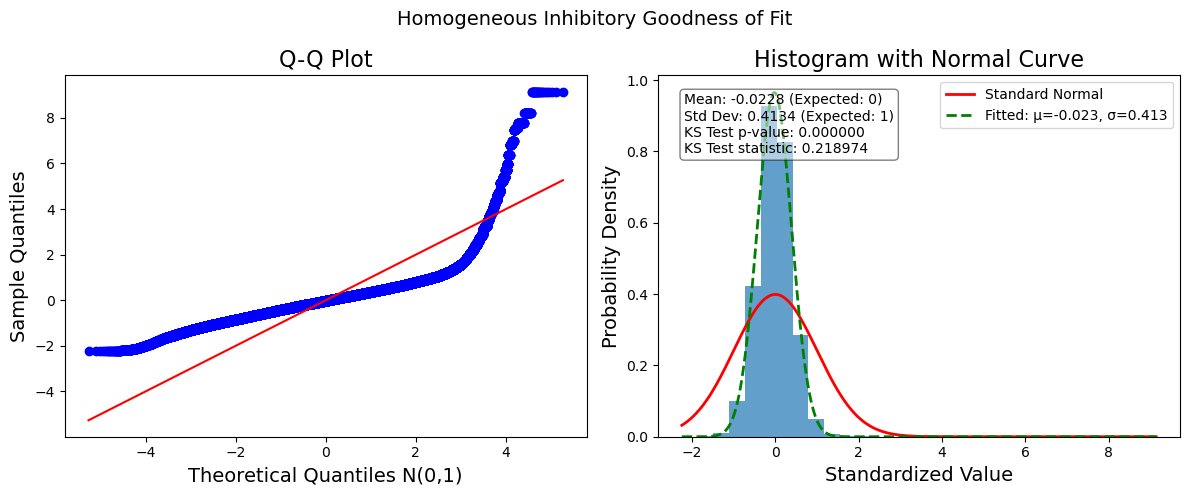

In [166]:
goodness_in, fig_in = analyze_poisson_goodness_of_fit(serialized_count_in, plot_title="Homogeneous Inhibitory Goodness of Fit", sample_limit=5000)

In [ ]:
goodness_in_emp, fig_in_emp = analyze_poisson_goodness_of_fit(serialized_count_in_emp, plot_title="Inhomogeneous Inhibitory Goodness of Fit", sample_limit=5000)

Balanced Excitatory and Inhibitory Experiments

In [ ]:
# Original excitatory and inhibitory data shapes
print(reshaped_stands_ex.shape)
print(reshaped_stands_in.shape)

print(reshaped_stands_ex_emp.shape)
print(reshaped_stands_in_emp.shape)

In [ ]:
balanced_data, labels, types = create_balanced_ei_dataset(reshaped_stands_ex, reshaped_stands_in, n_neurons_each=5)
print(f"\nBalanced dataset shape: {balanced_data.shape}")
print(f"Neuron labels: {labels}")
print(f"Neuron types: {types}")

balanced_data_emp, labels_emp, types_emp = create_balanced_ei_dataset(reshaped_stands_ex_emp, reshaped_stands_in_emp, n_neurons_each=5)
print(f"\nBalanced Empirical dataset shape: {balanced_data_emp.shape}")
print(f"Neuron Empirical labels: {labels_emp}")
print(f"Neuron Empirical types: {types_emp}")
# Balanced = Joint, don't use balance because it could be interpreted as something it isn't
# add option to randomize joint excitatory and inhibitory neurons
# Get neuron id from spike train instead of label

In [ ]:
cov_matrix_balance = cov_standardized_data(balanced_data)
cov_matrix_balance_emp = cov_standardized_data(balanced_data_emp)

In [ ]:
plot_covariance_matrix(cov_matrix_balance, normalize=False, title="Standardized Homogeneous Joint Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=labels)

In [ ]:
plot_covariance_matrix(cov_matrix_balance_emp, normalize=False, title="Standardized Inhomogeneous Joint Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=labels_emp)

In [ ]:
#interleaved_data, int_labels, int_types = create_interleaved_ei_dataset(reshaped_stands_ex, reshaped_stands_in, n_neurons_each=5)
#print(f"\nInterleaved dataset shape: {interleaved_data.shape}")
#print(f"Neuron labels: {int_labels}")
#print(f"Neuron types: {int_types}")

#interleaved_data_emp, int_labels_emp, int_types_emp = create_interleaved_ei_dataset(reshaped_stands_ex_emp, reshaped_stands_in_emp, n_neurons_each=5)
#print(f"\nInterleaved Empirical dataset shape: {interleaved_data_emp.shape}")
#print(f"Neuron Empirical labels: {int_labels_emp}")
#print(f"Neuron Empirical types: {int_types_emp}")

In [ ]:
#cov_matrix_interleaved = cov_standardized_data(interleaved_data)
#cov_matrix_interleaved_emp = cov_standardized_data(interleaved_data_emp)

In [ ]:
#plot_covariance_matrix(cov_matrix_interleaved, normalize=False, title="Standardized Homogeneous Interleaved Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=int_labels)

In [ ]:
#plot_covariance_matrix(cov_matrix_interleaved_emp, normalize=False, title="Standardized Inhomogeneous Interleaved Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=int_labels_emp)

In [ ]:
#random_data, rand_labels, rand_types = create_random_ei_dataset(reshaped_stands_ex, reshaped_stands_in, n_neurons_each=5)
#print(f"\nRandom dataset shape: {random_data.shape}")
#print(f"Neuron labels: {rand_labels}")
#print(f"Neuron types: {rand_types}")

#random_data_emp, rand_labels_emp, rand_types_emp = create_random_ei_dataset(reshaped_stands_ex_emp, reshaped_stands_in_emp, n_neurons_each=5)
#print(f"\nRandom Empirical dataset shape: {random_data_emp.shape}")
#print(f"Neuron Empirical labels: {rand_labels_emp}")
#print(f"Neuron Empirical types: {rand_types_emp}")

In [ ]:
#cov_matrix_random = cov_standardized_data(random_data)
#cov_matrix_random_emp = cov_standardized_data(random_data_emp)

In [ ]:
#plot_covariance_matrix(cov_matrix_random, normalize=False, title="Standardized Homogeneous Random Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=rand_labels)

In [ ]:
#plot_covariance_matrix(cov_matrix_random_emp, normalize=False, title="Standardized Inhomogeneous Random Network Covariance Matrix", cmap='coolwarm', annot=True, neuron_labels=rand_labels_emp)

Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

In [ ]:
count_and_raster_plot(count[:10, :, :], num_samples, title='Count and Raster Plot', theoretical_mean=None)

In [ ]:
# plot_count_neuron1_vs_time(random_samples, num_samples = 5)
plot_count_neuron1_vs_time(count, num_samples, title = 'Poisson Count of Neuron 1 vs Time')

In [ ]:
plot_count_neuron1_vs_time(stands, num_samples, title = 'Standardized Poisson Count of Neuron 1 vs Time')

In [ ]:
plot_count_neuron1_vs_neuron2_vs_time(count, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Poisson Count of Neuron 1 vs Neuron 2 vs Time' )

In [ ]:
plot_count_neuron1_vs_count_neuron2(count, num_samples)

In [ ]:
# plot_count_neuron1_vs_count_neuron2_vs_count_neuron3(count, num_samples)

In [ ]:
# combined_poisson_plot(spike_train, count, theoretical_means, empirical_mean, colors=None, figsize=(12, 10))

In [ ]:
#plot_centered_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, num_samples=5)
plot_centered_staircase_3d(count, theoretical_means, theoretical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Homogeneous Poisson Count of Neuron 0 vs Neuron 1 vs Time' )

In [ ]:
#plot_centered_staircase_3d(random_samples, empirical_mean, empirical_std_dev, num_samples= 5)
plot_centered_staircase_3d(count, empirical_mean, empirical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Inhomogeneous Poisson Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, t0, num_samples=5)
plot_standardized_staircase_3d(count, theoretical_means, theoretical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Homogeneous Poisson Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, empirical_mean, empirical_std_dev, t0, num_samples=5)
plot_standardized_staircase_3d(count, empirical_mean, empirical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Inhomogeneous Poisson Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, num_samples=5)
# plot_centered_staircase_3d(multi_rate_count, multi_rate_theoretical_means, multi_rate_theoretical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Centered Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time' )
plot_centered_staircase_3d(multi_rate_count, theoretical_means, theoretical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Centered Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time' )

In [ ]:
#plot_centered_staircase_3d(random_samples, empirical_mean, empirical_std_dev, num_samples= 5)
# plot_centered_staircase_3d(multi_rate_count, multi_rate_empirical_mean, multi_rate_empirical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Centered Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_centered_staircase_3d(multi_rate_count, empirical_mean, empirical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Centered Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, num_samples=5)
# plot_centered_staircase_3d(perturbed_rate_count, perturbed_rate_theoretical_means, perturbed_rate_theoretical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Centered Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time' )
plot_centered_staircase_3d(perturbed_rate_count, theoretical_means, theoretical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Centered Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time' )

In [ ]:
#plot_centered_staircase_3d(random_samples, empirical_mean, empirical_std_dev, num_samples= 5)
# plot_centered_staircase_3d(perturbed_rate_count, perturbed_rate_empirical_mean, perturbed_rate_empirical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Centered Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_centered_staircase_3d(perturbed_rate_count, empirical_mean, empirical_std_dev, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Centered Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(multi_rate_count, multi_rate_theoretical_means, multi_rate_theoretical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Standardized Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_standardized_staircase_3d(multi_rate_count, theoretical_means, theoretical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Standardized Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, empirical_mean, empirical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(multi_rate_count, multi_rate_empirical_mean, multi_rate_empirical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Standardized Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_standardized_staircase_3d(multi_rate_count, empirical_mean, empirical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Multi Rate Standardized Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(perturbed_rate_count, perturbed_rate_theoretical_means, perturbed_rate_theoretical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Standardized Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_standardized_staircase_3d(perturbed_rate_count, theoretical_means, theoretical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Standardized Homogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples, empirical_mean, empirical_std_dev, t0, num_samples=5)
# plot_standardized_staircase_3d(perturbed_rate_count, perturbed_rate_empirical_mean, perturbed_rate_empirical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Standardized Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')
plot_standardized_staircase_3d(perturbed_rate_count, empirical_mean, empirical_std_dev, t0, num_samples, neuron1_idx=0, neuron2_idx=9, title = 'Perturbed Rate Standardized Inhomogeneous Poisson Count of Neuron 0 vs Neuron 9 vs Time')

In [ ]:
#plot_count_neuron1_vs_time(random_samples_ex, num_samples = 5)
plot_count_neuron1_vs_time(count_ex, num_samples, title = 'Standardized Excitatory Network Count of Neuron 1 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples= 5)
plot_centered_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Homogeneous Excitatory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples= 5)
plot_centered_staircase_3d(count_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Inhomogeneous Excitatory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples=5)
plot_standardized_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Homogeneous Excitatory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples=5)
plot_standardized_staircase_3d(count_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Inhomogeneous Excitatory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_count_neuron1_vs_time(random_samples_in, num_samples = 5)
plot_count_neuron1_vs_time(count_in, num_samples, title = 'Standardized Inhibitory Network Count of Neuron 1 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples= 5)
plot_centered_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Homogeneous Inhibitory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_centered_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, num_samples= 5)
plot_centered_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Centered Inhomogeneous Inhibitory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples=5)
plot_standardized_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Homogeneous Inhibitory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
#plot_standardized_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples=5)
plot_standardized_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples, neuron1_idx=0, neuron2_idx=1, title = 'Standardized Inhomogeneous Inhibitory Network Count of Neuron 0 vs Neuron 1 vs Time')

In [ ]:
data_plot(stands, num_samples, standardized_mean, standardized_mean_emp, 
              standardized_std, standardized_std_emp, num_neurons, title= 'Standardized Poisson Count with Mean and Standard Deviation',
              figsize=(12, 7), max_samples_to_show=5)

In [ ]:
data_plot(stands_ex, num_samples, standardized_mean_ex, standardized_mean_ex_emp, 
              standardized_std_ex, standardized_std_ex_emp, num_neurons, title='Standardized Exctitatory Count with Mean and Standard Deviation',
              figsize=(12, 7), max_samples_to_show=5)

In [ ]:
data_plot(stands_in, num_samples, standardized_mean_in, standardized_mean_in_emp, 
              standardized_std_in, standardized_std_in_emp, num_neurons, title='Standardized Inhibitory Count with Mean and Standard Deviation',
              figsize=(12, 7), max_samples_to_show=5)